#  Fine-Tuning en NLP - CVE -> CWE (DistilBERT vs SecureBERT)

## 📚 Introduction

### 🎯 Qu'est ce que le Fine-Tuning en NLP ?
Le **fine-tuning** consiste a partir d'un modele de langage **deja pre-entraine** (qui connait deja
l'anglais) et a l'**adapter** a notre tache. On ne reapprend pas la langue de zero : c'est du
**transfer learning**.

### 🧠 Quels modeles ? DistilBERT (baseline) et SecureBERT (domaine)
**DistilBERT** est une version **distillee** de BERT : **60 % plus rapide**, **40 % moins de memoire**,
pour **~97 % des performances**. Parfait sur un petit GPU -> c'est notre **baseline generaliste**.
**SecureBERT** (RoBERTa-base) est pre-entraine sur du **texte cybersecurite** -> il connait deja le
jargon des CVE. La comparaison des deux est l'une des **ablations** du notebook (variable `MODEL_NAME`).

### 🎬 Notre Projet : Classer une vulnerabilite par son type (CWE)
A partir de la **description** d'une CVE, on predit son **CWE** (le *type* de faille : injection SQL,
XSS, debordement memoire...). C'est une **classification multi-classe** : le nombre de classes est
**celui du set de CWE prepare** par `dataset_cwe.py` (config retenue : **10 CWE critiques
distinctes**) - il est lu depuis `data/cwe/labels.json`, jamais code en dur.

> ⚙️ Deux modes de transfer learning compares : **fine-tuning complet** (tout ré-entraîné) vs
> **feature extraction** (backbone gele, seule la tete apprend).

# 🔧 Configuration et Imports

Deux choses valent une explication avant meme le premier import.

**`TF_USE_LEGACY_KERAS=1`, en TOUTE PREMIERE ligne.** TensorFlow 2.16+ embarque Keras 3, mais les
modeles TensorFlow de `transformers` ont ete ecrits pour Keras 2. Sans cette variable, construire le
modele en API fonctionnelle echoue avec `Data of type KerasTensor is not allowed`. Elle doit etre
posee **avant** `import tensorflow`, car c'est a l'import que TF choisit son implementation de Keras.

**Pourquoi ces bibliotheques.** `transformers` fournit le modele pre-entraine et son tokenizer ;
`polars` lit les parquet (plus rapide que pandas sur ce volume) ; `scikit-learn` apporte les
metriques et les poids de classe - on ne reimplemente pas ce qui existe.

In [1]:
# ⚠️ AVANT tout import TF : forcer tf.keras == tf_keras (compat transformers TF + Keras 3).
# Sans ca, en API fonctionnelle le modele HF rejette les KerasTensor ("Data of type KerasTensor
# is not allowed"), surtout backbone gele. A garder en TOUTE PREMIERE ligne.
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

# Imports principaux pour le NLP
import tensorflow as tf
import numpy as np
import polars as pl
import json
import matplotlib.pyplot as plt
from transformers import TFAutoModel, AutoTokenizer
import warnings
import pandas as pd
from sklearn.metrics import (confusion_matrix, classification_report, f1_score,
                             precision_score, recall_score, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

# Configuration pour un meilleur affichage
warnings.filterwarnings("ignore")
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {'✅ Oui' if len(tf.config.list_physical_devices('GPU')) > 0 else '❌ Non (CPU seulement)'}")

I0000 00:00:1785584502.705318 1982825 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785584502.744697 1982825 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785584503.579242 1982825 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0
GPU available: ✅ Oui


# 🖥️ Configuration GPU et precision mixte

Trois reglages, chacun repond a une contrainte concrete de la carte utilisee (6 Go de VRAM).

**Croissance memoire progressive.** Par defaut TensorFlow reserve *toute* la VRAM au demarrage.
Avec `set_memory_growth`, il n'alloue que ce dont il a besoin - indispensable pour garder la main
si un autre processus utilise le GPU.

**Precision mixte (`mixed_float16`).** Les calculs se font en 16 bits au lieu de 32 : **deux fois
moins de memoire**, et les *Tensor Cores* de la carte accelerent ces operations. C'est ce qui rend
le fine-tuning possible ici - sans elle, le modele ne tient pas. ⚠️ La contrepartie : le float16 a
une plage numerique reduite, donc la **derniere couche est forcee en float32** (voir
`create_cwe_model`) pour que le softmax reste stable.

**Graine unique.** Sans elle, deux executions de la meme configuration donnent des resultats
differents - et une ablation comparerait alors du bruit autant que la variable etudiee. Mesure faite
sur ce projet : avec la graine fixee, deux runs identiques diffèrent encore de **~0.002** de
macro-F1 (certains noyaux cuDNN ne sont pas deterministes). C'est le **plancher de bruit** de toutes
nos mesures : en dessous, un ecart n'est pas interpretable.

In [2]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Utiliser seulement le premier GPU disponible
        tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
        # Croissance memoire progressive (important pour les transformers)
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print(f"✅ Configuration GPU reussie {gpus[0].name}")
        print(f"🧠 Memoire GPU configuree en croissance progressive")

    except RuntimeError as e:
        print(f"⚠️ Erreur lors de la configuration de la mémoire GPU : {e}")
else:
    print("⚠️ Aucun GPU disponible, utilisation du CPU seulement.")

print(f"\n💡 Info: Les modeles de transformers comme DistilBERT utilisent beaucoup de memoire")
print(f"   La croissance progressive evite les erreurs 'Out of Memory'")

# ⚡ Mixed precision (float16) : ~2x moins de VRAM -> rend le FINE-TUNING possible sur 6 Go
# (batch16/len192). La sortie du modele reste en float32 (voir create_cwe_model) pour la stabilite.
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print(f"⚡ Mixed precision: {tf.keras.mixed_precision.global_policy().name}")

# 🎲 Graine unique (python/numpy/tensorflow) : sans elle, deux runs differents de quelques
# dixiemes de point -> une ABLATION comparerait du bruit autant que la variable etudiee.
SEED = 42
tf.keras.utils.set_random_seed(SEED)
print(f"🎲 Graine fixee (random/numpy/tensorflow) : {SEED}")

✅ Configuration GPU reussie /physical_device:GPU:0
🧠 Memoire GPU configuree en croissance progressive

💡 Info: Les modeles de transformers comme DistilBERT utilisent beaucoup de memoire
   La croissance progressive evite les erreurs 'Out of Memory'
INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 4050 Laptop GPU, compute capability 8.9


⚡ Mixed precision: mixed_float16
🎲 Graine fixee (random/numpy/tensorflow) : 42


# ⚙️ Parametres - trois variables, tout le reste en decoule

**Le principe de cette cellule** : on ne pilote l'experience que par **trois** variables, et tout le
reste en est **derive**. C'est ce qui garantit qu'en changeant une variable, on ne change **qu'elle** -
condition sine qua non pour qu'une ablation veuille dire quelque chose.

| Variable | Ce qu'elle teste |
|---|---|
| `MODEL_NAME` | generaliste (DistilBERT) vs domaine cyber (SecureBERT) |
| `FREEZE_BASE` | feature extraction (backbone gele) vs fine-tuning complet |
| `DATA_DIR` | le set de CWE, donc la difficulte de la tache |

**Ce qui est derive, et pourquoi c'est important.** Le nombre de classes est **lu dans les donnees**
(`labels.json`), jamais code en dur. La taille de validation, le nombre d'epoques, la patience et le
plafond des poids de classe en decoulent - parce qu'ils **doivent** s'adapter : une validation
calibree pour 10 classes est inutilisable a 71 (le detail est explique a la cellule des poids de
classe et a celle des callbacks).

**Le batch depend du modele**, pas d'un choix libre : SecureBERT fait 125 M de parametres contre
66 M pour DistilBERT et ne tient sur 6 Go qu'a batch 8. ⚠️ A signaler honnetement dans un rapport :
comparer les deux modeles fait donc varier *aussi* la taille de batch. C'est une contrainte
materielle, pas un choix experimental.

In [2]:
# 📊 Parametres specifiques au fine-tuning NLP (CVE -> CWE)
# ---- LES 3 VARIABLES DE L'ABLATION : modele × mode × set de classes (DATA_DIR) ----
MODEL_NAME = 'distilbert-base-uncased'   # generaliste 66M. Domaine cyber : 'ehsanaghaei/SecureBERT'
FREEZE_BASE = False        # False = fine-tuning complet | True = feature extraction (backbone gele)
DATA_DIR = 'data/cwe71'     # 10 cl. : data/cwe | 71 cl. : data/cwe71 | 121 cl. : data/cwe200

# SecureBERT n'a que des poids PyTorch -> conversion a la volee (torch requis)
FROM_PT = any(k in MODEL_NAME.lower() for k in ('securebert', 'cysecbert', 'secbert'))
# ⚡ Mixed precision ACTIF (cellule GPU) -> le FINE-TUNING tient sur 6 Go a batch16/len192.
BATCH_SIZE = 8 if FROM_PT else 16      # SecureBERT (125M) sur 6 Go : 8 ; DistilBERT (66M) : 16
MAX_LENGTH = 192           # 192 conseille (128 si OOM)
LEARNING_RATE = 1e-3 if FREEZE_BASE else 2e-5   # tete seule -> LR haut ; fine-tuning -> LR bas
NUM_SAMPLES_TRAIN = None   # Sous-echantillon (None = TOUT le train, 217 966 CVE)

# Nombre de classes : lu depuis les donnees, JAMAIS code en dur (le notebook doit rester juste
# quand on change de set de CWE -> c'est justement la variable de l'ablation "classes").
with open(f"{DATA_DIR}/labels.json") as _f:
    NUM_CLASSES = json.load(_f)["num_labels"]

# ---- Reglages DERIVES du nombre de classes ----
# Pourquoi : sur 71 classes, la validation a 3 000 exemples laisse ~24 classes avec <10 exemples.
# Or c'est le val_f1_macro calcule dessus qui pilote ModelCheckpoint ET EarlyStopping : le F1 d'une
# classe saute de 0 a 0.5 selon UNE prediction -> on selectionnerait le modele sur du BRUIT.
# (Diagnostic du run 71 classes precedent, qui plafonnait a ~0.33 de macro-F1.)
NUM_SAMPLES_VAL = max(3000, 150 * NUM_CLASSES)   # ~150 exemples/classe visés
# Le plafond d'epoques est le MEME pour tous les sets de classes : sinon il varierait en meme temps
# que le perimetre, et l'ablation "classes" ne serait plus une comparaison a une seule variable.
# C'est EarlyStopping (avec restore_best_weights) qui decide de l'arret, pas le plafond.
EPOCHS = 10
# Beaucoup de classes = macro-F1 de validation plus bruite -> plus de patience avant d'arreter
BEAUCOUP_DE_CLASSES = NUM_CLASSES > 20
PATIENCE_ES = 3 if BEAUCOUP_DE_CLASSES else 2    # EarlyStopping sur val_f1_macro
PATIENCE_LR = 2                                  # ReduceLROnPlateau sur val_loss (1 = trop nerveux)
# Plafond des poids de classe : a 71 classes, une classe a 20 exemples recevrait un poids de 28x
# (ratio max/min 271x) -> gradients a forte variance sur une classe quasi non apprise.
# Inactif sur 10 classes (poids max 3.3).
CLASS_WEIGHT_MAX = 10.0

# Identifiant de run : nomme aussi le checkpoint, pour que deux runs ne s'ecrasent PAS.
# La taille d'entrainement en fait partie des qu'elle s'ecarte du defaut (40k) : sinon un run sur
# le jeu complet ecraserait le run de reference sur lequel repose le contrat de production.
_TAILLE = "" if NUM_SAMPLES_TRAIN == 40000 else (
    "_full" if NUM_SAMPLES_TRAIN is None else f"_{NUM_SAMPLES_TRAIN // 1000}k")
RUN_ID = f"{MODEL_NAME.split('/')[-1]}_{'frozen' if FREEZE_BASE else 'finetune'}_{NUM_CLASSES}cl{_TAILLE}"
CKPT = f'best_{RUN_ID}.weights.h5'

print(f"📋 Configuration d'entrainement NLP:")
print(f"   - Modele {MODEL_NAME} (from_pt={FROM_PT})")
print(f"   - Mode {'feature extraction (backbone gele)' if FREEZE_BASE else 'fine-tuning complet'}")
print(f"   - Donnees {DATA_DIR} -> {NUM_CLASSES} classes (CWE)")
print(f"   - Batch {BATCH_SIZE} | max_length {MAX_LENGTH} | epochs {EPOCHS} | lr {LEARNING_RATE}")
print(f"   - Echantillon train/val {NUM_SAMPLES_TRAIN}/{NUM_SAMPLES_VAL}")
print(f"   - Patience : EarlyStopping {PATIENCE_ES} | ReduceLR {PATIENCE_LR} | poids max {CLASS_WEIGHT_MAX}")
print(f"   - Run ID : {RUN_ID}  ->  {CKPT}")

📋 Configuration d'entrainement NLP:
   - Modele distilbert-base-uncased (from_pt=False)
   - Mode fine-tuning complet
   - Donnees data/cwe71 -> 71 classes (CWE)
   - Batch 16 | max_length 192 | epochs 10 | lr 2e-05
   - Echantillon train/val None/10650
   - Patience : EarlyStopping 3 | ReduceLR 2 | poids max 10.0
   - Run ID : distilbert-base-uncased_finetune_71cl_full  ->  best_distilbert-base-uncased_finetune_71cl_full.weights.h5


# 🧠 Comprendre le fine-tuning - le schema de ce qu'on va construire

La cellule suivante dessine le chemin que suivra une description de CVE, de son texte brut jusqu'a
une probabilite par CWE. Trois idees a retenir en la lisant :

1. **Le tokenizer n'est pas un choix libre** : il vient *avec* le modele pre-entraine. Utiliser un
   autre tokenizer produirait des identifiants qui ne correspondent a rien de ce que le modele a
   appris.
2. **Le token `[CLS]`** est place en tete de chaque sequence. Apres passage dans le transformer, son
   vecteur (768 dimensions) resume **toute la phrase en tenant compte du contexte** - c'est lui
   qu'on branche sur la tete de classification.
3. **Le cadre rouge en pointilles** marque ce qui est **gele** en mode feature extraction. C'est
   exactement la variable `FREEZE_BASE` : ou l'on coupe le flux des gradients.

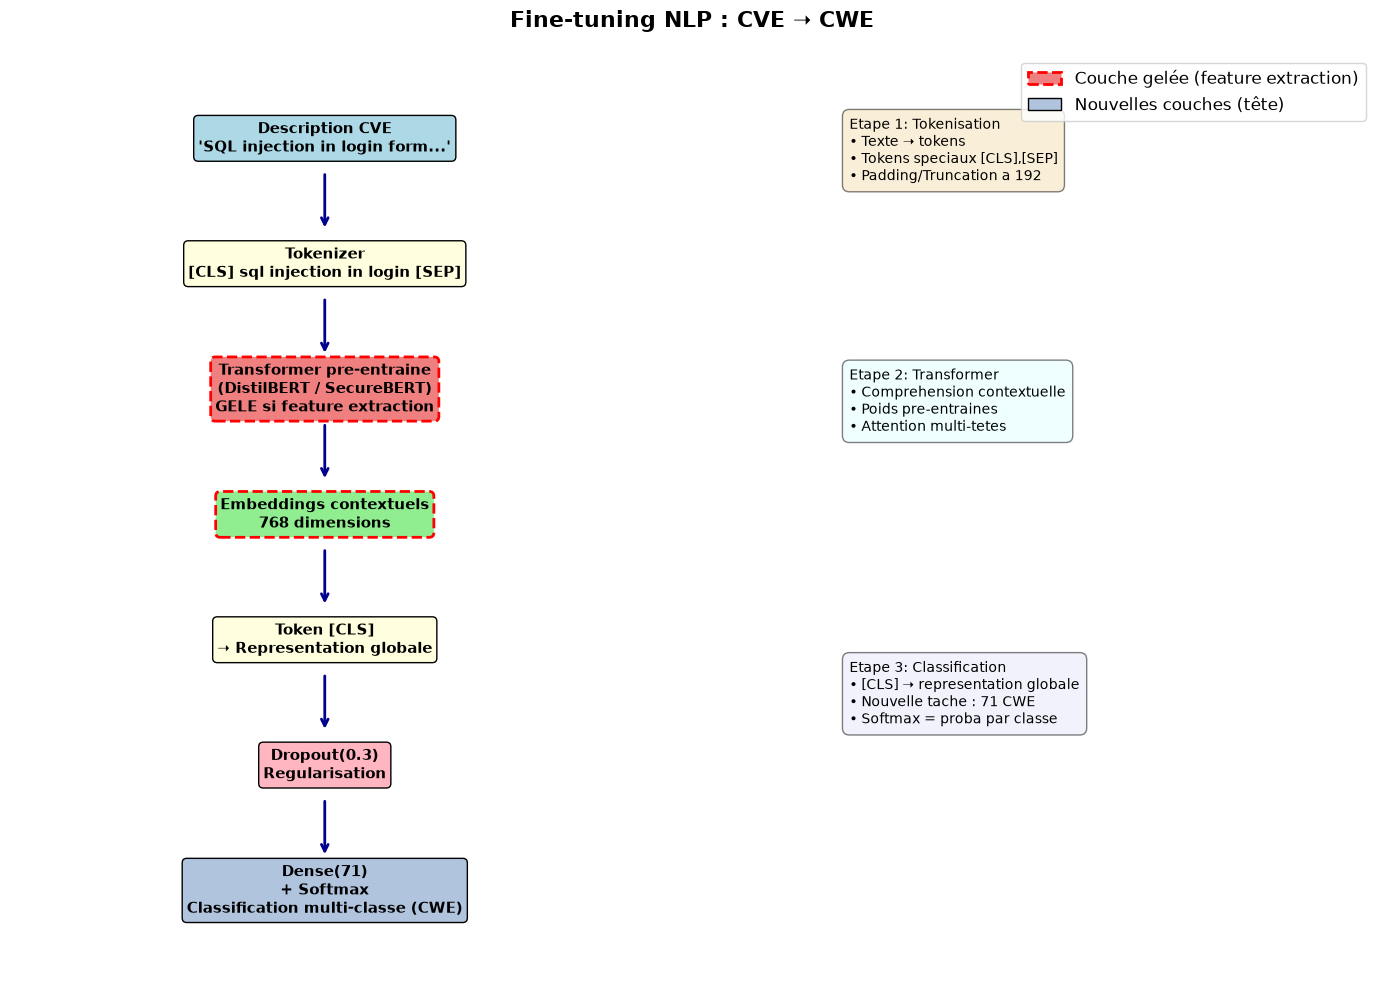

In [4]:
# Visualisation conceptuelle du fine-tuning NLP (CVE -> CWE)
def visualiser_fine_tuning_nlp():
  """
  Cree un diagramme explicatif du fine-tuning en NLP pour la classification CWE
  """
  fig, ax = plt.subplots(1, 1, figsize=(14, 10))

  components = [
    {"name": "Description CVE\n'SQL injection in login form...'", "pos": (1, 9), "color": "lightblue", "frozen": False},
    {"name": "Tokenizer\n[CLS] sql injection in login [SEP]", "pos": (1, 7.5), "color": "lightyellow", "frozen": False},
    {"name": "Transformer pre-entraine\n(DistilBERT / SecureBERT)\nGELE si feature extraction", "pos": (1, 6), "color": "lightcoral", "frozen": True},
    {"name": "Embeddings contextuels\n768 dimensions", "pos": (1, 4.5), "color": "lightgreen", "frozen": True},
    {"name": "Token [CLS]\n➝ Representation globale", "pos": (1, 3), "color": "lightyellow", "frozen": False},
    {"name": "Dropout(0.3)\nRegularisation", "pos": (1, 1.5), "color": "lightpink", "frozen": False},
    {"name": f"Dense({NUM_CLASSES})\n+ Softmax\nClassification multi-classe (CWE)", "pos": (1, 0), "color": "lightsteelblue", "frozen": False},
  ]

  for i, comp in enumerate(components):
    x, y = comp["pos"]
    if comp["frozen"]:
      bbox_props = dict(boxstyle="round,pad=0.3", facecolor=comp["color"], edgecolor="red", linewidth=2, linestyle="--")
    else:
      bbox_props = dict(boxstyle="round,pad=0.3", facecolor=comp["color"], edgecolor="black", linewidth=1)
    ax.text(x, y, comp["name"], ha="center", va="center", fontsize=11, fontweight="bold", bbox=bbox_props)
    if i < len(components) - 1:
      next_y = components[i + 1]["pos"][1]
      ax.annotate("", xy=(x, next_y + 0.4), xytext=(x, y - 0.4),
                  arrowprops=dict(arrowstyle="->", color="darkblue", lw=2))

  ax.text(3.5, 8.5, f"Etape 1: Tokenisation\n• Texte ➝ tokens\n• Tokens speciaux [CLS],[SEP]\n• Padding/Truncation a {MAX_LENGTH}",
          fontsize=10, bbox=dict(boxstyle="round,pad=0.5", facecolor="wheat", alpha=0.5))
  ax.text(3.5, 5.5, "Etape 2: Transformer\n• Comprehension contextuelle\n• Poids pre-entraines\n• Attention multi-tetes",
          fontsize=10, bbox=dict(boxstyle="round,pad=0.5", facecolor="lightcyan", alpha=0.5))
  ax.text(3.5, 2, f"Etape 3: Classification\n• [CLS] ➝ representation globale\n• Nouvelle tache : {NUM_CLASSES} CWE\n• Softmax = proba par classe",
          fontsize=10, bbox=dict(boxstyle="round,pad=0.5", facecolor="lavender", alpha=0.5))

  ax.set_xlim(-0.5, 6); ax.set_ylim(-1, 10)
  ax.set_title("Fine-tuning NLP : CVE ➝ CWE", fontsize=16, fontweight="bold", pad=20)
  ax.axis('off')
  legend_elements = [
    plt.Rectangle((0, 0), 1, 1, facecolor='lightcoral', edgecolor='red', linewidth=2, linestyle="--", label='Couche gelée (feature extraction)'),
    plt.Rectangle((0, 0), 1, 1, facecolor='lightsteelblue', edgecolor='black', linewidth=1, label='Nouvelles couches (tête)'),
  ]
  ax.legend(handles=legend_elements, loc='upper right')
  plt.tight_layout()
  plt.show()

visualiser_fine_tuning_nlp()

# 🎬 Chargement des Donnees - Dataset CVE -> CWE

## 📊 Qu'est ce que le dataset ?
Chaque exemple est une **CVE** : sa **description** (texte) + son **CWE** (le type de faille, le label).
Les donnees viennent de `data/cwe/`, produit par `dataset_cwe.py`. **Config retenue** : les
**10 CWE critiques distinctes** (`--cwe-list ... --drop-other`) - les CVE d'un autre CWE sont
**exclues**, donc la couverture n'est que de **~40 % des CVE** (compromis assume : moins de classes,
plus distinctes ⇒ fiabilite ↑, couverture ↓ ; on le mesure au §*Hors-perimetre*).
Split **temporel** (train <=2023 / val 2024 / test 2025) : jamais de futur dans le passe.

In [5]:
# Chargement des labels + des splits (parquet)
print("📥 Chargement du dataset CVE → CWE...")

with open(f"{DATA_DIR}/labels.json") as f:
    LABELS = json.load(f)
NUM_CLASSES = LABELS["num_labels"]           # deja lu dans la cellule Parametres (meme valeur)
id2label = {int(k): v for k, v in LABELS["id2label"].items()}
label2id = LABELS["label2id"]
CLASS_NAMES = [id2label[i] for i in range(NUM_CLASSES)]

def charger_split(nom):
    df = pl.read_parquet(f"{DATA_DIR}/{nom}.parquet")
    return df["text"].to_list(), df["label"].to_numpy()

train_texts_full, train_labels_full = charger_split("train")
val_texts_full, val_labels_full = charger_split("val")
test_texts, test_labels = charger_split("test")

print(f"✅ Dataset charge avec succes !")
print(f"Classes (CWE): {NUM_CLASSES} -> {', '.join(CLASS_NAMES)}")
print(f"Nombre d'exemples: train={len(train_texts_full):,}  val={len(val_texts_full):,}  test={len(test_texts):,}")

📥 Chargement du dataset CVE → CWE...
✅ Dataset charge avec succes !
Classes (CWE): 71 -> CWE-119, CWE-120, CWE-121, CWE-122, CWE-125, CWE-134, CWE-189, CWE-190, CWE-20, CWE-200, CWE-203, CWE-209, CWE-22, CWE-255, CWE-264, CWE-266, CWE-269, CWE-276, CWE-284, CWE-285, CWE-287, CWE-290, CWE-295, CWE-306, CWE-310, CWE-312, CWE-319, CWE-327, CWE-347, CWE-352, CWE-362, CWE-367, CWE-399, CWE-400, CWE-401, CWE-404, CWE-415, CWE-416, CWE-426, CWE-427, CWE-434, CWE-476, CWE-502, CWE-522, CWE-532, CWE-59, CWE-601, CWE-611, CWE-617, CWE-639, CWE-667, CWE-668, CWE-732, CWE-74, CWE-77, CWE-770, CWE-772, CWE-78, CWE-787, CWE-79, CWE-798, CWE-835, CWE-843, CWE-862, CWE-863, CWE-89, CWE-908, CWE-918, CWE-94, CWE-98, CWE-OTHER
Nombre d'exemples: train=217,966  val=38,223  test=43,229


# 🔄 Sous-echantillonnage - un choix qui a un cout mesure

On n'entraine que sur un **echantillon** du train (40 000 CVE sur ~218 000) pour tenir dans un temps
raisonnable sur un GPU de portable. Le **test reste entier** : on ne triche pas sur l'evaluation.

⚠️ **Ce choix n'est pas neutre, et ce projet l'a paye.** Le sous-echantillonnage frappe
proportionnellement toutes les classes : une classe qui a 500 CVE au total n'en garde qu'une
centaine, et le **macro-F1 les compte pourtant a poids egal** avec les classes majoritaires. Sur le
set a 121 classes, les plus rares tombaient a **26 exemples** - inapprenables. C'est la cause
principale de l'echec de cette configuration.

**A retenir** : le sous-echantillonnage est un compromis temps/qualite acceptable quand les classes
sont peu nombreuses et bien peuplees, et **destructeur** quand la metrique cible traite les classes
a egalite. Le `NUM_SAMPLES_TRAIN` a monter est le premier levier si les classes rares comptent.

In [6]:
# Sous-echantillonnage pedagogique (pour un entrainement rapide sur laptop)
print("Preparation des donnees ...")

def sous_echantillon(texts, labels, n):
    if n is None or n >= len(texts):
        return list(texts), np.array(labels)
    idx = np.random.RandomState(42).choice(len(texts), size=n, replace=False)
    return [texts[i] for i in idx], np.array(labels)[idx]

# Entrainement + validation (sous-echantillonnes) ; test complet (evaluation finale honnete)
train_texts, train_labels = sous_echantillon(train_texts_full, train_labels_full, NUM_SAMPLES_TRAIN)
val_texts, val_labels = sous_echantillon(val_texts_full, val_labels_full, NUM_SAMPLES_VAL)

print(f"✅ Donnees preparees:")
print(f"Entrainement : {len(train_texts)} exemples")
print(f"Validation : {len(val_texts)} exemples")
print(f"Test (complet) : {len(test_texts)} exemples")

Preparation des donnees ...
✅ Donnees preparees:
Entrainement : 40000 exemples
Validation : 10650 exemples
Test (complet) : 43229 exemples


# 🔎 Exploration - trois choses a verifier avant d'entrainer

**1. Le desequilibre des classes.** S'il est fort, l'accuracy devient trompeuse (un modele qui
predit toujours la classe majoritaire peut afficher un bon score) et il faudra des poids de classe.
**2. La longueur des textes.** Elle determine `MAX_LENGTH` : trop court on tronque de l'information,
trop long on gaspille de la memoire - et la memoire, ici, est la ressource critique.
**3. La presence de toutes les classes** dans l'echantillon d'entrainement. Une classe absente aura
un F1 de 0 et tirera mecaniquement le macro-F1 vers le bas, sans que le modele soit en cause.

In [7]:
# Analyse des donnees
print(f"\n📊 Analyse des donnees:")

# Distribution des classes (plafonnee a 15 pour rester lisible si on repasse a 71 classes)
TOP_K = min(15, NUM_CLASSES)
unique, counts = np.unique(train_labels, return_counts=True)
ordre = np.argsort(counts)[::-1]
print(f"Distribution des classes (top {TOP_K} sur {NUM_CLASSES}) :")
for class_id, count in zip(unique[ordre][:TOP_K], counts[ordre][:TOP_K]):
    percentage = (count / len(train_labels)) * 100
    print(f"  {id2label[int(class_id)]:12s}: {count} exemples ({percentage:.1f}%)")

# Statistiques sur la longueur des textes
text_lengths = [len(text.split()) for text in train_texts]
print(f"\nStatistiques sur la longueur des descriptions (mots):")
print(f"  Longueur moyenne: {np.mean(text_lengths):.1f} mots")
print(f"  Longueur mediane: {np.median(text_lengths):.0f} mots")
print(f"  Longueur minimale: {min(text_lengths)} mots")
print(f"  Longueur maximale: {max(text_lengths)} mots")
print(f"  75e percentile: {np.percentile(text_lengths, 75):.0f} mots")


📊 Analyse des donnees:
Distribution des classes (top 15 sur 71) :
  CWE-79      : 5414 exemples (13.5%)
  CWE-OTHER   : 3258 exemples (8.1%)
  CWE-89      : 2468 exemples (6.2%)
  CWE-20      : 2416 exemples (6.0%)
  CWE-119     : 2313 exemples (5.8%)
  CWE-787     : 2153 exemples (5.4%)
  CWE-200     : 2138 exemples (5.3%)
  CWE-22      : 1288 exemples (3.2%)
  CWE-125     : 1209 exemples (3.0%)
  CWE-94      : 1108 exemples (2.8%)
  CWE-352     : 1046 exemples (2.6%)
  CWE-264     : 1008 exemples (2.5%)
  CWE-287     : 912 exemples (2.3%)
  CWE-416     : 907 exemples (2.3%)
  CWE-78      : 705 exemples (1.8%)

Statistiques sur la longueur des descriptions (mots):
  Longueur moyenne: 43.4 mots
  Longueur mediane: 35 mots
  Longueur minimale: 3 mots
  Longueur maximale: 606 mots
  75e percentile: 49 mots


# 📄 Exemples - lire les donnees avant de les modeliser

Regarder quelques exemples bruts n'est pas une formalite : c'est ce qui permet de **prevoir** ce que
le modele va reussir et rater. Ici, on va constater que les descriptions de CVE sont fortement
**stereotypees** ("*SQL injection in...*", "*Cross-site scripting (XSS) via...*").

Cette observation a une consequence directe, mesuree plus loin : si le nom du type de faille est
quasiment **ecrit dans le texte**, alors un simple sac de mots devrait tres bien s'en sortir - et le
transformer aura peu de valeur ajoutee. C'est exactement ce que le baseline TF-IDF va montrer.

In [8]:
# Affichage d'exemples representatifs
def afficher_exemples(texts, labels, num_exemples=4):
    """
    Affiche des exemples de CVE avec leur type (CWE).
    """
    print(f"\n📄 Exemples representatifs du dataset:")

    for i in range(min(num_exemples, len(texts))):
        cwe = id2label[int(labels[i])]
        text = texts[i]
        word_count = len(text.split())

        print(f"\n===== Exemple {i+1} =====")
        print(f"CWE (type de faille): {cwe}")
        print(f"Longueur du texte: {word_count} mots")
        print(f"Description: {text[:300]}{'...' if len(text) > 300 else ''}")

afficher_exemples(train_texts, train_labels, 3)

print("\nObservations:")
print("  - Les descriptions varient en longueur et en precision")
print("  - Vocabulaire technique (injection, overflow, authentication, bypass...)")
print("  - Certains CWE se ressemblent (ex. CWE-79 XSS vs CWE-80)")


📄 Exemples representatifs du dataset:

===== Exemple 1 =====
CWE (type de faille): CWE-200
Longueur du texte: 22 mots
Description: In telephony service, there is a missing permission check. This could lead to local information disclosure with no additional execution privileges needed.

===== Exemple 2 =====
CWE (type de faille): CWE-22
Longueur du texte: 24 mots
Description: Directory traversal vulnerability in eXtropia bbs_forum.cgi 1.0 allows remote attackers to read arbitrary files via a .. (dot dot) attack on the file parameter.

===== Exemple 3 =====
CWE (type de faille): CWE-306
Longueur du texte: 46 mots
Description: Delta Electronics InfraSuite Device Master versions 00.00.01a and prior lack proper authentication for functions that create and modify user groups. An attacker could provide malicious serialized objects that could run these functions without authentication to create a new user and add them to the a...

Observations:
  - Les descriptions varient en longueur et en p

# 📏 Distribution des longueurs - calibrer `MAX_LENGTH`

`MAX_LENGTH` fixe le nombre de tokens conserves par description. Le cout memoire de l'attention
croit avec le **carre** de cette longueur, donc chaque token compte double sur un GPU limite.

Le graphique cumulatif repond a la seule question utile : **quelle proportion des textes passe sans
etre tronquee ?** Si la quasi-totalite tient sous la limite, l'augmenter ne ferait que consommer de
la memoire. ⚠️ Attention : les longueurs sont ici comptees **en mots**, alors que le modele compte
en **tokens** (sous-mots) - un mot technique rare peut se decouper en plusieurs tokens, donc le
nombre de tokens est toujours superieur au nombre de mots.


📊 Visualisation des statistiques du dataset:


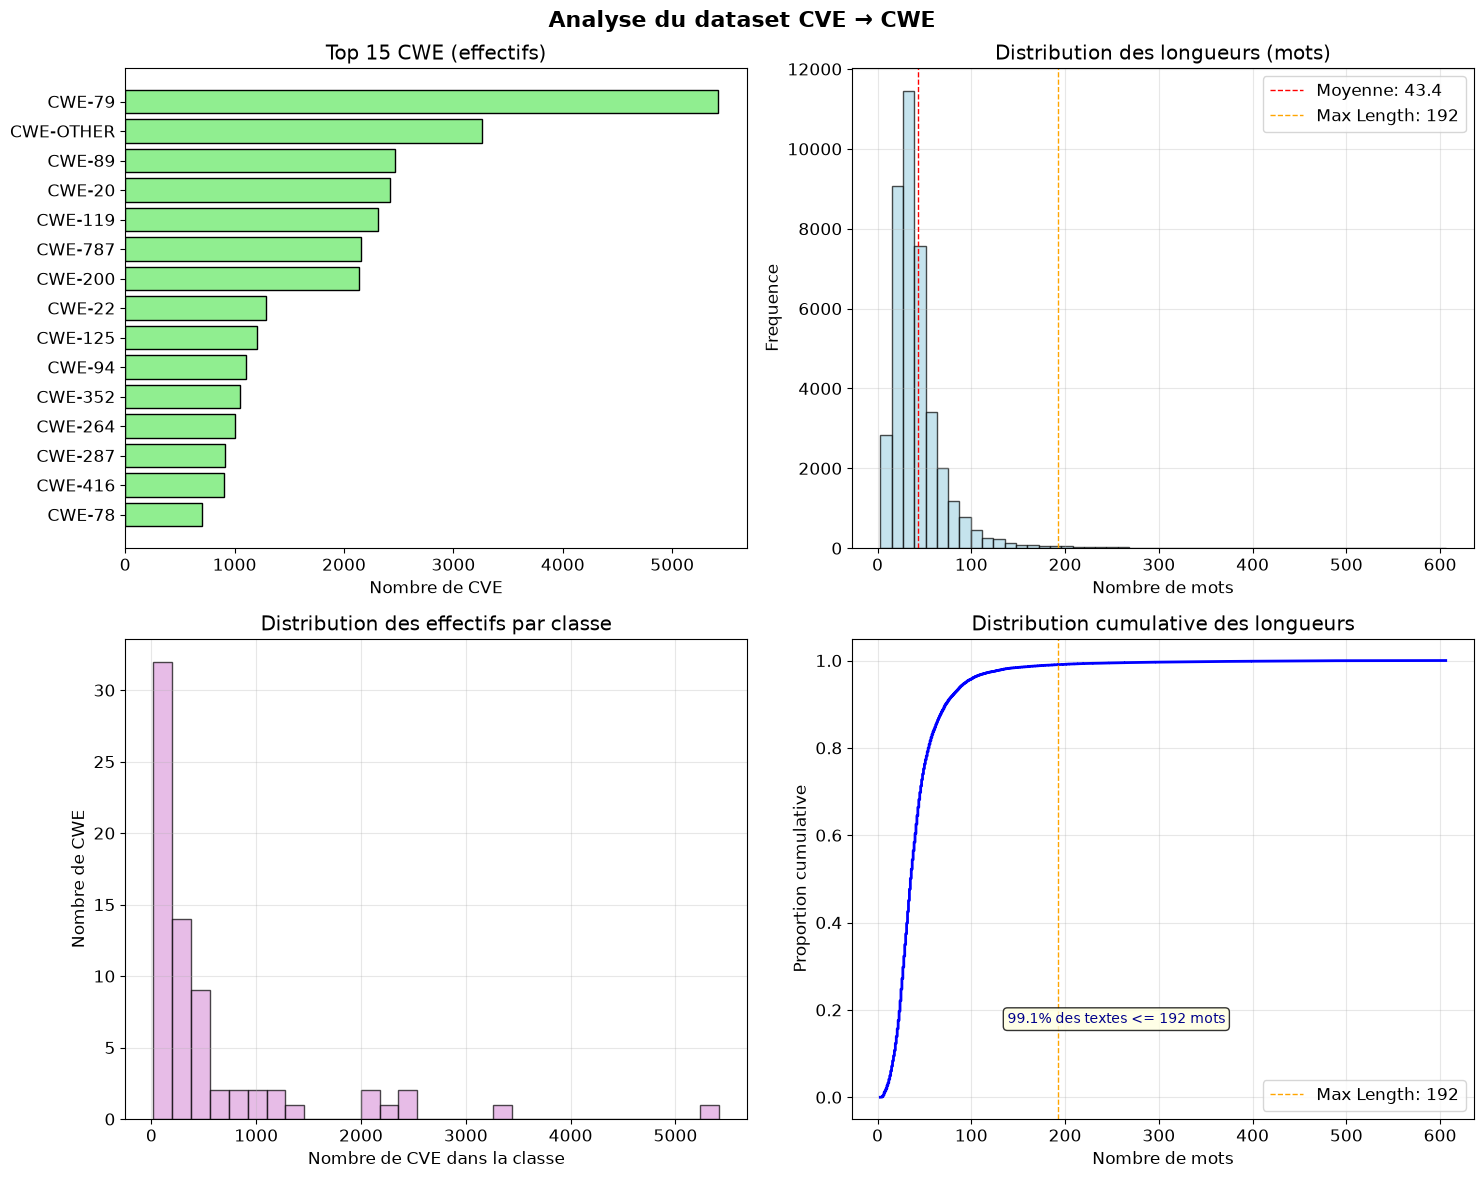

Statistiques importantes:
  - 99.1% des descriptions <= 192 mots
  - 0.9% seront tronquees lors de la tokenization (truncation)


In [9]:
# Visualisation des statistiques des donnees
def visualiser_donnees(texts, labels):
  """
  Cree des visualisations pour comprendre le dataset CVE → CWE.
  """
  text_lengths = [len(text.split()) for text in texts]

  fig, axes = plt.subplots(2, 2, figsize=(15, 12))
  fig.suptitle("Analyse du dataset CVE → CWE", fontsize=16, fontweight="bold")

  # 1- Distribution des classes (plafonnee a 15)
  unique, counts = np.unique(labels, return_counts=True)
  ordre = np.argsort(counts)[::-1][:TOP_K]
  noms = [id2label[int(unique[i])] for i in ordre]
  axes[0, 0].barh(noms[::-1], counts[ordre][::-1], color='lightgreen', edgecolor='black')
  axes[0, 0].set_title(f"Top {len(ordre)} CWE (effectifs)")
  axes[0, 0].set_xlabel("Nombre de CVE")

  # 2- Distribution des longueurs (en mots)
  axes[0, 1].hist(text_lengths, bins=50, color='lightblue', alpha=0.7, edgecolor='black')
  axes[0, 1].axvline(np.mean(text_lengths), color='red', linestyle='dashed', linewidth=1, label=f'Moyenne: {np.mean(text_lengths):.1f}')
  axes[0, 1].axvline(MAX_LENGTH, color='orange', linestyle='dashed', linewidth=1, label=f'Max Length: {MAX_LENGTH}')
  axes[0, 1].set_title("Distribution des longueurs (mots)")
  axes[0, 1].set_xlabel("Nombre de mots"); axes[0, 1].set_ylabel("Frequence")
  axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

  # 3- Nombre de classes par effectif
  axes[1, 0].hist(counts, bins=30, color='plum', alpha=0.7, edgecolor='black')
  axes[1, 0].set_title("Distribution des effectifs par classe")
  axes[1, 0].set_xlabel("Nombre de CVE dans la classe"); axes[1, 0].set_ylabel("Nombre de CWE")
  axes[1, 0].grid(True, alpha=0.3)

  # 4- Distribution cumulative des longueurs
  sorted_lengths = np.sort(text_lengths)
  y = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths)
  axes[1, 1].plot(sorted_lengths, y, 'b-', linewidth=2)
  axes[1, 1].axvline(MAX_LENGTH, color='orange', linestyle='--', linewidth=1, label=f'Max Length: {MAX_LENGTH}')
  axes[1, 1].set_title("Distribution cumulative des longueurs")
  axes[1, 1].set_xlabel("Nombre de mots"); axes[1, 1].set_ylabel("Proportion cumulative")
  axes[1, 1].grid(True, alpha=0.3); axes[1, 1].legend()

  under_limit = sum(1 for L in text_lengths if L <= MAX_LENGTH) / len(text_lengths) * 100
  axes[1, 1].text(0.6, 0.2, f"{under_limit:.1f}% des textes <= {MAX_LENGTH} mots", transform=axes[1, 1].transAxes,
                  fontsize=10, color='darkblue', ha='right', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

  plt.tight_layout()
  plt.show()

  print("Statistiques importantes:")
  print(f"  - {under_limit:.1f}% des descriptions <= {MAX_LENGTH} mots")
  print(f"  - {100 - under_limit:.1f}% seront tronquees lors de la tokenization (truncation)")

print("\n📊 Visualisation des statistiques du dataset:")
visualiser_donnees(train_texts, train_labels)

# 🔤 Vocabulaire - ou se trouve le signal

Le classement des mots les plus frequents contient surtout des mots vides (`the`, `in`, `of`) : ils
sont partout, donc ils ne distinguent rien. Le **signal utile** est dans le vocabulaire technique -
`injection`, `overflow`, `authentication`, `traversal`.

C'est precisement ce que le **TF-IDF** de la cellule suivante formalise : ponderer chaque mot par sa
rarete, pour que les termes discriminants pesent plus que les mots vides. Cette analyse n'est donc
pas un simple detour descriptif : c'est la mise en place du baseline.

Analyse du vocabulaire des descriptions de CVE:



Statistiques du vocabulaire
   - Mots uniques: 81,733
   - Total de mots: 1,968,185
   - Richesse lexicale: 0.042

 Top 20 mots les plus frequents:
   1. 'the': 71,941 occurences (3.66%)
   2. 'to': 63,242 occurences (3.21%)
   3. 'in': 56,332 occurences (2.86%)
   4. 'a': 50,056 occurences (2.54%)
   5. 'and': 34,760 occurences (1.77%)
   6. 'of': 30,567 occurences (1.55%)
   7. '1': 28,275 occurences (1.44%)
   8. '0': 26,727 occurences (1.36%)
   9. 'vulnerability': 23,928 occurences (1.22%)
  10. 'an': 20,578 occurences (1.05%)
  11. '2': 20,301 occurences (1.03%)
  12. 'allows': 17,438 occurences (0.89%)
  13. 'via': 17,392 occurences (0.88%)
  14. 'before': 16,966 occurences (0.86%)
  15. 'is': 16,876 occurences (0.86%)
  16. 'remote': 16,342 occurences (0.83%)
  17. 'this': 15,994 occurences (0.81%)
  18. 'attackers': 14,590 occurences (0.74%)
  19. '3': 14,404 occurences (0.73%)
  20. 'arbitrary': 12,654 occurences (0.64%)


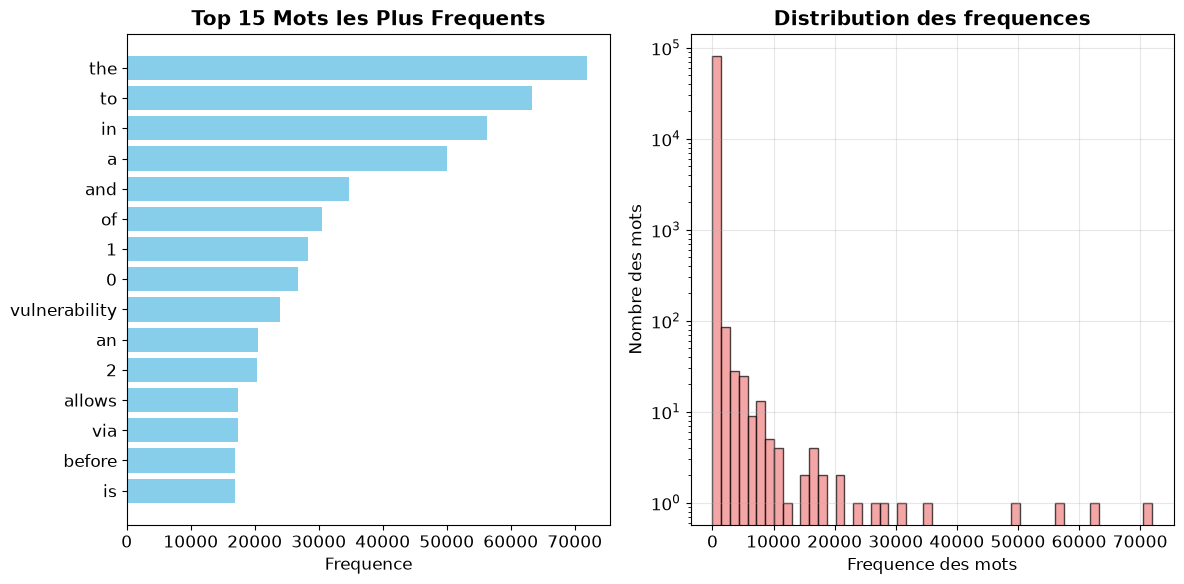


 Observations sur le vocabulaire
   - Mots tres frequents (the, a, in, of...)
   - Vocabulaire technique cyber ('injection', 'buffer', 'authentication', 'overflow')
   - Ces mots techniques sont le signal utile pour deviner le CWE


In [10]:
# Analyse du vocabulaire
def analyser_vocabulaire(texts, top_n=20):
    """
    Analyse le vocabulaire du dataset et affiche les mots les plus frequents.
    """
    print("Analyse du vocabulaire des descriptions de CVE:")
    from collections import Counter
    import re

    all_words = []
    for text in texts:
        words = re.findall(r'\b\w+\b', text.lower())
        all_words.extend(words)

    word_counts = Counter(all_words)
    unique_words = len(word_counts)
    total_words = len(all_words)

    print(f"\nStatistiques du vocabulaire")
    print(f"   - Mots uniques: {unique_words:,}")
    print(f"   - Total de mots: {total_words:,}")
    print(f"   - Richesse lexicale: {unique_words/total_words:.3f}")

    print(f"\n Top {top_n} mots les plus frequents:")
    for i, (word, count) in enumerate(word_counts.most_common(top_n), 1):
        percentage = count / total_words * 100
        print(f"  {i:2d}. '{word}': {count:,} occurences ({percentage:.2f}%)")

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    top_words = word_counts.most_common(15)
    words, counts = zip(*top_words)
    plt.barh(range(len(words)), counts, color='skyblue')
    plt.yticks(range(len(words)), words)
    plt.xlabel("Frequence")
    plt.title(f'Top {len(words)} Mots les Plus Frequents', fontweight='bold')
    plt.gca().invert_yaxis()

    plt.subplot(1, 2, 2)
    frequencies = list(word_counts.values())
    plt.hist(frequencies, bins=50, color='lightcoral', alpha=0.7, edgecolor='black')
    plt.xlabel('Frequence des mots'); plt.ylabel('Nombre des mots')
    plt.title('Distribution des frequences', fontweight='bold')
    plt.yscale('log'); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return word_counts

vocab_stats = analyser_vocabulaire(train_texts)

print("\n Observations sur le vocabulaire")
print("   - Mots tres frequents (the, a, in, of...)")
print("   - Vocabulaire technique cyber ('injection', 'buffer', 'authentication', 'overflow')")
print("   - Ces mots techniques sont le signal utile pour deviner le CWE")

# 📐 Baseline classique : TF-IDF + Regression logistique

**Avant** de sortir l'artillerie (un transformer de 125M parametres, 15 min/epoque sur GPU), il faut
savoir **ce qu'un modele simple obtient deja**. Sinon on ne sait pas ce que le transformer **apporte
reellement** - c'est la meme demarche que le baseline "classe majoritaire", un cran plus haut.

- **TF-IDF** = la suite logique de l'analyse de vocabulaire ci-dessus : chaque description devient un
  vecteur de **fréquences de mots ponderees** (un mot rare mais discriminant pese plus qu'un "the").
  Aucune notion d'ordre ni de contexte : c'est un **sac de mots** (uni + bigrammes).
- **Regression logistique** = exactement le modele du projet PEP (sujet 1), ici en **multi-classe**.
- **Meme protocole que le transformer** : meme sous-echantillon d'entrainement, meme test complet,
  `class_weight='balanced'` (equivalent du `class_weight` de Keras), metrique **macro-F1**.

> C'est le **plancher honnete**. Si le transformer ne le battait pas, tout le transfer learning
> serait injustifie sur cette tache.

In [11]:
# Baseline CPU (~1-2 min) : TF-IDF (uni+bigrammes) -> regression logistique multi-classe
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

print("Entrainement du baseline TF-IDF + LogReg (CPU)...")
t0 = time.time()

vectorizer = TfidfVectorizer(
    max_features=50_000,      # vocabulaire borne (memoire)
    ngram_range=(1, 2),       # uni + bigrammes ('sql injection' compte comme un signal)
    sublinear_tf=True,        # log(tf) : amortit les repetitions
    min_df=2,                 # ignore les termes vus une seule fois (bruit)
)
X_train_tfidf = vectorizer.fit_transform(train_texts)   # fit sur le TRAIN uniquement (pas de fuite)
X_test_tfidf = vectorizer.transform(test_texts)

logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train_tfidf, train_labels)
y_pred_tfidf = logreg.predict(X_test_tfidf)

BASELINE_TFIDF = {
    'accuracy': float(accuracy_score(test_labels, y_pred_tfidf)),
    'f1_macro': float(f1_score(test_labels, y_pred_tfidf, average='macro', zero_division=0)),
    'f1_weighted': float(f1_score(test_labels, y_pred_tfidf, average='weighted', zero_division=0)),
    'n_features': int(X_train_tfidf.shape[1]),
    'train_seconds': round(time.time() - t0, 1),
}

# Baseline encore plus bas : tout predire dans la classe majoritaire (le vrai plancher)
maj_train = int(np.bincount(train_labels).argmax())
BASELINE_MAJORITY = {
    'accuracy': float(accuracy_score(test_labels, np.full_like(test_labels, maj_train))),
    'f1_macro': float(f1_score(test_labels, np.full_like(test_labels, maj_train),
                               average='macro', zero_division=0)),
}

print(f"\n✅ Baseline entraine en {BASELINE_TFIDF['train_seconds']}s "
      f"({BASELINE_TFIDF['n_features']:,} features TF-IDF)")
print(f"\n{'Baseline':<28}{'Accuracy':<12}{'macro-F1'}")
print("-" * 50)
print(f"{'Classe majoritaire':<28}{BASELINE_MAJORITY['accuracy']:<12.4f}{BASELINE_MAJORITY['f1_macro']:.4f}")
print(f"{'TF-IDF + LogReg':<28}{BASELINE_TFIDF['accuracy']:<12.4f}{BASELINE_TFIDF['f1_macro']:.4f}")
print("\n👉 C'est le score A BATTRE par le fine-tuning (comparaison a la fin du notebook).")
print("   Un sac de mots capte deja beaucoup : le jargon CVE est tres stereotype")
print("   ('SQL injection', 'cross-site scripting', 'buffer overflow' -> quasi des etiquettes).")

Entrainement du baseline TF-IDF + LogReg (CPU)...



✅ Baseline entraine en 33.1s (50,000 features TF-IDF)

Baseline                    Accuracy    macro-F1
--------------------------------------------------
Classe majoritaire          0.1752      0.0043
TF-IDF + LogReg             0.5528      0.4243

👉 C'est le score A BATTRE par le fine-tuning (comparaison a la fin du notebook).
   Un sac de mots capte deja beaucoup : le jargon CVE est tres stereotype
   ('SQL injection', 'cross-site scripting', 'buffer overflow' -> quasi des etiquettes).


# ✂️ Tokenisation avec le tokenizer du modele

## Qu'est ce que la tokenisation ?
La tokenisation decoupe le texte en **tokens** (sous-mots) et les convertit en **identifiants
numeriques**. Chaque modele a **son** tokenizer (les memes sous-mots qu'au pre-entrainement).

## Specialites du Tokenizer
Il ajoute des **tokens speciaux** ([CLS] au debut, [SEP] a la fin), applique le **padding**
(egalise les longueurs) et la **truncation** (coupe a `MAX_LENGTH`).

In [12]:
# Chargement du tokenizer
print(f"Chargement du tokenizer {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Tokenizer charge avec succes !")
print(f" Taille du vocabulaire: {tokenizer.vocab_size:,} tokens")

print(f"Tokens speciaux:")
print(f"   CLS (debut): '{tokenizer.cls_token}' (ID: {tokenizer.cls_token_id})")
print(f"   SEP (fin): '{tokenizer.sep_token}' (ID: {tokenizer.sep_token_id})")
print(f"   PAD (padding): '{tokenizer.pad_token}' (ID: {tokenizer.pad_token_id})")
print(f"   UNK (inconnu): '{tokenizer.unk_token}' (ID: {tokenizer.unk_token_id})")

Chargement du tokenizer distilbert-base-uncased...


Tokenizer charge avec succes !
 Taille du vocabulaire: 30,522 tokens
Tokens speciaux:
   CLS (debut): '[CLS]' (ID: 101)
   SEP (fin): '[SEP]' (ID: 102)
   PAD (padding): '[PAD]' (ID: 0)
   UNK (inconnu): '[UNK]' (ID: 100)


# 🔬 Demonstration - voir la tokenisation en sous-mots

La cellule suivante deroule le processus sur trois phrases courtes. Ce qu'il faut observer :

- **Le decoupage en sous-mots.** Un mot courant reste entier ; un mot rare est coupe en morceaux
  (marques `##`). C'est ce qui permet a un vocabulaire de 30 000 entrees de representer **n'importe
  quel** mot, y compris un nom de produit jamais vu - il n'y a donc presque jamais de token `[UNK]`.
- **Les tokens speciaux ajoutes** : `[CLS]` au debut (le resume de la phrase, cf. l'architecture) et
  `[SEP]` a la fin.
- **La conversion en entiers** : le modele ne voit jamais du texte, seulement des identifiants qui
  indexent sa table d'embeddings.

In [13]:
# Demonstration de la tokenisation
def demonstrer_tokenisation(tokenizer, exemples_textes):
  """
  Demontre le processus de tokenisation etape par etape
  """
  print("=== Demonstration de la Tokenisation ===")

  for i, texte in enumerate(exemples_textes):
    print(f"\n Exemple {i+1}: '{texte}'")
    print("-" * 60)
    tokens = tokenizer.tokenize(texte)
    print(f"Tokens: {tokens}")
    print(f"Nombre de tokens: {len(tokens)}")
    token_ids = tokenizer.convert_tokens_to_ids(tokens)
    print(f"IDS des tokens: {token_ids}")
    encoded = tokenizer.encode(texte, add_special_tokens=True)
    print(f"Encodage complet: {encoded}")
    decoded = tokenizer.decode(encoded)
    print(f"Decodage: '{decoded}'")
    if len(encoded) > len(token_ids):
      print(f"Tokens ajoutes: [CLS] au debut, [SEP] a la fin")

# Exemples de descriptions de CVE
exemples = [
  "SQL injection in the login form allows remote attackers to execute arbitrary SQL.",
  "Cross-site scripting (XSS) via the search parameter.",
  "Buffer overflow in the parser leads to remote code execution."
]

demonstrer_tokenisation(tokenizer, exemples)

=== Demonstration de la Tokenisation ===

 Exemple 1: 'SQL injection in the login form allows remote attackers to execute arbitrary SQL.'
------------------------------------------------------------
Tokens: ['sql', 'injection', 'in', 'the', 'log', '##in', 'form', 'allows', 'remote', 'attackers', 'to', 'execute', 'arbitrary', 'sql', '.']
Nombre de tokens: 15
IDS des tokens: [29296, 13341, 1999, 1996, 8833, 2378, 2433, 4473, 6556, 17857, 2000, 15389, 15275, 29296, 1012]
Encodage complet: [101, 29296, 13341, 1999, 1996, 8833, 2378, 2433, 4473, 6556, 17857, 2000, 15389, 15275, 29296, 1012, 102]
Decodage: '[CLS] sql injection in the login form allows remote attackers to execute arbitrary sql. [SEP]'
Tokens ajoutes: [CLS] au debut, [SEP] a la fin

 Exemple 2: 'Cross-site scripting (XSS) via the search parameter.'
------------------------------------------------------------
Tokens: ['cross', '-', 'site', 'script', '##ing', '(', 'x', '##ss', ')', 'via', 'the', 'search', 'parameter', '.']
Nombr

# 🛠️ Fonction de tokenisation - deux pieges

**`truncation=True`** coupe ce qui depasse `MAX_LENGTH`. Sans elle, une description longue ferait
planter le modele, qui attend une taille fixe.

**`padding='max_length'` et non `padding=True`** - c'est le piege. `padding=True` complete au plus
long **du lot** : la forme des tenseurs varie donc d'un lot a l'autre. Or notre modele declare
`Input(shape=(MAX_LENGTH,))`, une taille **fixe** : il plante des qu'aucun texte du lot n'atteint la
limite. Ce bug ne se manifeste pas toujours - il suffit qu'un texte long soit present dans chaque lot
pour qu'il passe inapercu, puis qu'il casse sur un echantillon plus petit.

Le **masque d'attention** produit en sortie vaut 1 sur les vrais tokens et 0 sur le padding : il dit
au transformer d'ignorer le remplissage, qui ne porte aucune information.

In [14]:
# Fonction de tokenisation pour l'entrainement
def tokenize_texts(texts, tokenizer, max_length=MAX_LENGTH):
  """
  Tokenise une liste de textes avec padding et truncation

  Args:
    texts: Liste des textes a tokeniser
    tokenizer: Tokeniser du modele
    max_length: Longueur maximale des sequences
  Returns:
    Dict contenant input_ids et attention_mask
  """
  return tokenizer(
    texts,
    padding='max_length',   # ⚠️ PAS padding=True : le modele declare Input(shape=(MAX_LENGTH,)),
    truncation=True,        #    donc toutes les sequences doivent faire EXACTEMENT MAX_LENGTH.
    max_length=max_length,  #    padding=True complete au plus long du LOT -> shape variable et
    return_tensors='tf'     #    crash de shape des qu'aucun texte n'atteint MAX_LENGTH.
  )

print("Fonction de tokenisation definie")
print("\nParametres de tokenisation:")
print(f"   - Longueur maximale: {MAX_LENGTH} tokens")
print(f"   - Padding: 'max_length' (toutes les sequences a exactement {MAX_LENGTH})")
print(f"   - Truncation: activee (coupe les textes trop longs)")
print(f"   - Format de sortie: Tenseurs TensorFlow")

Fonction de tokenisation definie

Parametres de tokenisation:
   - Longueur maximale: 192 tokens
   - Padding: 'max_length' (toutes les sequences a exactement 192)
   - Truncation: activee (coupe les textes trop longs)
   - Format de sortie: Tenseurs TensorFlow


# 🔢 Application aux trois splits

Un point de methode : le tokenizer est **deterministe** et n'apprend rien de nos donnees - c'est une
simple table de correspondance livree avec le modele. Il n'y a donc **aucune fuite** a l'appliquer
aux trois splits d'un coup, contrairement a un `TfidfVectorizer` qui doit etre ajuste sur le train
seul (c'est ce que fait la cellule du baseline).

Les formes affichees doivent toutes valoir `(n, MAX_LENGTH)` : si la deuxieme dimension varie d'un
split a l'autre, c'est le piege du padding decrit au-dessus.

In [15]:
# Tokenisation des donnees d'entrainement, validation et test
print("Tokenisation des donnees...\n")

print(f"Tokenisation de {len(train_texts)} textes d'entrainement...")
train_encodings = tokenize_texts(train_texts, tokenizer)
print("Entrainement tokenize")

print(f"Tokenisation de {len(val_texts)} textes de validation...")
val_encodings = tokenize_texts(val_texts, tokenizer)
print("Validation tokenizee")

print(f"Tokenisation de {len(test_texts)} textes de test...")
test_encodings = tokenize_texts(test_texts, tokenizer)
print("Test tokenize")

print(f"\n Resultats de la tokenisation")
print(f"  Train - input_ids shape: {train_encodings['input_ids'].shape}")
print(f"  Val   - input_ids shape: {val_encodings['input_ids'].shape}")
print(f"  Test  - input_ids shape: {test_encodings['input_ids'].shape}")

print(f"\n Explications des sorties")
print(f"   input_ids: Les tokens convertis en nombres")
print(f"   attention_mask: Masque pour ignorer le padding (1=vrai token, 0=padding)")

Tokenisation des donnees...

Tokenisation de 40000 textes d'entrainement...


I0000 00:00:1785584543.651016 1982825 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3673 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Entrainement tokenize
Tokenisation de 10650 textes de validation...


Validation tokenizee
Tokenisation de 43229 textes de test...


Test tokenize

 Resultats de la tokenisation
  Train - input_ids shape: (40000, 192)
  Val   - input_ids shape: (10650, 192)
  Test  - input_ids shape: (43229, 192)

 Explications des sorties
   input_ids: Les tokens convertis en nombres
   attention_mask: Masque pour ignorer le padding (1=vrai token, 0=padding)


# 🧐 Analyse - combien de calcul part dans le vide ?

Le **ratio de padding** est directement du calcul gaspille : sur une sequence remplie a 60 % de
padding, 60 % des positions sont traitees pour rien. Le masque d'attention evite qu'elles polluent
le resultat, pas qu'elles coutent du temps.

C'est le compromis assume de `padding='max_length'` : on echange de l'efficacite contre une forme
fixe, imposee par notre architecture. Un modele a entree de taille variable pourrait utiliser du
padding dynamique par lot et economiser ce calcul.

In [16]:
# Analyse detaillee de la tokenisation
def analyser_tokenisation(texts, encodings, tokenizer, num_exemples=3):
  """
    Analyse detaillee du resultat de la tokenisation
  """
  print("=== ANALYSE DETAILLEE DE LA TOKENISATION ===")

  for i in range(min(num_exemples, len(texts))):
    print(f"\n Exemple {i+1}:")
    print("=" * 70)
    original_text = texts[i]
    print(f"Texte original: '{original_text[:100]}{'...' if len(original_text) > 100 else ''}'")

    input_ids = encodings['input_ids'][i].numpy()
    attention_mask = encodings['attention_mask'][i].numpy()
    print(f"\n Input IDs: {input_ids[:20]}{'...' if len(input_ids) > 20 else ''}")
    print(f" Attention mask: {attention_mask[:20]}{'...' if len(attention_mask) > 20 else ''}")

    non_padding_tokens = int(np.sum(attention_mask))
    padding_tokens = len(attention_mask) - non_padding_tokens
    print(f"\nStatistiques:")
    print(f"   - Tokens reels: {non_padding_tokens}")
    print(f"   - Tokens de padding: {padding_tokens}")
    print(f"   - Ratio padding: {padding_tokens/len(input_ids)*100:.1f}%")

analyser_tokenisation(train_texts, train_encodings, tokenizer, 2)

print("\nPoints cles de la tokenisation")
print(f"   - Chaque texte commence par [CLS] et finit par [SEP]")
print(f"   - Les textes courts sont completes par [PAD]")
print(f"   - Les textes longs sont tronques a MAX_LENGTH")

=== ANALYSE DETAILLEE DE LA TOKENISATION ===

 Exemple 1:
Texte original: 'In telephony service, there is a missing permission check. This could lead to local information disc...'

 Input IDs: [  101  1999 10093 13699 27629  2326  1010  2045  2003  1037  4394  6656
  4638  1012  2023  2071  2599  2000  2334  2592]...
 Attention mask: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]...

Statistiques:
   - Tokens reels: 29
   - Tokens de padding: 163
   - Ratio padding: 84.9%

 Exemple 2:
Texte original: 'Directory traversal vulnerability in eXtropia bbs_forum.cgi 1.0 allows remote attackers to read arbi...'

 Input IDs: [  101 14176 29053  2389 18130  1999  4654 13181 19312 22861  2015  1035
  7057  1012  1039  5856  1015  1012  1014  4473]...
 Attention mask: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]...

Statistiques:
   - Tokens reels: 41
   - Tokens de padding: 151
   - Ratio padding: 78.6%

Points cles de la tokenisation
   - Chaque texte commence par [CLS] et finit par [SEP]
   - Les text

# 📦 Creation des Datasets TensorFlow

## Pourquoi tf.data.Dataset ?
`tf.data` cree un pipeline **optimise** : melange (shuffle), lots (batch) et pre-chargement
parallele (prefetch) - indispensable pour nourrir le GPU efficacement.

In [17]:
# Creation des datasets TensorFlow
print("Creation des datasets TensorFlow optimises...")

def make_dataset(encodings, labels, shuffle=False):
  ds = tf.data.Dataset.from_tensor_slices((
    {
      'input_ids': encodings['input_ids'],
      'attention_mask': encodings['attention_mask']
    },
    labels,
  ))
  if shuffle:
    ds = ds.shuffle(buffer_size=1000)         # Melanger les donnees
  ds = ds.batch(BATCH_SIZE)                    # Creer des batches
  ds = ds.prefetch(tf.data.AUTOTUNE)           # Pre-chargement parallele
  return ds

train_dataset = make_dataset(train_encodings, train_labels, shuffle=True)
val_dataset = make_dataset(val_encodings, val_labels)
test_dataset = make_dataset(test_encodings, test_labels)

print("Datasets crees (train / val / test)")
print("\n Configuration des datasets:")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Shuffle train: Oui (buffer=1000)")
print(f"  - Shuffle val/test: Non (ordre preserve)")
print(f"  - Prefetch: AUTOTUNE (parallelisation)")

Creation des datasets TensorFlow optimises...


Datasets crees (train / val / test)

 Configuration des datasets:
  - Batch size: 16
  - Shuffle train: Oui (buffer=1000)
  - Shuffle val/test: Non (ordre preserve)
  - Prefetch: AUTOTUNE (parallelisation)


# 🗂️ Verification du pipeline - l'etape qu'on saute a tort

On decode un exemple pour verifier que **texte, tokens et etiquette correspondent toujours** apres
tokenisation, mise en lots et melange. Une erreur d'alignement entre les entrees et les labels ne
produit aucune exception : elle produit un modele qui apprend du bruit, et on cherche la cause
pendant des heures dans les hyperparametres.

C'est une verification a trente secondes qui protege d'une classe entiere de bugs silencieux.

In [18]:
# Exploration des datasets crees
def explorer_dataset(dataset, nom_dataset, num_batches=1):
  """
    Explore la structure d'un dataset TensorFlow
  """
  print(f"==== EXPLORATION DU DATASET {nom_dataset.upper()} ====")

  for batch_num, (features, labels) in enumerate(dataset.take(num_batches)):
    print(f"\n Batch {batch_num + 1}:")
    print("-" * 50)
    print("Structure des features")
    for key, value in features.items():
      print(f"  * {key}: {value.shape} (dtype: {value.dtype})")
    print(f"Labels: {labels.shape} (dtype: {labels.dtype})")

    print(f"\n Premier exemple du batch:")
    input_ids_sample = features['input_ids'][0].numpy()
    label_sample = int(labels[0].numpy())
    decoded_sample = tokenizer.decode(input_ids_sample, skip_special_tokens=True)
    print(f" Texte decode: '{decoded_sample[:100]}{'...' if len(decoded_sample) > 100 else ''}'")
    print(f" Label: {label_sample} ({id2label[label_sample]})")

explorer_dataset(train_dataset, "Entrainement", 1)

print("\n Datasets TensorFlow prets pour l'entrainement !")
print(" Prochaine etape: Construction du modele")

==== EXPLORATION DU DATASET ENTRAINEMENT ====

 Batch 1:
--------------------------------------------------
Structure des features
  * input_ids: (16, 192) (dtype: <dtype: 'int32'>)
  * attention_mask: (16, 192) (dtype: <dtype: 'int32'>)
Labels: (16,) (dtype: <dtype: 'int64'>)

 Premier exemple du batch:
 Texte decode: 'there is a stack - based buffer overflow in the third instance of the calculate _ gain function in l...'
 Label: 58 (CWE-787)

 Datasets TensorFlow prets pour l'entrainement !
 Prochaine etape: Construction du modele


# 🧱 Construction du modele (transformer pre-entraine + tete custom)

## Les deux backbones compares
| Modele | Famille | Couches | Dim. | Parametres | Pre-entraine sur |
|---|---|---|---|---|---|
| `distilbert-base-uncased` | BERT distille | 6 | 768 | 66M | texte generaliste (Wikipedia, BookCorpus) |
| `ehsanaghaei/SecureBERT` | RoBERTa-base | 12 | 768 | 125M | **texte cybersecurite** (avis, rapports, CVE) |

On utilise le transformer comme **couche de base** (`TFAutoModel` = le transformer **nu**, sans tete)
et on ajoute **notre** tete de classification. C'est nous qui fixons le nombre de sorties.

## Architecture de notre modele
1. Transformer pre-entraine (couche de base, **gelee** si feature extraction)
2. Extraction du token **[CLS]** (representation globale de la description)
3. **Dropout** (regularisation)
4. **Dense(NUM_CLASSES) + Softmax** (classification multi-classe), forcee en `float32`

In [19]:
# Chargement du modele pre-entraine
print(f"Chargement du modele {MODEL_NAME} (from_pt={FROM_PT})...")
print("(Cela peut prendre quelques minutes la premiere fois)\n")

base_model = TFAutoModel.from_pretrained(
  MODEL_NAME,
  from_pt=FROM_PT,       # SecureBERT : poids PyTorch -> conversion
  return_dict=True
)

print("Modele charge avec succes")
print(f"Nombre de parametres: {base_model.num_parameters():,}")
print(f"Dimension des embeddings: {base_model.config.hidden_size}")
print(f"Couches: {base_model.config.num_hidden_layers} | tetes d'attention: {base_model.config.num_attention_heads}")

print("\n Rappel de l'ablation 'modele'")
print("  - DistilBERT (66M, generaliste) : 60% plus rapide, 40% moins de memoire, ~97% de BERT")
print("  - SecureBERT (125M, domaine cyber) : plus lourd, mais connait deja le jargon des CVE")

Chargement du modele distilbert-base-uncased (from_pt=False)...
(Cela peut prendre quelques minutes la premiere fois)



Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_projector.bias', 'vocab_layer_norm.bias', 'vocab_transform.weight', 'vocab_transform.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).


All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


Modele charge avec succes
Nombre de parametres: 66,362,880
Dimension des embeddings: 768
Couches: 6 | tetes d'attention: 12

 Rappel de l'ablation 'modele'
  - DistilBERT (66M, generaliste) : 60% plus rapide, 40% moins de memoire, ~97% de BERT
  - SecureBERT (125M, domaine cyber) : plus lourd, mais connait deja le jargon des CVE


# 🔨 Construction - les quatre decisions du code qui suit

**1. `base_model.trainable = not freeze_base`** - la ligne qui incarne toute l'ablation "mode". A
`False`, les gradients ne remontent pas dans le transformer : seule la tete apprend.

**2. `outputs.last_hidden_state[:, 0, :]`** - on prend la position **0**, c'est-a-dire `[CLS]`, et
on obtient un vecteur de 768 dimensions par CVE. On pourrait aussi moyenner tous les tokens
(*mean pooling*) ; `[CLS]` est la convention BERT et suffit ici.

**3. `Dropout(0.3)`** - pendant l'entrainement, 30 % des dimensions sont mises a zero au hasard a
chaque passage. Cela empeche la tete de dependre de quelques dimensions particulieres et limite le
surapprentissage. Inactif automatiquement a l'inference.

**4. `dtype='float32'` sur la couche finale** - l'exception a la precision mixte. Un softmax calcule
en float16 peut produire des `NaN` ou saturer ; la sortie est donc ramenee en 32 bits.

A noter : le nombre de parametres entrainables affiche a la fin change d'un facteur ~1000 entre les
deux modes. C'est la mesure concrete de ce que "geler le backbone" veut dire.

In [20]:
# fonction de creation du modele complet
def create_cwe_model(base_model, num_classes, dropout_rate=0.3, freeze_base=False):
  """
  Cree un modele de classification multi-classe (CVE -> CWE) base sur un transformer.

  Architecture:
  1. Transformer pre-entraine (couche de base)
  2. Extraction du token [CLS] (representation globale)
  3. Dropout pour regularisation
  4. Dense(num_classes) + Softmax

  Args:
    base_model: Transformer pre-entraine (DistilBERT / SecureBERT)
    num_classes: Nombre de CWE a predire
    dropout_rate: Taux de dropout (default: 0.3)
    freeze_base: True = feature extraction (backbone gele)
  Returns:
    model: Modele Keras complet
    base_model: le transformer (pour reference)
  """
  print("Construction de l'architecture complete...")

  # Mode de transfer learning : geler ou non le backbone
  base_model.trainable = not freeze_base
  print(f"  - Backbone {'GELE (feature extraction)' if freeze_base else 'entrainable (fine-tuning)'}")

  # Couches d'entree
  input_ids = tf.keras.layers.Input(shape=(MAX_LENGTH,), dtype=tf.int32, name='input_ids')
  attention_mask = tf.keras.layers.Input(shape=(MAX_LENGTH,), dtype=tf.int32, name='attention_mask')
  print("  - Couches d'entree creees")

  # Transformer pre-entraine
  outputs = base_model(input_ids=input_ids, attention_mask=attention_mask)
  sequence_out = outputs.last_hidden_state          # (batch, seq_len, 768)
  print("  - Transformer integre")

  # Pooling: extraction du token [CLS] (premiere position)
  cls_token = sequence_out[:, 0, :]                 # (batch, 768)
  print("  - Token [CLS] extrait")

  # Dropout pour la regularisation
  dropout_output = tf.keras.layers.Dropout(dropout_rate, name='dropout')(cls_token)
  print("  - Dropout ajoute")

  # Couche de classification finale (softmax multi-classe).
  # dtype='float32' = stabilite numerique avec le mixed precision (la sortie ne reste PAS en float16).
  predictions = tf.keras.layers.Dense(num_classes, activation='softmax', dtype='float32', name='classifier')(dropout_output)
  print("  - Couche de classification ajoutee")

  model = tf.keras.Model(inputs=[input_ids, attention_mask], outputs=predictions, name='CWE_Classifier')
  print("  - Modele cree avec succes")
  return model, base_model

# Construction du modele (mode pilote par FREEZE_BASE)
model, base_model = create_cwe_model(base_model, NUM_CLASSES, freeze_base=FREEZE_BASE)

total_params = sum(int(tf.size(var).numpy()) for var in model.trainable_variables)
print(f"\n Statistiques du modele")
print(f"   - Parametres entrainables: {total_params:,}")
print(f"   - Classes (CWE): {NUM_CLASSES}")
print(f"   - Longueur d'entree: {MAX_LENGTH} tokens")

Construction de l'architecture complete...
  - Backbone entrainable (fine-tuning)
  - Couches d'entree creees


  - Transformer integre
  - Token [CLS] extrait
  - Dropout ajoute
  - Couche de classification ajoutee
  - Modele cree avec succes

 Statistiques du modele
   - Parametres entrainables: 66,417,479
   - Classes (CWE): 71
   - Longueur d'entree: 192 tokens


# 🏗️ Architecture - ce que `summary()` permet de verifier

Trois controles a faire sur la sortie :

- **La forme d'entree** doit etre `(None, MAX_LENGTH)` - `None` est la dimension du lot, laissee
  libre.
- **Le nombre de parametres non entrainables** : proche de zero en fine-tuning, il doit valoir
  ~66 M (DistilBERT) ou ~125 M (SecureBERT) en feature extraction. C'est la verification que
  `FREEZE_BASE` a bien ete pris en compte.
- **La derniere couche** doit sortir `(None, NUM_CLASSES)` en `float32`.

In [21]:
import os
os.makedirs('reports', exist_ok=True)

print("Architecture detaillee du modele")
print("=" * 80)
model.summary()

print("\n Explication de l'architecture")
print("   Entrees   : input_ids + attention_mask (batch, MAX_LENGTH)")
print("   Backbone  : transformer pre-entraine -> embeddings contextuels (768 dim)")
print(f"   Tete      : [CLS] -> Dropout -> Dense({NUM_CLASSES}) + Softmax (float32)")

# Schema graphique (si pydot + graphviz dispo, sinon le summary ci-dessus suffit).
# On VERIFIE que le fichier a bien ete cree avant de l'afficher : plot_model peut echouer sans
# lever d'exception, et display(Image(...)) leverait alors HORS du try (au moment du rendu).
try:
  tf.keras.utils.plot_model(model, to_file='reports/architecture.png',
                            show_shapes=True, show_layer_names=True, dpi=70)
  if os.path.exists('reports/architecture.png'):
    from IPython.display import Image, display
    display(Image('reports/architecture.png'))
    print("Schema -> reports/architecture.png")
  else:
    print("(pydot/graphviz absents : pas de schema, le summary ci-dessus suffit)")
except Exception as e:
  print(f"(plot_model indisponible : {type(e).__name__} — installer pydot+graphviz pour le schema)")

Architecture detaillee du modele
Model: "CWE_Classifier"


__________________________________________________________________________________________________


 Layer (type)                Output Shape                 Param #   Connected to                  


 input_ids (InputLayer)      [(None, 192)]                0         []                            


 attention_mask (InputLayer  [(None, 192)]                0         []                            


...

Trainable params: 66417479 (253.36 MB)


Non-trainable params: 0 (0.00 Byte)


__________________________________________________________________________________________________



 Explication de l'architecture
   Entrees   : input_ids + attention_mask (batch, MAX_LENGTH)
   Backbone  : transformer pre-entraine -> embeddings contextuels (768 dim)
   Tete      : [CLS] -> Dropout -> Dense(71) + Softmax (float32)
You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


(pydot/graphviz absents : pas de schema, le summary ci-dessus suffit)


# 🧪 Test du modele AVANT entrainement

La tete de classification est **initialisee au hasard** : le modele ne connait pas encore la tache.
On s'attend a des predictions ~aleatoires (accuracy ~ **1/NUM_CLASSES**, affichee ci-dessous).
C'est le **point de reference** qui montrera, apres coup, tout ce que le fine-tuning a appris.

In [22]:
# Predictions du modele NON entraine sur quelques CVE
idx = np.random.RandomState(0).choice(len(test_texts), 5, replace=False)
ech = [test_texts[i] for i in idx]
enc = tokenizer(ech, truncation=True, padding='max_length', max_length=MAX_LENGTH, return_tensors='tf')
pr = model.predict({'input_ids': enc['input_ids'], 'attention_mask': enc['attention_mask']}, verbose=0)
pr = pr.logits if hasattr(pr, 'logits') else pr

print("Predictions AVANT entrainement (au hasard) :")
for i in range(len(ech)):
  vrai = id2label[int(test_labels[idx[i]])]; pred = id2label[int(pr[i].argmax())]; conf = float(pr[i].max())
  print(f"   vrai={vrai:12s} predit={pred:12s} (conf {conf:.2f})  | {ech[i][:60]}...")

p0 = model.predict(test_dataset, verbose=0); p0 = p0.logits if hasattr(p0, 'logits') else p0
acc0 = (p0.argmax(-1) == test_labels).mean()
print(f"\nAccuracy AVANT entrainement : {acc0:.4f}  (hasard attendu ≈ 1/{NUM_CLASSES} = {1/NUM_CLASSES:.3f})")

E0000 00:00:1785584549.996097 1982825 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


Predictions AVANT entrainement (au hasard) :
   vrai=CWE-352      predit=CWE-352      (conf 0.03)  | Cross-Site Request Forgery (CSRF) vulnerability in socialpro...
   vrai=CWE-306      predit=CWE-284      (conf 0.03)  | EasyFlow .NET and EasyFlow AiNet, developed by Digiwin, has ...
   vrai=CWE-79       predit=CWE-284      (conf 0.04)  | TUUI is a desktop MCP client designed as a tool unitary util...
   vrai=CWE-OTHER    predit=CWE-290      (conf 0.03)  | A vulnerability was found in Boquan DotWallet App 2.15.2 on ...
   vrai=CWE-502      predit=CWE-352      (conf 0.03)  | Deserialization of Untrusted Data vulnerability in ThemeMove...



Accuracy AVANT entrainement : 0.0210  (hasard attendu ≈ 1/71 = 0.014)


# ⚖️ Poids de classe - corriger le desequilibre, sans exploser

**Le probleme.** CWE-79 (XSS) represente a lui seul plus de 40 % du jeu. Sans correction, le modele
a interet a le predire souvent : il minimise la loss en negligeant les classes rares. L'accuracy
serait bonne, le macro-F1 catastrophique.

**La correction.** `compute_class_weight('balanced')` donne a chaque classe un poids inversement
proportionnel a sa frequence : se tromper sur une classe rare coute alors autant que se tromper sur
plusieurs centaines d'exemples de CWE-79. C'est passe a `fit` via `class_weight=`.

**Pourquoi on plafonne les poids.** Sur 71 classes, la formule attribuait **28x** a une classe qui
n'a que 20 exemples dans l'echantillon (rapport max/min de **271x**). Un poids si eleve sur si peu
d'exemples produit des gradients a tres forte variance : le modele est violemment tire par quelques
exemples qu'il ne peut de toute facon pas apprendre. D'ou `CLASS_WEIGHT_MAX = 10.0`, inactif quand
les classes sont equilibrees (a 10 classes, le poids maximal est de 3.3).

⚠️ **Un poids de classe ne cree pas de l'information.** Il redistribue l'attention du modele ; il ne
remplace pas des exemples manquants. Une classe a 20 exemples restera mal apprise, plafond ou pas.

In [23]:
present = np.unique(train_labels)
poids = compute_class_weight('balanced', classes=present, y=train_labels)
print(f"Poids 'balanced' brut : min={poids.min():.3f} max={poids.max():.1f} "
      f"(ratio {poids.max()/poids.min():.0f}x)")

# Plafonnement : un poids de 28x sur une classe a 20 exemples fait exploser la variance du
# gradient sans rien apprendre de plus. On borne (voir CLASS_WEIGHT_MAX dans les parametres).
n_plafonnes = int((poids > CLASS_WEIGHT_MAX).sum())
poids = np.minimum(poids, CLASS_WEIGHT_MAX)
class_weight = {int(c): float(w) for c, w in zip(present, poids)}
for c in range(NUM_CLASSES):        # classes absentes du sous-echantillon -> poids neutre
    class_weight.setdefault(c, 1.0)
print(f"Poids retenus : min={poids.min():.3f} max={poids.max():.1f} | "
      f"{n_plafonnes} classe(s) plafonnee(s) a {CLASS_WEIGHT_MAX}")
print(f"Classes presentes dans le sous-echantillon : {len(present)}/{NUM_CLASSES}")
if len(present) < NUM_CLASSES:
    manquantes = [id2label[c] for c in range(NUM_CLASSES) if c not in set(present.tolist())]
    print(f"⚠️ Absentes du train sous-echantillonne : {', '.join(manquantes)}")
    print("   -> elles auront un F1 de 0 et tireront le macro-F1 vers le bas. Augmenter")
    print("      NUM_SAMPLES_TRAIN si elles sont nombreuses.")

Poids 'balanced' brut : min=0.104 max=28.2 (ratio 271x)
Poids retenus : min=0.104 max=10.0 | 6 classe(s) plafonnee(s) a 10.0
Classes presentes dans le sous-echantillon : 71/71


# 🧩 Compilation - la loss, l'optimiseur, et le learning rate

**La loss : `SparseCategoricalCrossentropy`.** "Sparse" signifie que les etiquettes sont des
**entiers** (`3`) et non des vecteurs one-hot (`[0,0,0,1,...]`) - c'est le format de nos donnees, et
ca evite de materialiser des vecteurs de 71 zeros. Elle mesure a quel point la probabilite attribuee
a la bonne classe est loin de 1.

**L'optimiseur : Adam**, le choix standard pour les transformers. Il adapte le pas d'apprentissage
par parametre, ce qui evite de regler un learning rate different par couche.

**Le learning rate, la valeur la plus critique de tout le notebook :**

| Mode | LR | Pourquoi |
|---|---|---|
| Fine-tuning | **2e-5** | On modifie des poids **deja bons**. Un LR trop grand les detruit - c'est l'*oubli catastrophique* : le modele perd ce qu'il savait de l'anglais avant d'avoir appris notre tache. |
| Feature extraction | **1e-3** | La tete est initialisee **au hasard** et il n'y a aucun poids pre-entraine a preserver : on peut apprendre vite. |

2e-5 est la valeur recommandee par le papier BERT (qui propose 5e-5, 3e-5 ou 2e-5) - on prend la
plus prudente. Ce LR n'est cependant pas constant : `ReduceLROnPlateau` le divise par deux quand la
validation stagne, et sur ce projet **chaque baisse a debloque un nouveau gain**.

In [24]:
print("Hyperparametres :")
print(f"   - Optimiseur   : Adam (lr={LEARNING_RATE})")
print(f"   - Loss         : SparseCategoricalCrossentropy")
print(f"   - Batch size   : {BATCH_SIZE} | Max length : {MAX_LENGTH} | Epochs : {EPOCHS}")
print(f"   - Mode         : {'feature extraction' if FREEZE_BASE else 'fine-tuning complet'}")

model.compile(
  optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
  loss=tf.keras.losses.SparseCategoricalCrossentropy(),
  metrics=['accuracy']
)
print("\n✅ Modele compile")

Hyperparametres :
   - Optimiseur   : Adam (lr=2e-05)
   - Loss         : SparseCategoricalCrossentropy
   - Batch size   : 16 | Max length : 192 | Epochs : 10
   - Mode         : fine-tuning complet

✅ Modele compile


# 🎛️ Configuration des callbacks

- `MacroF1Callback` -> calcule le **macro-F1** val et l'injecte dans les logs (**en premier**) ;
- `ModelCheckpoint` -> **sauvegarde le meilleur modele** (au macro-F1) -> `best_<RUN_ID>.weights.h5` ;
- `EarlyStopping` -> **arrete** si le macro-F1 stagne (patience=2) + **restaure** les meilleurs poids ;
- `ReduceLROnPlateau` -> **baisse le LR** si `val_loss` stagne ;
- `CSVLogger` -> **journalise** chaque epoque dans `training_log_<RUN_ID>.csv`.

In [25]:
class MacroF1Callback(tf.keras.callbacks.Callback):
  """ Calcule le macro-F1 val et l'INJECTE dans les logs (les autres callbacks s'en servent). """
  def __init__(self, val_dataset, val_labels):
    super().__init__(); self.val_dataset = val_dataset; self.val_labels = val_labels; self.best = -1.0
  def on_epoch_end(self, epoch, logs=None):
    p = self.model.predict(self.val_dataset, verbose=0); p = p.logits if hasattr(p, 'logits') else p
    f1 = f1_score(self.val_labels, p.argmax(axis=-1), average='macro')
    logs = logs if logs is not None else {}
    logs['val_f1_macro'] = f1
    self.best = max(self.best, f1)
    print(f"   📈 val_f1_macro: {f1:.4f}")

# ⚠️ macro_f1_cb EN PREMIER : il injecte 'val_f1_macro' que les suivants lisent.
macro_f1_cb = MacroF1Callback(val_dataset, val_labels)
checkpoint = tf.keras.callbacks.ModelCheckpoint(CKPT, monitor='val_f1_macro',
             mode='max', save_best_only=True, save_weights_only=True, verbose=1)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_f1_macro', mode='max',
             patience=PATIENCE_ES, restore_best_weights=True, verbose=1)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
             patience=PATIENCE_LR, min_lr=1e-6, verbose=1)
csv_logger = tf.keras.callbacks.CSVLogger(f'training_log_{RUN_ID}.csv', append=False)

callbacks = [macro_f1_cb, checkpoint, early_stopping, reduce_lr, csv_logger]
print("Callbacks : MacroF1 -> ModelCheckpoint(best) + EarlyStopping + ReduceLROnPlateau + CSVLogger")
print(f"   checkpoint -> {CKPT}  (nomme par run : deux runs ne s'ecrasent pas)")
print(f"   EarlyStopping patience={PATIENCE_ES} sur val_f1_macro ({len(val_labels):,} exemples de validation)")

Callbacks : MacroF1 -> ModelCheckpoint(best) + EarlyStopping + ReduceLROnPlateau + CSVLogger
   checkpoint -> best_distilbert-base-uncased_finetune_71cl.weights.h5  (nomme par run : deux runs ne s'ecrasent pas)
   EarlyStopping patience=3 sur val_f1_macro (10,650 exemples de validation)


# 🚀 Entrainement - ce que `fit` fait, et quoi surveiller

**`model.fit` est la boucle d'entrainement** : pour chaque lot, il calcule la prediction, mesure
l'erreur, remonte les gradients (retropropagation) et met a jour les poids. C'est la descente de
gradient, en version optimisee.

**Les trois signaux a lire ligne par ligne :**

| Signal | Bon | Mauvais |
|---|---|---|
| `loss` (train) | descend regulierement | stagne (LR trop bas) ou explose en `NaN` (LR trop haut) |
| `val_loss` | descend puis se stabilise | **remonte** alors que `loss` descend -> surapprentissage |
| `val_f1_macro` | monte | stagne -> c'est ce que surveille `EarlyStopping` |

⚠️ **`val_loss` qui remonte n'est pas forcement un probleme** ici : notre metrique cible est le
macro-F1, et il peut continuer a progresser pendant que la loss se degrade (le modele devient moins
bien calibre mais classe mieux les classes rares). C'est ce qui s'est produit sur ce projet - d'ou le
choix de piloter la sauvegarde du meilleur modele **sur le macro-F1**, pas sur la loss.

`verbose=2` affiche une ligne par epoque au lieu d'une barre de progression : avec 2 500 lots par
epoque, la barre generait des dizaines de milliers de sorties et un notebook de 10 Mo.

In [26]:
print(f"Entrainement : {MODEL_NAME} | mode={'feature_extraction' if FREEZE_BASE else 'fine-tuning'}\n")
# verbose=2 = UNE ligne par epoque (pas la barre de progression).
# Avec verbose=1, les 5000 batches/epoque generent des dizaines de milliers de sorties dans le
# .ipynb -> notebook de 10 Mo, illisible en diff et lourd a ouvrir.
history = model.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS,
                    class_weight=class_weight, callbacks=callbacks, verbose=2)
print("\n✅ Entrainement termine")

Entrainement : distilbert-base-uncased | mode=fine-tuning

Epoch 1/10


I0000 00:00:1785584724.701781 1983324 service.cc:153] XLA service 0x7f88d8050620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785584724.701802 1983324 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.13.0)
I0000 00:00:1785584724.720533 1983321 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785584724.749083 1983321 cuda_dnn.cc:461] Loaded cuDNN version 91300
I0000 00:00:1785584724.819317 1983318 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


   📈 val_f1_macro: 0.4267

Epoch 1: val_f1_macro improved from -inf to 0.42671, saving model to best_distilbert-base-uncased_finetune_71cl.weights.h5


2500/2500 - 585s - loss: 2.3402 - accuracy: 0.4420 - val_loss: 1.7154 - val_accuracy: 0.6032 - val_f1_macro: 0.4267 - lr: 2.0000e-05 - 585s/epoch - 234ms/step


Epoch 2/10


...

   📈 val_f1_macro: 0.4845

Epoch 10: val_f1_macro did not improve from 0.48600



Epoch 10: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.


2500/2500 - 550s - loss: 0.2072 - accuracy: 0.8463 - val_loss: 1.6712 - val_accuracy: 0.6724 - val_f1_macro: 0.4845 - lr: 5.0000e-06 - 550s/epoch - 220ms/step


Restoring model weights from the end of the best epoch: 9.



✅ Entrainement termine


# 📝 Resume - le diagnostic en cinq lignes

Deux chiffres a interpreter :

**L'ecart train/validation.** Au-dela de ~0.15 d'ecart d'accuracy, le modele memorise ses exemples
plutot que d'apprendre a generaliser. En dessous, il reste exploitable.

**L'epoque du meilleur score.** Si c'est la **derniere**, le modele progressait encore quand le
budget d'epoques s'est epuise : le resultat est un **minorant**, et augmenter `EPOCHS` gagnerait
encore. Si c'est une epoque du milieu, `EarlyStopping` a fait son travail et on est a convergence.

*(Sur ce projet, les runs a 71 et 121 classes ont bute sur le plafond d'epoques - leurs scores sont
donc des minorants, ce qui est dit explicitement dans le rapport.)*

In [27]:
h = history.history
best_ep = int(np.argmax(h['val_f1_macro'])) + 1 if 'val_f1_macro' in h else int(np.argmin(h['val_loss'])) + 1
gap = h['accuracy'][-1] - h['val_accuracy'][-1]
print("Resume de l'entrainement :")
print(f"   - Epoques effectuees      : {len(h['loss'])}")
print(f"   - Meilleure epoque        : {best_ep} (au val_f1_macro)")
print(f"   - Meilleur val_f1_macro   : {macro_f1_cb.best:.4f}")
print(f"   - val_loss / val_accuracy finales : {h['val_loss'][-1]:.4f} / {h['val_accuracy'][-1]:.4f}")
print(f"   - train_loss / train_accuracy     : {h['loss'][-1]:.4f} / {h['accuracy'][-1]:.4f}")
print(f"   - Ecart train-val accuracy : {gap:+.3f}  ({'surapprentissage possible' if gap > 0.15 else 'ok'})")
print(f"   - Poids : {CKPT} | Journal : training_log_{RUN_ID}.csv")

Resume de l'entrainement :
   - Epoques effectuees      : 10
   - Meilleure epoque        : 9 (au val_f1_macro)
   - Meilleur val_f1_macro   : 0.4860
   - val_loss / val_accuracy finales : 1.6712 / 0.6724
   - train_loss / train_accuracy     : 0.2072 / 0.8463
   - Ecart train-val accuracy : +0.174  (surapprentissage possible)
   - Poids : best_distilbert-base-uncased_finetune_71cl.weights.h5 | Journal : training_log_distilbert-base-uncased_finetune_71cl.csv


# 📈 Courbes - comment les lire

Trois graphiques, et la forme compte plus que les valeurs.

**Loss.** Les deux courbes doivent descendre. Si celle de validation **remonte** en formant un V
alors que celle d'entrainement continue de descendre, le point bas du V est le moment ou le modele a
commence a surapprendre.

**Accuracy.** L'**ecart** entre les deux courbes mesure le surapprentissage. Deux courbes qui montent
en restant collees, c'est le cas idéal.

**macro-F1 de validation.** C'est notre metrique de decision - celle qui pilote la sauvegarde du
meilleur modele et l'arret. Si elle est **en dents de scie**, c'est le signe que la validation est
trop petite pour le nombre de classes : le F1 d'une classe a quelques exemples saute de 0 a 0.5
selon **une** prediction. Ce symptome exact a fausse un run de ce projet, qui selectionnait le modele
sur du bruit. Une courbe qui monte encore a la derniere epoque signifie qu'on manquait de budget.

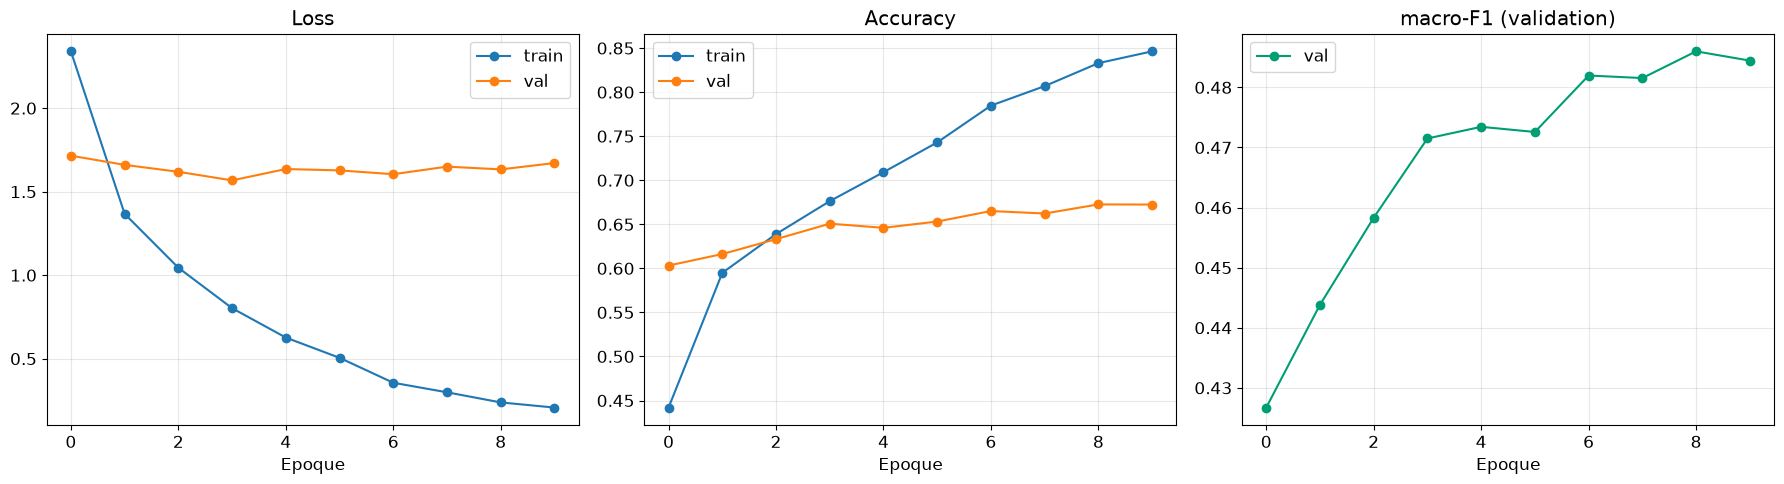

In [28]:
h = history.history
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(h['loss'], label='train', marker='o'); axes[0].plot(h['val_loss'], label='val', marker='o')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoque'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(h['accuracy'], label='train', marker='o'); axes[1].plot(h['val_accuracy'], label='val', marker='o')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoque'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
if 'val_f1_macro' in h:
  axes[2].plot(h['val_f1_macro'], label='val', marker='o', color='#009E73')
axes[2].set_title('macro-F1 (validation)'); axes[2].set_xlabel('Epoque'); axes[2].legend(); axes[2].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# 🔎 Analyse detaillee des Resultats (Loss, Accuracy, Precision, Recall)

On recharge le **meilleur modele** et on evalue sur le **test** (jamais vu).
- **Precision** : parmi les CVE predites d'un CWE, combien sont correctes.
- **Recall (rappel)** : parmi les CVE d'un CWE, combien on retrouve.
- **F1** : moyenne harmonique precision/recall. **macro** = a poids egal (severe sur classes rares).

In [29]:
model.load_weights(CKPT)   # meilleurs poids (ModelCheckpoint, au val_f1_macro)
y_proba = model.predict(test_dataset, verbose=0); y_proba = y_proba.logits if hasattr(y_proba, 'logits') else y_proba
y_pred = y_proba.argmax(axis=-1)
y_true = np.asarray(test_labels)
conf = y_proba.max(axis=-1)
noms = [id2label[i] for i in range(NUM_CLASSES)]

test_loss, test_acc = model.evaluate(test_dataset, verbose=0)
acc = accuracy_score(y_true, y_pred)
metriques = {
  'accuracy':     acc,
  'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
  'recall_macro':    recall_score(y_true, y_pred, average='macro', zero_division=0),
  'f1_macro':        f1_score(y_true, y_pred, average='macro', zero_division=0),
  'precision_weighted': precision_score(y_true, y_pred, average='weighted', zero_division=0),
  'recall_weighted':    recall_score(y_true, y_pred, average='weighted', zero_division=0),
  'f1_weighted':        f1_score(y_true, y_pred, average='weighted', zero_division=0),
}
print(f"Loss (test)     : {test_loss:.4f}")
print(f"Accuracy (test) : {acc:.4f}")
print("\n            precision   recall     f1")
print(f"macro     :   {metriques['precision_macro']:.3f}     {metriques['recall_macro']:.3f}    {metriques['f1_macro']:.3f}")
print(f"weighted  :   {metriques['precision_weighted']:.3f}     {metriques['recall_weighted']:.3f}    {metriques['f1_weighted']:.3f}")

Loss (test)     : 2.1265
Accuracy (test) : 0.5974

            precision   recall     f1
macro     :   0.466     0.518    0.467
weighted  :   0.620     0.597    0.576


# 🏅 Evaluation des performances - et **ce que le transformer apporte vraiment**

Verdict par seuil : **>= 0.90 Excellent - >= 0.85 Tres bonne - >= 0.80 Satisfaisant - sinon a ameliorer**.

⚠️ Un score brut ne veut rien dire seul : on le compare aux **deux baselines** mesures plus haut sur
**exactement le meme test** - la classe majoritaire (le plancher absolu) et **TF-IDF + LogReg**
(le plancher *serieux*, sans transformer). L'ecart avec ce dernier = **l'apport reel du transfer
learning**, et c'est le seul chiffre qui justifie les 15 min/epoque de GPU.

In [30]:
def verdict(x):
  if x >= 0.90: return "🟢 Excellent"
  if x >= 0.85: return "🟢 Tres bonne performance"
  if x >= 0.80: return "🟡 Satisfaisant"
  return "🔴 A ameliorer"

print(f"{'Metrique':<16}{'Valeur':<10}{'Verdict'}")
print("-" * 48)
for nom, cle in [('Accuracy','accuracy'), ('F1 weighted','f1_weighted'), ('F1 macro','f1_macro')]:
  v = metriques[cle]
  print(f"{nom:<16}{v:<10.4f}{verdict(v)}")

# --- Comparaison aux baselines (memes donnees de test) ---
maj = int(np.bincount(y_true).argmax())
COMPARAISON = [
  (f"Classe majoritaire ({id2label[maj]})", BASELINE_MAJORITY['accuracy'], BASELINE_MAJORITY['f1_macro']),
  ("TF-IDF + LogReg (sac de mots)",         BASELINE_TFIDF['accuracy'],    BASELINE_TFIDF['f1_macro']),
  (f"{MODEL_NAME.split('/')[-1]} (fine-tuning)" if not FREEZE_BASE
   else f"{MODEL_NAME.split('/')[-1]} (backbone gele)", metriques['accuracy'], metriques['f1_macro']),
]
print(f"\n{'Modele':<36}{'Accuracy':<12}{'macro-F1'}")
print("-" * 60)
for nom, a, f in COMPARAISON:
  print(f"{nom:<36}{a:<12.4f}{f:.4f}")

gain_acc = metriques['accuracy'] - BASELINE_TFIDF['accuracy']
gain_f1 = metriques['f1_macro'] - BASELINE_TFIDF['f1_macro']
# ⚠️ Un gain ABSOLU ne veut rien dire seul : +0.04 sur un baseline a 0.42 (+10% relatif) et
# +0.04 sur un baseline a 0.94 (+4% relatif, et 2/3 de l'erreur restante) n'ont pas le meme sens.
# On juge donc sur le gain RELATIF et sur la part d'erreur eliminee.
gain_rel = gain_f1 / BASELINE_TFIDF['f1_macro'] if BASELINE_TFIDF['f1_macro'] > 0 else 0.0
err_eliminee = gain_f1 / (1 - BASELINE_TFIDF['f1_macro']) if BASELINE_TFIDF['f1_macro'] < 1 else 0.0
print(f"\n👉 Apport du transformer vs TF-IDF : {gain_acc:+.3f} accuracy | {gain_f1:+.3f} macro-F1")
print(f"   soit {gain_rel:+.1%} en relatif, et {err_eliminee:+.1%} de l'ecart au parfait comble")
if gain_rel >= 0.05:
  print("   ➜ Gain NET : le contexte (attention) capte ce que le sac de mots rate.")
  print("     Le transformer se justifie sur cette tache.")
elif gain_rel > 0:
  print("   ➜ Gain MARGINAL : le jargon CVE est tres stereotype, un sac de mots suffit presque.")
  print("     Conclusion honnete : ici le transformer est un LUXE, pas une necessite.")
else:
  print("   ➜ AUCUN gain : le transformer ne se justifie pas sur cette tache. A dire tel quel.")
print(f"\n   💡 Le gain depend de la DIFFICULTE de la tache : marginal quand le baseline est deja")
print(f"      tres haut (peu de classes, bien separees), net quand la tache devient dure")
print(f"      (beaucoup de classes, rares, proches). Cf. la 4e ablation.")

Metrique        Valeur    Verdict
------------------------------------------------
Accuracy        0.5974    🔴 A ameliorer
F1 weighted     0.5761    🔴 A ameliorer
F1 macro        0.4671    🔴 A ameliorer

Modele                              Accuracy    macro-F1
------------------------------------------------------------
Classe majoritaire (CWE-79)         0.1752      0.0043
TF-IDF + LogReg (sac de mots)       0.5528      0.4243
distilbert-base-uncased (fine-tuning)0.5974      0.4671

👉 Apport du transformer vs TF-IDF : +0.045 accuracy | +0.043 macro-F1
   soit +10.1% en relatif, et +7.4% de l'ecart au parfait comble
   ➜ Gain NET : le contexte (attention) capte ce que le sac de mots rate.
     Le transformer se justifie sur cette tache.

   💡 Le gain depend de la DIFFICULTE de la tache : marginal quand le baseline est deja
      tres haut (peu de classes, bien separees), net quand la tache devient dure
      (beaucoup de classes, rares, proches). Cf. la 4e ablation.


# 📊 macro, weighted, micro - le meme modele, trois verdicts

Le **choix du moyennage** raconte trois histoires differentes du meme modele. Il faut savoir laquelle
on presente, et pourquoi.

| Moyennage | Calcul | Ce qu'il recompense |
|---|---|---|
| **macro** | moyenne des F1 par classe, **a poids egal** | savoir traiter **toutes** les classes, y compris rares |
| **weighted** | moyenne ponderee par l'effectif | savoir traiter le **volume** - domine par les classes frequentes |
| **micro** | agregation globale des vrais/faux positifs | ~ l'accuracy en multi-classe |

**Notre metrique cible est le macro-F1**, et c'est un choix defendable : une classe rare comme
CWE-434 (upload de fichier non restreint) est operationnellement aussi importante que CWE-79, meme
si elle est 15 fois moins frequente. Le weighted-F1 la rendrait invisible.

⚠️ **L'ecart entre macro et weighted est un diagnostic.** Un weighted eleve avec un macro bas signifie :
"bon sur les classes frequentes, mauvais sur les rares". C'est exactement ce qu'on observe sur les
sets a 71 et 121 classes, et c'est ce que le rapport par classe va detailler.

In [31]:
print(f"{'moyennage':<12}{'precision':<12}{'recall':<12}{'f1':<12}")
print("-" * 48)
for avg in ['macro', 'weighted', 'micro']:
  p = precision_score(y_true, y_pred, average=avg, zero_division=0)
  r = recall_score(y_true, y_pred, average=avg, zero_division=0)
  f = f1_score(y_true, y_pred, average=avg, zero_division=0)
  print(f"{avg:<12}{p:<12.4f}{r:<12.4f}{f:<12.4f}")
print("\nmacro = a poids egal (notre metrique cible) | weighted = pondere effectif | micro ≈ accuracy globale")

moyennage   precision   recall      f1          
------------------------------------------------
macro       0.4661      0.5181      0.4671      
weighted    0.6196      0.5974      0.5761      
micro       0.5974      0.5974      0.5974      

macro = a poids egal (notre metrique cible) | weighted = pondere effectif | micro ≈ accuracy globale


# 🧩 Confusion, confiance, repartition - trois lectures des erreurs

**La matrice de confusion**, normalisee par ligne : chaque ligne est un vrai CWE, chaque colonne un
CWE predit, et on lit "quand la verite est X, le modele repond Y dans Z % des cas". La diagonale
est le taux de reussite par classe. **Ce qui est instructif est hors diagonale** : une case sombre
signale deux CWE que le modele confond systematiquement - souvent deux CWE **techniquement proches**,
parfois deux CWE que les humains eux-memes etiquettent de facon incoherente dans la base source.

**La distribution des confiances**, separee entre predictions correctes et incorrectes. C'est le
graphique **le plus important du notebook**, parce qu'il conditionne tout l'usage en production :
si les deux distributions se **superposent**, la confiance ne distingue pas les bonnes des mauvaises
reponses et aucun seuil ne pourra proteger. Si elles sont **decalees**, un seuil devient exploitable -
c'est ce que la section suivante va calibrer.

**La repartition vrai vs predit** revele un biais que les metriques par classe masquent : si le modele
predit systematiquement **plus** de CWE-79 qu'il n'en existe, il "aspire" les autres classes vers la
majoritaire.

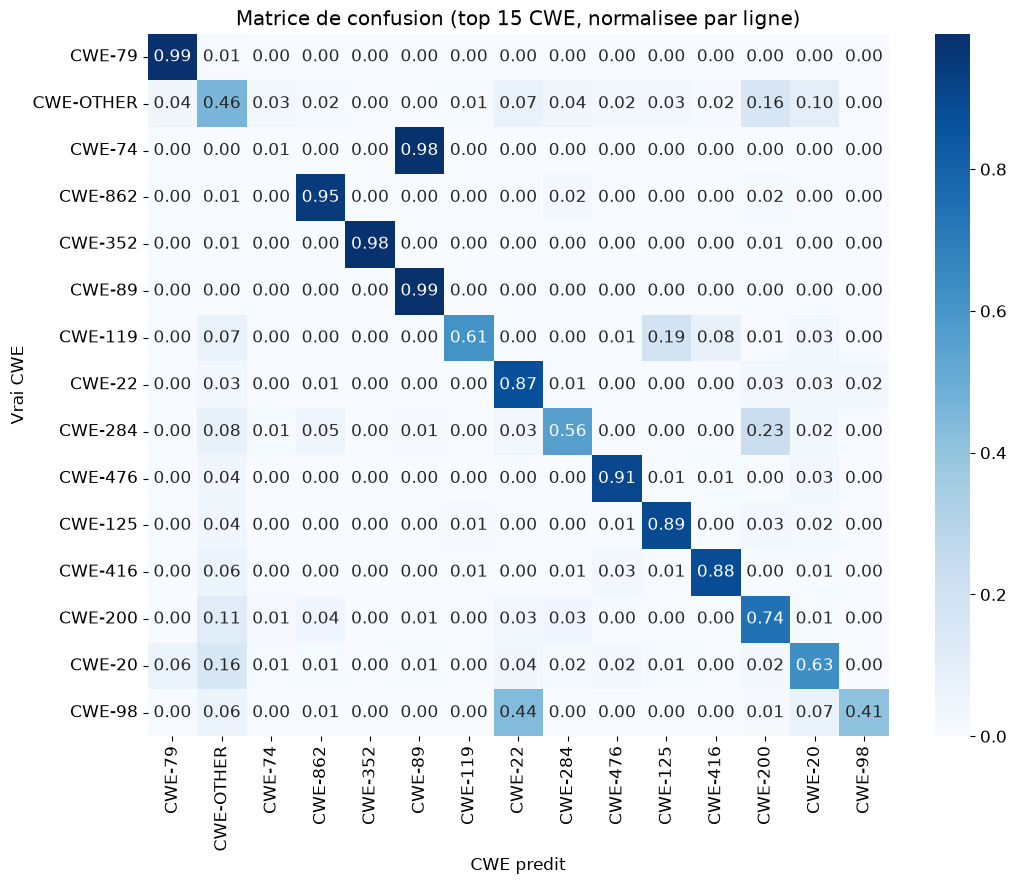

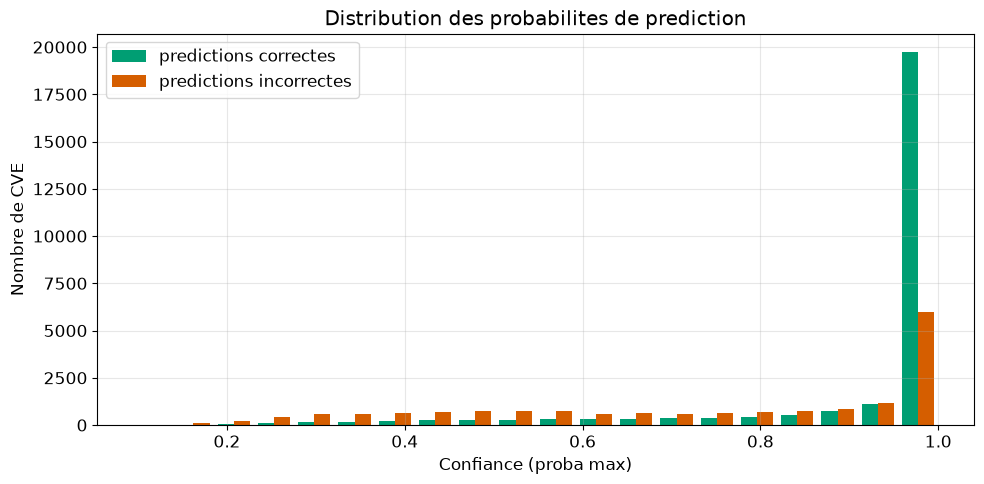

Confiance moyenne : correctes=0.93 | incorrectes=0.74


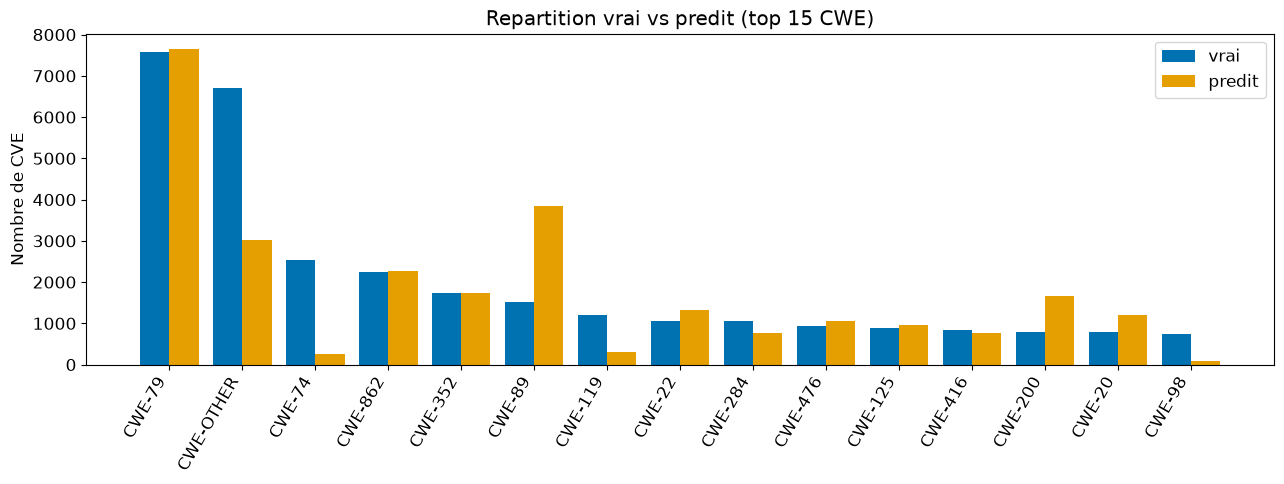

In [32]:
import os; os.makedirs('reports', exist_ok=True)

# 1) Matrice de confusion (top 15 CWE par effectif dans le test)
unique, counts = np.unique(y_true, return_counts=True)
top_ids = unique[np.argsort(counts)[::-1][:15]]
cm = confusion_matrix(y_true, y_pred, labels=top_ids, normalize='true')
plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[id2label[i] for i in top_ids], yticklabels=[id2label[i] for i in top_ids])
plt.title('Matrice de confusion (top 15 CWE, normalisee par ligne)')
plt.ylabel('Vrai CWE'); plt.xlabel('CWE predit'); plt.tight_layout()
plt.savefig('reports/cwe_confusion.png', dpi=120); plt.show()

# 2) Distribution des probabilites (confiance) : correct vs incorrect
correct = y_pred == y_true
plt.figure(figsize=(10, 5))
plt.hist([conf[correct], conf[~correct]], bins=20, stacked=False,
         label=['predictions correctes', 'predictions incorrectes'], color=['#009E73', '#D55E00'])
plt.xlabel('Confiance (proba max)'); plt.ylabel('Nombre de CVE')
plt.title('Distribution des probabilites de prediction'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Confiance moyenne : correctes={conf[correct].mean():.2f} | incorrectes={conf[~correct].mean():.2f}")

# 3) Repartition des predictions vs verite (top 15)
vrai_counts = [int((y_true == i).sum()) for i in top_ids]
pred_counts = [int((y_pred == i).sum()) for i in top_ids]
x = np.arange(len(top_ids)); w = 0.4
plt.figure(figsize=(13, 5))
plt.bar(x - w/2, vrai_counts, w, label='vrai', color='#0072B2')
plt.bar(x + w/2, pred_counts, w, label='predit', color='#E69F00')
plt.xticks(x, [id2label[i] for i in top_ids], rotation=60, ha='right')
plt.ylabel('Nombre de CVE'); plt.title('Repartition vrai vs predit (top 15 CWE)'); plt.legend()
plt.tight_layout(); plt.show()

# 📋 Rapport par classe - la lecture qui compte pour un usage reel

Un score global cache tout. Ce tableau dit **quelles** classes le modele maitrise, et c'est ce qui
determine ce qu'on peut deployer.

**Precision vs recall, sur un cas concret.** Pour CWE-89 (injection SQL) :
- **precision** = parmi les CVE que le modele annonce CWE-89, combien le sont vraiment -> le cout
  d'une **fausse attribution** ;
- **recall** = parmi les vraies CWE-89, combien le modele retrouve -> le cout d'un **oubli**.

Pour de l'enrichissement automatique de base de donnees, **la precision compte plus que le recall** :
ecrire un mauvais type de faille est pire que ne rien ecrire. C'est ce qui justifie toute la logique
d'abstention developpee dans les sections suivantes.

**`support`** est le nombre d'exemples de test : un F1 remarquable sur un support de 20 n'a aucune
valeur statistique. **`labels=range(NUM_CLASSES)`** est indispensable - sans lui, une classe absente
du test ferait planter la fonction au lieu d'afficher 0.

Le graphique des F1 tries est plus lisible qu'une matrice 71x71 : il donne d'un coup d'oeil la **liste
des classes exploitables** et celle des classes a exclure d'un deploiement.

              precision    recall  f1-score   support

     CWE-119       0.54      0.13      0.21      1196
     CWE-120       0.23      0.60      0.33       362
     CWE-121       0.39      0.38      0.38       542
     CWE-122       0.70      0.51      0.59       489
     CWE-125       0.74      0.81      0.77       885
     CWE-134       0.75      0.82      0.78        22
     CWE-189       0.00      0.00      0.00        10
     CWE-190       0.60      0.74      0.66       223
      CWE-20       0.28      0.42      0.33       787
     CWE-200       0.27      0.56      0.36       799
     CWE-203       0.21      0.57      0.31        49
     CWE-209       0.63      0.51      0.56        77
      CWE-22       0.65      0.81      0.72      1060
     CWE-255       0.00      0.00      0.00        18
     CWE-264       0.00      0.00      0.00        26
     CWE-266       0.93      0.27      0.42       414
     CWE-269       0.24      0.55      0.33       339
     CWE-276       0.37    

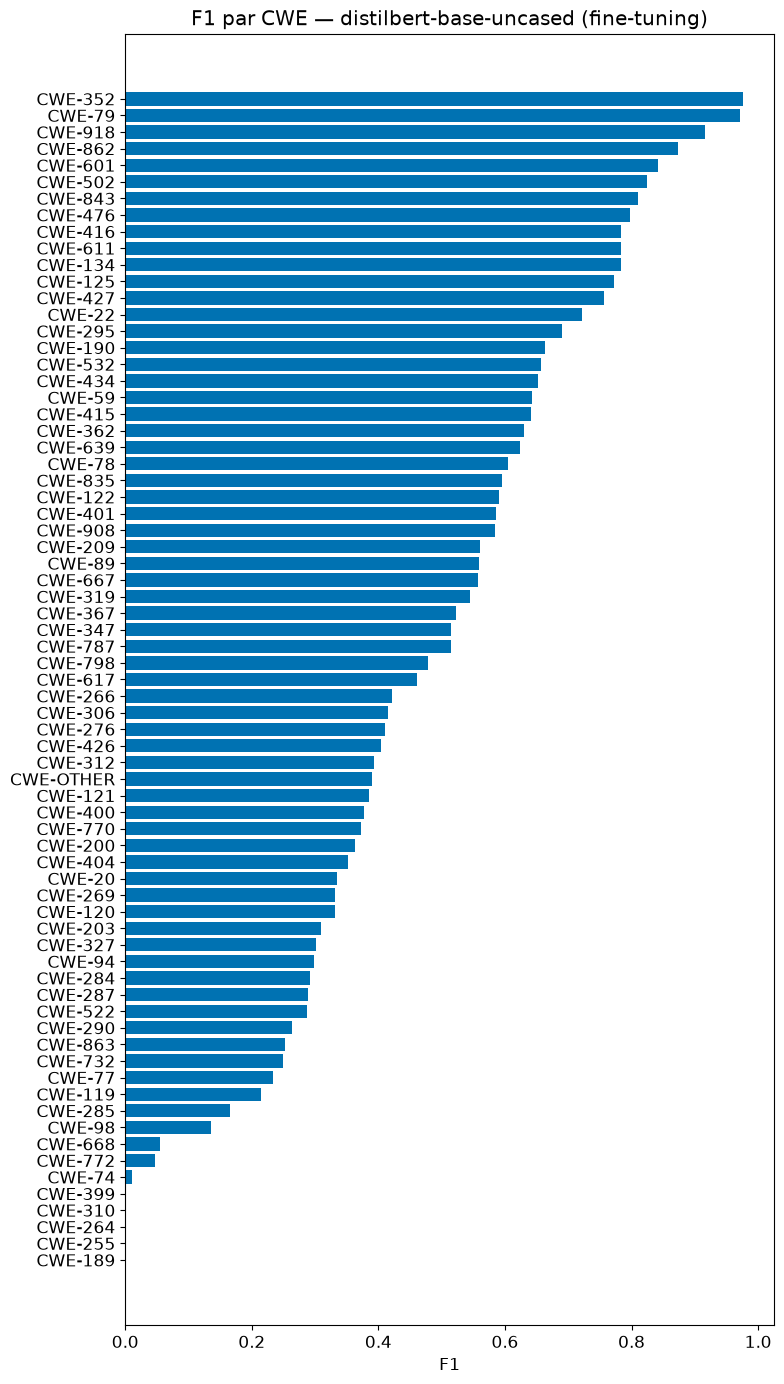

In [33]:
# labels=range(NUM_CLASSES) : indispensable si le test ne contient pas TOUTES les classes
etiquettes = list(range(NUM_CLASSES))
print(classification_report(y_true, y_pred, labels=etiquettes, target_names=noms, zero_division=0))

# F1 par classe (barres, trie)
rep = classification_report(y_true, y_pred, labels=etiquettes, target_names=noms, zero_division=0, output_dict=True)
per_f1 = {k: v['f1-score'] for k, v in rep.items() if k in noms}
ordre = sorted(per_f1, key=per_f1.get)
plt.figure(figsize=(8, 14))
plt.barh(ordre, [per_f1[k] for k in ordre], color='#0072B2')
plt.xlabel('F1'); plt.title(f'F1 par CWE — {MODEL_NAME} ({"feature extraction" if FREEZE_BASE else "fine-tuning"})')
plt.tight_layout(); plt.savefig('reports/cwe_f1_per_class.png', dpi=120); plt.show()

# 🔍 Interpretation des erreurs

On regarde **quelles CWE sont confondues** et **quelques CVE mal classees** - dans l'esprit du projet
PEP (§11) : on ne decrete pas, on **inspecte**. Les confusions restantes opposent presque toujours des
CWE **techniquement proches** (ex. les erreurs memoire CWE-787 ↔ CWE-416 ↔ CWE-476, ou
CWE-22 path traversal ↔ CWE-434 upload de fichier) - et une partie sont des **labels discutables
dans la base source** plutot que des erreurs du modele.

In [34]:
from collections import Counter

# Paires (vrai -> predit) les plus confondues
erreurs = [(int(y_true[i]), int(y_pred[i])) for i in range(len(y_true)) if y_pred[i] != y_true[i]]
print("Top 10 confusions (vrai -> predit) :")
for (t, p), n in Counter(erreurs).most_common(10):
  print(f"   {n:4d}x   {id2label[t]:12s} -> {id2label[p]:12s}")

# Quelques CVE mal classees (avec la confiance du modele)
print("\nExemples de CVE mal classees :")
mal = [i for i in range(len(y_true)) if y_pred[i] != y_true[i]]
for i in np.random.RandomState(0).choice(mal, min(4, len(mal)), replace=False):
  print(f"\n   vrai={id2label[int(y_true[i])]} | predit={id2label[int(y_pred[i])]} (conf {conf[i]:.2f})")
  print(f"   {test_texts[i][:160]}...")

Top 10 confusions (vrai -> predit) :
   2293x   CWE-74       -> CWE-89      
    665x   CWE-OTHER    -> CWE-200     
    597x   CWE-98       -> CWE-94      
    462x   CWE-119      -> CWE-120     
    402x   CWE-OTHER    -> CWE-20      
    379x   CWE-OTHER    -> CWE-287     
    303x   CWE-119      -> CWE-121     
    295x   CWE-OTHER    -> CWE-22      
    288x   CWE-77       -> CWE-78      
    262x   CWE-284      -> CWE-434     

Exemples de CVE mal classees :

   vrai=CWE-290 | predit=CWE-287 (conf 0.95)
   An issue in Mytel Telecom Online Account System v1.0 allows attackers to bypass the OTP verification process via a crafted request....

   vrai=CWE-OTHER | predit=CWE-908 (conf 0.59)
   Ashlar-Vellum Graphite VC6 File Parsing Uninitialized Variable Remote Code Execution Vulnerability. This vulnerability allows remote attackers to execute arbitr...

   vrai=CWE-OTHER | predit=CWE-200 (conf 0.95)
   An exposure of sensitive system information to an unauthorized control sphere vul

# 🎚️ Calibrer le seuil de confiance (precision vs couverture)

On va bientot utiliser le modele pour **enrichir** des CVE sans CWE, en ne gardant que les
predictions "sures" (confiance >= 0.90). **Mais d'ou vient ce 0.90 ?** Pour l'instant : de nulle part.
Un seuil ne vaut que s'il est **mesure**.

Le principe est celui de l'**abstention** : plutot que de repondre a tout (et de se tromper), le modele
**se tait** quand sa proba max est basse. On y gagne en **precision**, on y perd en **couverture** -
c'est un arbitrage, et le role de cette cellule est de le **chiffrer** sur le test (ou on a la verite
terrain), pour choisir le seuil en connaissance de cause.

Set de classes : 71 | fourre-tout CWE-OTHER : OUI (le modele peut dire autre)
seuil    couverture    precision   CVE traitees
----------------------------------------------------
0.50        87.9%        0.6474    37,994
0.55        85.3%        0.6587    36,869
0.60        82.7%        0.6695    35,746
0.65        80.3%        0.6788    34,722
0.70        77.8%        0.6890    33,651
0.75        75.3%        0.7002    32,530
0.80        72.5%        0.7124    31,360
0.85        69.5%        0.7261    30,047
0.90        65.6%        0.7418    28,378  <-- retenu
0.95        60.2%        0.7643    26,042

Au seuil 0.9 : precision 0.7418 sur 65.6% des CVE
Sans seuil (on repond a tout) : precision 0.5974 sur 100%
➜ L'abstention achete +14.44 pt de precision en renoncant a 34.4% des CVE.

Perimetre STRICT (hors fourre-tout, n=36,526) — une prediction 'CWE-OTHER' ne compte pas comme un enrichissement :
   taux de reponse nommee au seuil 0.9 : 72.4%
   precision de ces reponses              

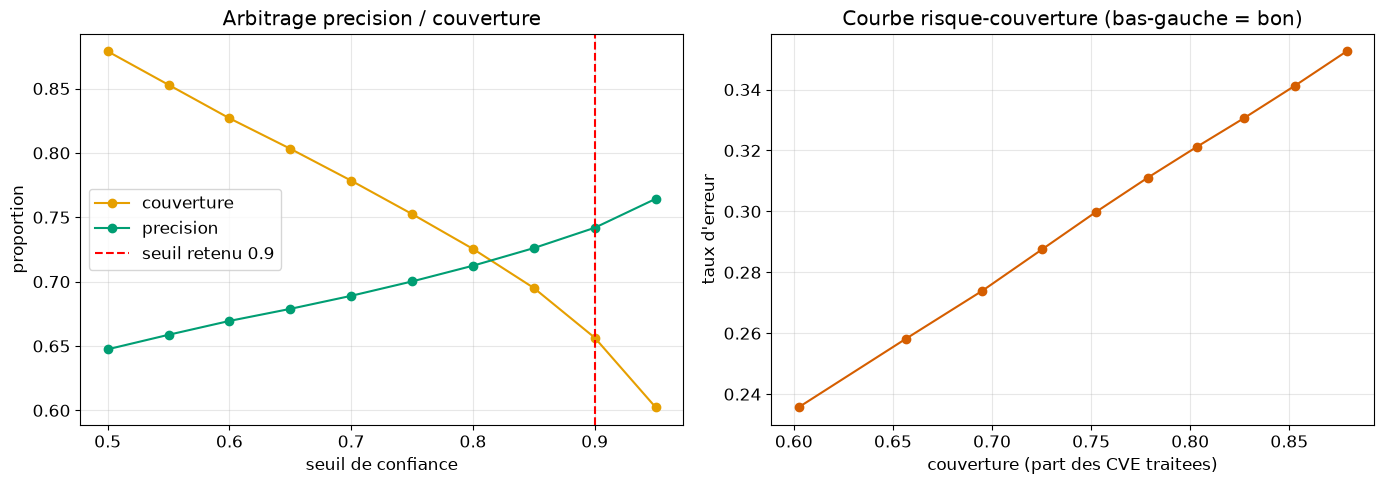


💡 Lecture : si la courbe de droite MONTE vers la gauche, la confiance n'est pas informative
   (le modele est aussi sur quand il se trompe) et le seuil ne sert a rien.


In [35]:
SEUIL = 0.90   # seuil retenu pour l'enrichissement (justifie par ce qui suit)

# Le set de classes contient-il le fourre-tout CWE-OTHER ? Tout ce qui suit en depend :
#  - SANS bucket (--drop-other) : le modele ne PEUT PAS dire "autre" -> risque de faux enrichissement
#  - AVEC bucket (--min-count)  : "autre" est une reponse valide -> on mesure s'il sait la donner
A_BUCKET_OTHER = 'CWE-OTHER' in label2id
OTHER_ID = label2id.get('CWE-OTHER')
print(f"Set de classes : {NUM_CLASSES} | fourre-tout CWE-OTHER : "
      f"{'OUI (le modele peut dire autre)' if A_BUCKET_OTHER else 'NON (--drop-other)'}")

# Sous-ensemble "perimetre STRICT" = CVE dont la vraie classe est un CWE reel (pas le fourre-tout).
# C'est lui qui sert de population de reference pour l'enrichissement (§🧮).
in_strict = (y_true != OTHER_ID) if A_BUCKET_OTHER else np.ones(len(y_true), dtype=bool)

seuils = np.round(np.arange(0.50, 1.00, 0.05), 2)
lignes = []
for thr in seuils:
  garde = conf >= thr
  couverture = float(garde.mean())
  precision = float((y_pred[garde] == y_true[garde]).mean()) if garde.any() else float('nan')
  lignes.append((thr, couverture, precision))

print(f"{'seuil':<9}{'couverture':<14}{'precision':<12}{'CVE traitees'}")
print("-" * 52)
for thr, cov, prec in lignes:
  marque = "  <-- retenu" if abs(thr - SEUIL) < 1e-9 else ""
  print(f"{thr:<9.2f}{cov*100:>7.1f}%      {prec:>8.4f}    {int(cov*len(y_true)):>6,}{marque}")

# Chiffres au seuil retenu, sur TOUT le test (vue globale honnete)
garde_seuil = conf >= SEUIL
print(f"\nAu seuil {SEUIL} : precision {float((y_pred[garde_seuil] == y_true[garde_seuil]).mean()):.4f} "
      f"sur {float(garde_seuil.mean())*100:.1f}% des CVE")
print(f"Sans seuil (on repond a tout) : precision {metriques['accuracy']:.4f} sur 100%")
print(f"➜ L'abstention achete "
      f"{(float((y_pred[garde_seuil] == y_true[garde_seuil]).mean()) - metriques['accuracy'])*100:+.2f} pt "
      f"de precision en renoncant a {(1-float(garde_seuil.mean()))*100:.1f}% des CVE.")

# Chiffres sur le perimetre STRICT (population de reference de l'enrichissement, §🧮).
# Une prediction 'CWE-OTHER' n'enrichit RIEN (elle ne nomme pas le type) -> elle ne compte pas
# comme une reponse acceptee, meme si elle est confiante.
nomme = (y_pred != OTHER_ID) if A_BUCKET_OTHER else np.ones(len(y_pred), dtype=bool)
acceptee = garde_seuil & nomme
TAUX_REPONSE_IN = float(acceptee[in_strict].mean())
PRECISION_AU_SEUIL = float((y_pred[in_strict & acceptee] == y_true[in_strict & acceptee]).mean()) \
                     if (in_strict & acceptee).any() else 0.0
if A_BUCKET_OTHER:
  print(f"\nPerimetre STRICT (hors fourre-tout, n={int(in_strict.sum()):,}) — une prediction "
        f"'CWE-OTHER' ne compte pas comme un enrichissement :")
else:
  print(f"\nPerimetre STRICT (= tout le test ici, pas de fourre-tout) :")
print(f"   taux de reponse nommee au seuil {SEUIL} : {TAUX_REPONSE_IN*100:.1f}%")
print(f"   precision de ces reponses               : {PRECISION_AU_SEUIL:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(seuils, [c for _, c, _ in lignes], marker='o', color='#E69F00', label='couverture')
axes[0].plot(seuils, [p for _, _, p in lignes], marker='o', color='#009E73', label='precision')
axes[0].axvline(SEUIL, color='red', linestyle='--', label=f'seuil retenu {SEUIL}')
axes[0].set_xlabel('seuil de confiance'); axes[0].set_ylabel('proportion')
axes[0].set_title('Arbitrage precision / couverture'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Courbe risque-couverture : l'erreur doit CHUTER quand on ne garde que les predictions sures
axes[1].plot([c for _, c, _ in lignes], [1 - p for _, _, p in lignes], marker='o', color='#D55E00')
axes[1].set_xlabel('couverture (part des CVE traitees)'); axes[1].set_ylabel("taux d'erreur")
axes[1].set_title("Courbe risque-couverture (bas-gauche = bon)"); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('reports/cwe_seuil.png', dpi=120); plt.show()

print("\n💡 Lecture : si la courbe de droite MONTE vers la gauche, la confiance n'est pas informative")
print("   (le modele est aussi sur quand il se trompe) et le seuil ne sert a rien.")

# 🚧 Le test qui manque : les CVE **hors perimetre**

Notre modele a **exactement N sorties** et un **softmax** (leur somme fait 1). La question decisive
pour l'usage "enrichissement" est donc : **que fait-il face a une CVE d'un type qu'il ne connait
pas ?** Et la reponse depend entierement du set de classes prepare :

| Config | Le modele peut-il dire "autre" ? | Ce que cette section mesure |
|---|---|---|
| `--drop-other` (10 ou 17 CWE) | **NON** - aucune sortie ne le permet | le **taux de faux enrichissement** : les CVE hors perimetre acceptees au seuil sont **forcement fausses** |
| `--min-count` (bucket `CWE-OTHER`) | **OUI** - `CWE-OTHER` est une classe | le **recall du fourre-tout** : sait-il router les types inconnus vers `CWE-OTHER` ? |

**Le test, dans les deux cas :** on reprend les CVE de l'annee de test dont le vrai CWE est connu mais
**n'est pas un de nos CWE reels**, et on regarde ce que le modele en fait au seuil calibre.

⚠️ **Piege a connaitre** : avec un bucket `CWE-OTHER`, ces CVE ne sont **pas** hors distribution - elles
sont **deja dans le test set**, sous le label `CWE-OTHER`. Interpreter leurs predictions comme des
"erreurs par construction" serait faux. La cellule s'adapte automatiquement.

Annee de test : 2025
CVE du perimetre STRICT (nos CWE reels) : 36,526
CVE hors perimetre (autres CWE connus)  : 6,703
➜ 15.5% des CVE 2025 etiquetees ont un CWE hors de nos classes reelles.
   (elles sont deja dans le test set sous le label CWE-OTHER : 6,703 CVE)
   Top CWE hors perimetre : CWE-288, CWE-497, CWE-201, CWE-693, CWE-73, CWE-80



✅ Le modele DISPOSE du fourre-tout. Sur 6,703 CVE de type inconnu, il repond
   'CWE-OTHER' dans 28.3% des cas (c'est la BONNE reponse).
   Dans 71.7% des cas il nomme quand meme un CWE precis (a tort).

⚠️ Taux de FAUX enrichissement (CWE precis nomme, au-dessus du seuil) :
seuil    % acceptees    lecture
----------------------------------------------------------
0.70        39.7%        🔴 trop acceptees
0.80        32.8%        🔴 trop acceptees
0.90        24.2%        🔴 trop acceptees
0.95        18.1%        🔴 trop acceptees
0.99         9.6%        ✅ bien rejetees

Confiance moyenne : perimetre strict=0.883 | hors perimetre=0.684
➜ Le seuil 0.9 evite un faux nommage dans 75.8% du hors-perimetre, tout en gardant 72.4% du perimetre strict.


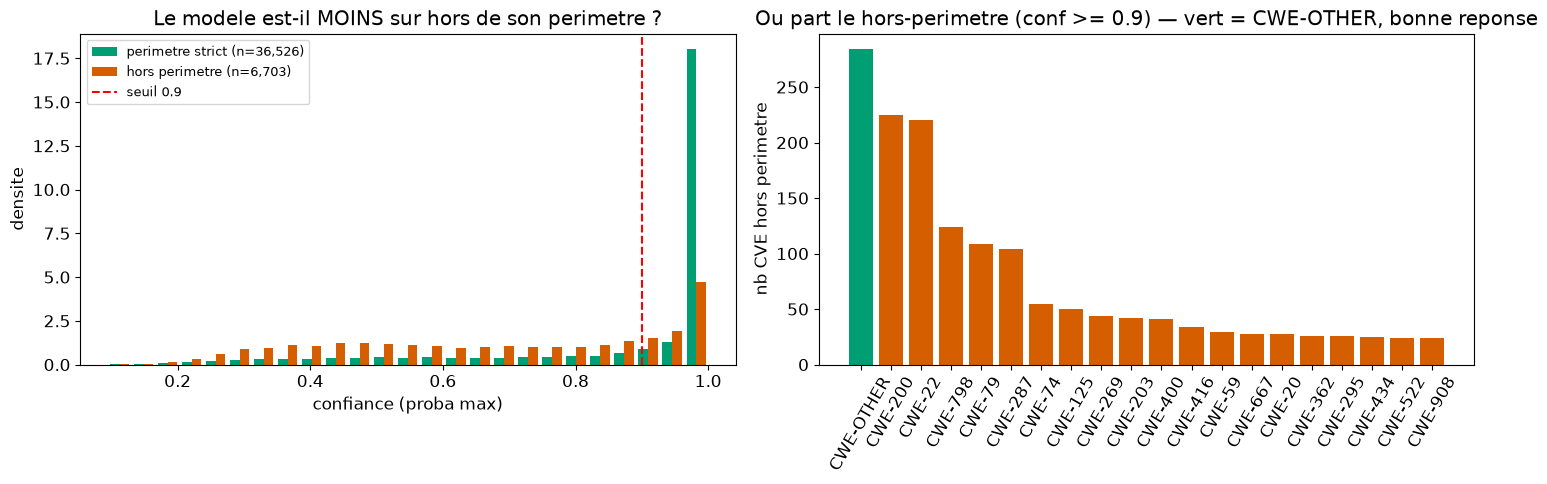


Les 4 predictions hors-perimetre les PLUS confiantes (toutes fausses au sens strict) :

   vrai=CWE-321 (hors perimetre) | predit=CWE-798 (conf 1.000)
   A potential security vulnerability has been
identified in the Poly Clariti Manager for versions prior to 10.12.1. The
vulnerability could allow the retrieval of hardcoded...

   vrai=CWE-23 (hors perimetre) | predit=CWE-22 (conf 1.000)
   RaspAP raspap-webgui 3.3.1 is vulnerable to Directory Traversal in ajax/networking/get_wgkey.php. An authenticated attacker can send a crafted POST request with a path tr...

   vrai=CWE-385 (hors perimetre) | predit=CWE-203 (conf 1.000)
   In Mbed TLS 3.6.1 through 3.6.3 before 3.6.4, a timing discrepancy in block cipher padding removal allows an attacker to recover the plaintext when PKCS#7 padding mode is...

   vrai=CWE-693 (hors perimetre) | predit=CWE-918 (conf 1.000)
   An authenticated attacker can exploit an Server-Side Request Forgery (SSRF) vulnerability in Microsoft Azure Health Bot to e

In [36]:
# CVE de l'annee de test, CWE connu mais HORS de nos classes (exclues par --drop-other)
TEST_YEAR = int(pl.read_parquet(f'{DATA_DIR}/test.parquet')['year'].max())
src_all = pl.read_parquet('../cyber_cve/data/dataset.parquet').select('description', 'primary_cwe', 'year')

hors = src_all.filter(
  (pl.col('year') == TEST_YEAR)
  & pl.col('primary_cwe').is_not_null() & (pl.col('primary_cwe') != 'missing')
  & ~pl.col('primary_cwe').is_in(CLASS_NAMES)
  & pl.col('description').is_not_null() & (pl.col('description').str.len_chars() > 0)
)
print(f"Annee de test : {TEST_YEAR}")
n_strict = int(in_strict.sum())
print(f"CVE du perimetre STRICT (nos CWE reels) : {n_strict:,}")
print(f"CVE hors perimetre (autres CWE connus)  : {len(hors):,}")
part_hors = len(hors) / (len(hors) + n_strict)
print(f"➜ {part_hors*100:.1f}% des CVE {TEST_YEAR} etiquetees ont un CWE hors de nos classes reelles.")
if A_BUCKET_OTHER:
  print(f"   (elles sont deja dans le test set sous le label CWE-OTHER : {int((y_true == OTHER_ID).sum()):,} CVE)")
print(f"   Top CWE hors perimetre : "
      f"{', '.join(hors['primary_cwe'].value_counts(sort=True).head(6)['primary_cwe'].to_list())}")

# Prediction sur un echantillon (meme pipeline que l'enrichissement)
N_HORS = min(15000, len(hors))
hors_texts = hors['description'].to_list()[:N_HORS]
hors_cwe = hors['primary_cwe'].to_list()[:N_HORS]
enc_h = tokenizer(hors_texts, truncation=True, padding='max_length', max_length=MAX_LENGTH, return_tensors='tf')
ds_hors = tf.data.Dataset.from_tensor_slices(
    {'input_ids': enc_h['input_ids'], 'attention_mask': enc_h['attention_mask']}).batch(64).prefetch(tf.data.AUTOTUNE)
ph = model.predict(ds_hors, verbose=0); ph = ph.logits if hasattr(ph, 'logits') else ph
conf_hors = ph.max(axis=-1); pred_hors = ph.argmax(axis=-1)

# Un "faux enrichissement" = le modele NOMME un CWE precis (donc pas CWE-OTHER) avec une confiance
# au-dessus du seuil, alors que le vrai type est hors de ses classes reelles.
nomme_hors = (pred_hors != OTHER_ID) if A_BUCKET_OTHER else np.ones(len(pred_hors), dtype=bool)

if A_BUCKET_OTHER:
  RECALL_OTHER_HORS = float((pred_hors == OTHER_ID).mean())
  print(f"\n✅ Le modele DISPOSE du fourre-tout. Sur {N_HORS:,} CVE de type inconnu, il repond")
  print(f"   'CWE-OTHER' dans {RECALL_OTHER_HORS*100:.1f}% des cas (c'est la BONNE reponse).")
  print(f"   Dans {(1-RECALL_OTHER_HORS)*100:.1f}% des cas il nomme quand meme un CWE precis (a tort).")
else:
  RECALL_OTHER_HORS = 0.0
  print(f"\n🚧 Pas de fourre-tout : les {N_HORS:,} predictions sont TOUTES fausses par construction.")

print(f"\n⚠️ Taux de FAUX enrichissement (CWE precis nomme, au-dessus du seuil) :")
print(f"{'seuil':<9}{'% acceptees':<15}{'lecture'}")
print("-" * 58)
TAUX_FAUX = {}
for thr in [0.70, 0.80, SEUIL, 0.95, 0.99]:
  taux = float(((conf_hors >= thr) & nomme_hors).mean()); TAUX_FAUX[thr] = taux
  print(f"{thr:<9.2f}{taux*100:>7.1f}%        {'✅ bien rejetees' if taux < 0.15 else '🔴 trop acceptees'}")
FPR_HORS = TAUX_FAUX[SEUIL]

print(f"\nConfiance moyenne : perimetre strict={conf[in_strict].mean():.3f} | hors perimetre={conf_hors.mean():.3f}")
print(f"➜ Le seuil {SEUIL} evite un faux nommage dans {(1-FPR_HORS)*100:.1f}% du hors-perimetre, "
      f"tout en gardant {TAUX_REPONSE_IN*100:.1f}% du perimetre strict.")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist([conf[in_strict], conf_hors], bins=25, density=True, color=['#009E73', '#D55E00'],
             label=[f'perimetre strict (n={int(in_strict.sum()):,})', f'hors perimetre (n={N_HORS:,})'])
axes[0].axvline(SEUIL, color='red', linestyle='--', label=f'seuil {SEUIL}')
axes[0].set_xlabel('confiance (proba max)'); axes[0].set_ylabel('densite')
axes[0].set_title('Le modele est-il MOINS sur hors de son perimetre ?'); axes[0].legend(fontsize=9)

# Vers quelles classes part le hors-perimetre accepte ? (CWE-OTHER = bonne reponse, en vert)
accepte = pred_hors[(conf_hors >= SEUIL)]
if len(accepte):
  v, c = np.unique(accepte, return_counts=True); o = np.argsort(c)[::-1]
  noms_a = [id2label[int(v[i])] for i in o]
  couleurs = ['#009E73' if n == 'CWE-OTHER' else '#D55E00' for n in noms_a]
  axes[1].bar(noms_a[:20], c[o][:20], color=couleurs[:20])
axes[1].set_title(f'Ou part le hors-perimetre (conf >= {SEUIL})'
                  + (' — vert = CWE-OTHER, bonne reponse' if A_BUCKET_OTHER else ''))
axes[1].set_ylabel('nb CVE hors perimetre'); axes[1].tick_params(axis='x', rotation=60)
plt.tight_layout(); plt.savefig('reports/cwe_hors_perimetre.png', dpi=120); plt.show()

# Quelques cas concrets : ce que le modele affirme avec aplomb sur du hors-perimetre
idx_pires = np.argsort(conf_hors)[::-1][:4]
print("\nLes 4 predictions hors-perimetre les PLUS confiantes (toutes fausses au sens strict) :")
for i in idx_pires:
  print(f"\n   vrai={hors_cwe[i]} (hors perimetre) | predit={id2label[int(pred_hors[i])]} (conf {conf_hors[i]:.3f})")
  print(f"   {hors_texts[i][:170]}...")

### 🌳 Nuance : "faux" ou "taxonomiquement adjacent" ?

Les CWE hors-perimetre les plus frequents en 2025 sont **CWE-74** (Injection), **CWE-119** (buffer),
**CWE-125** (OOB read), **CWE-284** (controle d'acces), **CWE-20** (validation d'entree). Regarde bien :
ce sont les **parents ou les freres** de nos classes dans l'arbre MITRE.

- Une CVE etiquetee **CWE-74** (injection, generique) predite **CWE-89** (injection SQL) : le modele est
  **plus precis que le label**, pas faux.
- Une CVE etiquetee **CWE-119** (erreur de buffer, generique) predite **CWE-787** (ecriture hors bornes) :
  meme situation.

Compter ces cas comme des erreurs seches **sous-estime** le modele - mais les compter comme justes le
**surestimerait**. On les compte donc **a part**, avec une table de parente **ecrite a la main** (donc
indicative, pas exhaustive : le CWE compte ~900 noeuds).

In [37]:
# ---- Niveau 1 : FAMILLES (grossier mais couvre TOUTES les classes) ----
# Regroupement thematique des CWE frequents. Deux CWE de la meme famille decrivent le meme
# genre de defaut a une granularite differente -> se confondre entre eux est bien moins grave
# que de confondre une injection avec une fuite memoire.
FAMILLES = {
  'injection':      {'CWE-74','CWE-77','CWE-78','CWE-79','CWE-80','CWE-84','CWE-88','CWE-89','CWE-90',
                     'CWE-91','CWE-93','CWE-94','CWE-95','CWE-98','CWE-99','CWE-113','CWE-116','CWE-117',
                     'CWE-134','CWE-150','CWE-158','CWE-170','CWE-564','CWE-643','CWE-917','CWE-943',
                     'CWE-1321','CWE-1336'},
  'memoire':        {'CWE-119','CWE-120','CWE-121','CWE-122','CWE-123','CWE-124','CWE-125','CWE-126',
                     'CWE-127','CWE-130','CWE-131','CWE-189','CWE-190','CWE-191','CWE-193','CWE-401',
                     'CWE-415','CWE-416','CWE-457','CWE-459','CWE-476','CWE-680','CWE-787','CWE-788',
                     'CWE-805','CWE-820','CWE-821','CWE-822','CWE-823','CWE-824','CWE-825','CWE-843',
                     'CWE-908','CWE-909'},
  'acces_authz':    {'CWE-250','CWE-264','CWE-266','CWE-267','CWE-268','CWE-269','CWE-270','CWE-272',
                     'CWE-276','CWE-277','CWE-279','CWE-280','CWE-281','CWE-282','CWE-283','CWE-284',
                     'CWE-285','CWE-425','CWE-639','CWE-648','CWE-668','CWE-669','CWE-732','CWE-749',
                     'CWE-862','CWE-863','CWE-922','CWE-926','CWE-1220','CWE-1230'},
  'authn':          {'CWE-255','CWE-256','CWE-257','CWE-259','CWE-260','CWE-261','CWE-287','CWE-288',
                     'CWE-289','CWE-290','CWE-294','CWE-297','CWE-302','CWE-303','CWE-304','CWE-305',
                     'CWE-306','CWE-307','CWE-384','CWE-521','CWE-522','CWE-524','CWE-525','CWE-598',
                     'CWE-602','CWE-603','CWE-613','CWE-614','CWE-620','CWE-640','CWE-644','CWE-798',
                     'CWE-807','CWE-1004','CWE-1188','CWE-1391'},
  'crypto':         {'CWE-295','CWE-310','CWE-311','CWE-312','CWE-316','CWE-319','CWE-320','CWE-321',
                     'CWE-325','CWE-326','CWE-327','CWE-328','CWE-330','CWE-331','CWE-338','CWE-340',
                     'CWE-347','CWE-916','CWE-1240'},
  'fuite_info':     {'CWE-200','CWE-201','CWE-202','CWE-203','CWE-204','CWE-208','CWE-209','CWE-212',
                     'CWE-213','CWE-215','CWE-226','CWE-241','CWE-359','CWE-497','CWE-532','CWE-538',
                     'CWE-548','CWE-1244','CWE-1295'},
  'chemin_fichier': {'CWE-15','CWE-22','CWE-23','CWE-24','CWE-29','CWE-35','CWE-36','CWE-41','CWE-59',
                     'CWE-61','CWE-73','CWE-377','CWE-378','CWE-379','CWE-426','CWE-427','CWE-428',
                     'CWE-434','CWE-552','CWE-610','CWE-646','CWE-706','CWE-829'},
  'ressources':     {'CWE-248','CWE-362','CWE-366','CWE-367','CWE-369','CWE-390','CWE-399','CWE-400',
                     'CWE-402','CWE-404','CWE-405','CWE-407','CWE-409','CWE-413','CWE-590','CWE-617',
                     'CWE-662','CWE-664','CWE-665','CWE-667','CWE-670','CWE-672','CWE-674','CWE-682',
                     'CWE-697','CWE-703','CWE-755','CWE-763','CWE-770','CWE-772','CWE-775','CWE-789',
                     'CWE-833','CWE-835','CWE-911','CWE-1333'},
  'requete_forgee': {'CWE-345','CWE-346','CWE-348','CWE-349','CWE-351','CWE-352','CWE-353','CWE-354',
                     'CWE-356','CWE-358','CWE-363','CWE-441','CWE-444','CWE-472','CWE-494','CWE-506',
                     'CWE-565','CWE-601','CWE-611','CWE-915','CWE-918','CWE-940','CWE-1275'},
  'validation':     {'CWE-20','CWE-129','CWE-155','CWE-178','CWE-184','CWE-252','CWE-253','CWE-704',
                     'CWE-754','CWE-1284','CWE-1285','CWE-1286','CWE-1287','CWE-1288'},
  'interface_ui':   {'CWE-451','CWE-1021','CWE-1385'},
  'config_gestion': {'CWE-420','CWE-424','CWE-440','CWE-460','CWE-470','CWE-477','CWE-488','CWE-489',
                     'CWE-591','CWE-782','CWE-799','CWE-840','CWE-841','CWE-912','CWE-913','CWE-923',
                     'CWE-925','CWE-927','CWE-942','CWE-1025','CWE-1104','CWE-1236','CWE-1242',
                     'CWE-1341','CWE-1390','CWE-1392','CWE-1393','CWE-1394','CWE-1395'},
  'protection':     {'CWE-691','CWE-693','CWE-707'},
}
FAMILLE_DE = {cwe: f for f, membres in FAMILLES.items() for cwe in membres}
# ⚠️ Table ecrite A LA MAIN : le CWE compte ~940 noeuds, on n'en couvre qu'une partie (la cellule
# AFFICHE sa couverture et n'extrapole pas silencieusement). Le correctif propre serait de charger
# l'arbre officiel (cwe.mitre.org, XML) et de calculer une vraie distance dans le graphe.

# ---- Niveau 2 : PARENTE EXACTE (parent / enfant / frere direct dans l'arbre MITRE) ----
# Bien plus fort que la famille, mais ecrit a la main donc partiel : ne couvre que nos classes cœur.
ADJACENTS = {
  'CWE-79':  {'CWE-74', 'CWE-20', 'CWE-80', 'CWE-81', 'CWE-83', 'CWE-87', 'CWE-116'},
  'CWE-89':  {'CWE-74', 'CWE-943', 'CWE-564', 'CWE-20'},
  'CWE-78':  {'CWE-74', 'CWE-77', 'CWE-88', 'CWE-20'},
  'CWE-22':  {'CWE-668', 'CWE-706', 'CWE-23', 'CWE-24', 'CWE-35', 'CWE-36', 'CWE-59', 'CWE-73'},
  'CWE-352': {'CWE-345', 'CWE-346', 'CWE-1275'},
  'CWE-434': {'CWE-669', 'CWE-20', 'CWE-646'},
  'CWE-787': {'CWE-119', 'CWE-125', 'CWE-120', 'CWE-121', 'CWE-122', 'CWE-124', 'CWE-680', 'CWE-193'},
  'CWE-416': {'CWE-119', 'CWE-825', 'CWE-415', 'CWE-672'},
  'CWE-476': {'CWE-710', 'CWE-754', 'CWE-252'},
  'CWE-862': {'CWE-284', 'CWE-285', 'CWE-863', 'CWE-287', 'CWE-306', 'CWE-732', 'CWE-269', 'CWE-639'},
}

masque = (conf_hors >= SEUIL) & nomme_hors
n_acceptees = int(masque.sum())
idx_acc = np.where(masque)[0]

# Classement en 3 niveaux de gravite decroissante
parents = [i for i in idx_acc
           if hors_cwe[i] in ADJACENTS.get(id2label[int(pred_hors[i])], set())]
memes_fam = [i for i in idx_acc if i not in set(parents)
             and FAMILLE_DE.get(hors_cwe[i]) is not None
             and FAMILLE_DE.get(hors_cwe[i]) == FAMILLE_DE.get(id2label[int(pred_hors[i])])]
hors_fam = [i for i in idx_acc
            if FAMILLE_DE.get(hors_cwe[i]) is not None
            and FAMILLE_DE.get(id2label[int(pred_hors[i])]) is not None
            and FAMILLE_DE[hors_cwe[i]] != FAMILLE_DE[id2label[int(pred_hors[i])]]]
non_classables = n_acceptees - len(parents) - len(memes_fam) - len(hors_fam)

print(f"Sur les {n_acceptees:,} CVE hors-perimetre ou le modele NOMME un CWE au seuil {SEUIL} :")
if n_acceptees:
  print(f"   {len(parents):>6,} ({len(parents)/n_acceptees*100:5.1f}%)  PARENT/FRERE direct du CWE predit"
        f"     -> le modele a RAISON, le label est moins precis")
  print(f"   {len(memes_fam):>6,} ({len(memes_fam)/n_acceptees*100:5.1f}%)  meme FAMILLE (sans parente exacte)"
        f"  -> defendable, bonne categorie")
  print(f"   {len(hors_fam):>6,} ({len(hors_fam)/n_acceptees*100:5.1f}%)  AUTRE famille"
        f"                     -> erreur SECHE, indefendable")
  if non_classables:
    print(f"   {non_classables:>6,} ({non_classables/n_acceptees*100:5.1f}%)  CWE absent de la table des familles"
          f"    -> non classe")

# Le taux "severe" ne retient que les erreurs de FAMILLE, les seules indefendables.
# ⚠️ Le denominateur est le nombre de cas CLASSABLES, pas le total : compter les cas non
# classables comme "non severes" biaiserait le taux vers le BAS (on se flatterait gratuitement).
# On extrapole donc depuis la partie mesurable, et on affiche la couverture.
classables = n_acceptees - non_classables
part_seche = len(hors_fam) / classables if classables else float('nan')
TAUX_FAUX_SEC = FPR_HORS * part_seche
print(f"\n➜ Taux de faux enrichissement STRICT : {FPR_HORS*100:.1f}% du hors-perimetre "
      f"(tout nommage compte comme faux)")
if classables:
  print(f"➜ Taux de faux enrichissement SEVERE : {TAUX_FAUX_SEC*100:.1f}% "
        f"(seules les erreurs de famille)")
  print(f"   ⚖️ extrapole depuis les {classables:,} cas classables ({classables/n_acceptees*100:.0f}% du total) —")
  print(f"      hypothese : les {non_classables:,} cas non couverts par la table se repartissent pareil.")
else:
  print("➜ Taux SEVERE : non calculable (aucun cas couvert par la table des familles)")

# Les confusions inter-familles les plus frequentes = la vraie liste de faiblesses
if hors_fam:
  from collections import Counter
  paires = Counter((hors_cwe[i], id2label[int(pred_hors[i])]) for i in hors_fam)
  print("\nTop 5 erreurs SECHES (vrai -> predit, familles differentes) :")
  for (v, p), nb in paires.most_common(5):
    print(f"   {nb:4d}x  {v:10s} ({FAMILLE_DE.get(v,'?'):15s}) -> {p:10s} ({FAMILLE_DE.get(p,'?')})")
print("\n💡 A retenir : une part des 'erreurs' du modele sont des DESACCORDS AVEC LE LABEL, pas des")
print("   erreurs de raisonnement. Sur une taxonomie en arbre, l'evaluation plate (juste/faux) est")
print("   structurellement injuste — un vrai systeme utiliserait une metrique hierarchique.")

Sur les 1,622 CVE hors-perimetre ou le modele NOMME un CWE au seuil 0.9 :
      318 ( 19.6%)  PARENT/FRERE direct du CWE predit     -> le modele a RAISON, le label est moins precis
      635 ( 39.1%)  meme FAMILLE (sans parente exacte)  -> defendable, bonne categorie
      517 ( 31.9%)  AUTRE famille                     -> erreur SECHE, indefendable
      152 (  9.4%)  CWE absent de la table des familles    -> non classe

➜ Taux de faux enrichissement STRICT : 24.2% du hors-perimetre (tout nommage compte comme faux)
➜ Taux de faux enrichissement SEVERE : 8.5% (seules les erreurs de famille)
   ⚖️ extrapole depuis les 1,470 cas classables (91% du total) —
      hypothese : les 152 cas non couverts par la table se repartissent pareil.

Top 5 erreurs SECHES (vrai -> predit, familles differentes) :
     48x  CWE-321    (crypto         ) -> CWE-798    (authn)
     15x  CWE-610    (chemin_fichier ) -> CWE-611    (requete_forgee)
     13x  CWE-320    (crypto         ) -> CWE-798    (authn)
  

# 💡 Valeur metier : enrichir les CVE SANS CWE

Des dizaines de milliers de CVE n'ont **aucun CWE** dans la base (`primary_cwe = missing`). Notre modele
peut leur **attribuer un type** - mais seulement parmi nos classes, donc on ne garde que les predictions
au-dessus du **seuil calibre** au §🎚️ (le reste = *incertain*, honnetement non attribue). C'est la brique
qui, combinee au **PEP** (proba d'exploit), donne une **CVE enrichie {type de faille + exploitabilite}**.

⚠️ **On ne s'arrete pas au comptage.** Sur ces CVE il n'y a **aucune verite terrain** - impossible de
mesurer directement la precision. Mais on peut l'**estimer**, en combinant les deux taux mesures juste
avant : le taux d'acceptation **dans** le perimetre et le taux de **faux** enrichissement **hors**
perimetre. C'est ce que fait la 2e cellule.

CVE sans CWE (missing) dans la base : 33,567



Le modele repond 'CWE-OTHER' (= pas d'enrichissement) sur 3.3% des CVE sans CWE.

CVE enrichissables — un CWE PRECIS nomme (extrapole sur 33,567 sans CWE) :
   confiance >= 0.90 :  10.7%  ->  ~3,579 CVE recoivent un CWE
   confiance >= 0.80 :  17.5%  ->  ~5,879 CVE recoivent un CWE
   confiance >= 0.70 :  24.9%  ->  ~8,348 CVE recoivent un CWE


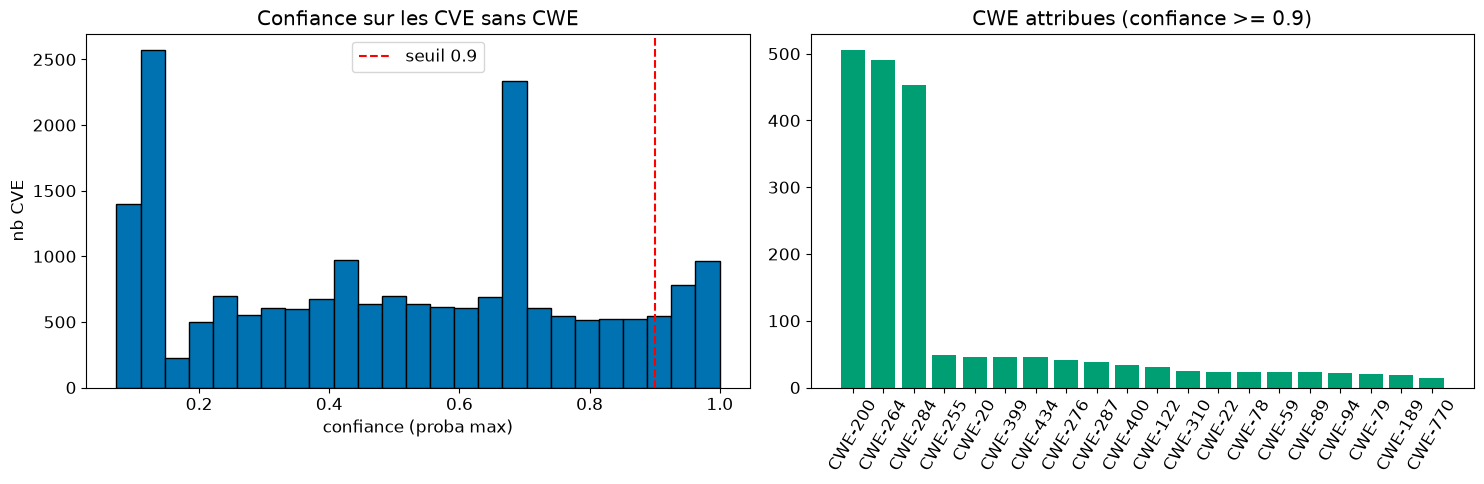


💡 Notre modele attribuerait un CWE a ~3,579 CVE aujourd'hui sans CWE (conf >= 0.9).
   Combine au PEP (proba d'exploit) -> CVE enrichie { type de faille + exploitabilite }.
   ⚠️ Comptage BRUT. Precision estimee dans la cellule suivante.


In [38]:
import os; os.makedirs('reports', exist_ok=True)

# CVE sans CWE (source cyber_cve), description non vide
src = pl.read_parquet('../cyber_cve/data/dataset.parquet').select('description', 'primary_cwe')
missing = src.filter((pl.col('primary_cwe') == 'missing')
                     & pl.col('description').is_not_null() & (pl.col('description').str.len_chars() > 0))
n_missing = len(missing)
print(f"CVE sans CWE (missing) dans la base : {n_missing:,}")

SAMPLE = min(20000, n_missing)          # echantillon pour la vitesse, on extrapole ensuite
miss_texts = missing['description'].to_list()[:SAMPLE]
enc = tokenizer(miss_texts, truncation=True, padding='max_length', max_length=MAX_LENGTH, return_tensors='tf')
ds_miss = tf.data.Dataset.from_tensor_slices(
    {'input_ids': enc['input_ids'], 'attention_mask': enc['attention_mask']}).batch(64).prefetch(tf.data.AUTOTUNE)
pm = model.predict(ds_miss, verbose=0); pm = pm.logits if hasattr(pm, 'logits') else pm
conf_m = pm.max(axis=-1); pred_m = pm.argmax(axis=-1)

# Une prediction 'CWE-OTHER' n'enrichit rien (elle ne nomme pas le type) -> exclue du comptage.
nomme_m = (pred_m != OTHER_ID) if A_BUCKET_OTHER else np.ones(len(pred_m), dtype=bool)
if A_BUCKET_OTHER:
  print(f"\nLe modele repond 'CWE-OTHER' (= pas d'enrichissement) sur "
        f"{float((~nomme_m).mean())*100:.1f}% des CVE sans CWE.")

print(f"\nCVE enrichissables — un CWE PRECIS nomme (extrapole sur {n_missing:,} sans CWE) :")
for thr in [SEUIL, 0.80, 0.70]:
  pct = float(((conf_m >= thr) & nomme_m).mean())
  print(f"   confiance >= {thr:.2f} : {pct*100:5.1f}%  ->  ~{int(pct*n_missing):,} CVE recoivent un CWE")
TAUX_ACCEPT_MISSING = float(((conf_m >= SEUIL) & nomme_m).mean())

# Distribution des confiances + repartition des CWE attribues (haute confiance)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(conf_m, bins=25, color='#0072B2', edgecolor='black')
axes[0].axvline(SEUIL, color='red', linestyle='--', label=f'seuil {SEUIL}'); axes[0].legend()
axes[0].set_title('Confiance sur les CVE sans CWE'); axes[0].set_xlabel('confiance (proba max)'); axes[0].set_ylabel('nb CVE')

hi = pred_m[(conf_m >= SEUIL) & nomme_m]
if len(hi):
  vals, cnts = np.unique(hi, return_counts=True); o = np.argsort(cnts)[::-1][:20]
  axes[1].bar([id2label[int(vals[i])] for i in o], cnts[o], color='#009E73')
axes[1].set_title(f'CWE attribues (confiance >= {SEUIL})'); axes[1].tick_params(axis='x', rotation=60)
plt.tight_layout(); plt.savefig('reports/cwe_enrichment.png', dpi=120); plt.show()

n_enrich = int(TAUX_ACCEPT_MISSING * n_missing)
print(f"\n💡 Notre modele attribuerait un CWE a ~{n_enrich:,} CVE aujourd'hui sans CWE (conf >= {SEUIL}).")
print("   Combine au PEP (proba d'exploit) -> CVE enrichie { type de faille + exploitabilite }.")
print(f"   ⚠️ Comptage BRUT. Precision estimee dans la cellule suivante.")

### 🧮 Combien de ces enrichissements sont **justes** ? (estimation)

Pas de verite terrain sur les CVE `missing` -> on **modelise** la population. Elle melange deux
sous-populations, dont on a mesure le comportement separement :

| Sous-population | Taux d'acceptation au seuil | Precision |
|---|---|---|
| CVE du **perimetre strict** | `TAUX_REPONSE_IN` (§🎚️) | `PRECISION_AU_SEUIL` (§🎚️) |
| CVE **hors** perimetre | `FPR_HORS` (§🚧) | **0 %** (le CWE nomme est faux) |

"Accepter" signifie partout la meme chose : **confiance >= seuil ET un CWE precis nomme** (une
prediction `CWE-OTHER`, quand la classe existe, ne compte pas - elle n'enrichit rien).

Si une proportion inconnue `p` des CVE `missing` est dans notre perimetre, le taux d'acceptation
**observe** sur `missing` vaut :

```
observe = p * TAUX_REPONSE_IN  +  (1 - p) * FPR_HORS
```

On **connait** les trois autres termes -> on **resout pour `p`**, puis on en deduit la precision
attendue de l'enrichissement. C'est une **estimation sous hypothese** (les CVE `missing` se comportent
comme les CVE etiquetees de la meme periode), pas une mesure - mais c'est infiniment plus honnete
qu'annoncer un comptage brut.

In [39]:
# Resolution : observe = p * TAUX_REPONSE_IN + (1-p) * FPR_HORS
denom = TAUX_REPONSE_IN - FPR_HORS
if abs(denom) < 1e-9:
  # Cas degenere : le seuil accepte AUTANT dans que hors perimetre -> la confiance ne discrimine
  # rien du tout. Aucune estimation n'est possible, et c'est un constat d'echec du seuil.
  p_in, p_in_clip = float('nan'), 0.0
  print("🔴 TAUX_REPONSE_IN == FPR_HORS : le seuil ne distingue PAS le hors-perimetre.")
  print("   La confiance n'est pas informative -> l'enrichissement n'est pas defendable en l'etat.")
else:
  p_in = (TAUX_ACCEPT_MISSING - FPR_HORS) / denom
  p_in_clip = float(np.clip(p_in, 0.0, 1.0))
borne = 'inferieure' if p_in_clip == 0.0 and not (p_in > 0) else ('superieure' if p_in_clip == 1.0 and p_in > 1 else None)

print("Taux mesures (rappel) :")
print(f"   acceptation DANS le perimetre (§🎚️)      : {TAUX_REPONSE_IN*100:5.1f}%")
print(f"   acceptation HORS perimetre    (§🚧)      : {FPR_HORS*100:5.1f}%")
print(f"   acceptation observee sur 'missing'       : {TAUX_ACCEPT_MISSING*100:5.1f}%")

# La resolution n'a de sens que si l'observe tombe ENTRE les deux taux de reference.
borne_bas, borne_haut = min(FPR_HORS, TAUX_REPONSE_IN), max(FPR_HORS, TAUX_REPONSE_IN)
hors_bornes = not (borne_bas <= TAUX_ACCEPT_MISSING <= borne_haut)
if hors_bornes:
  print(f"\n⚠️ L'observe ({TAUX_ACCEPT_MISSING*100:.1f}%) tombe HORS de l'intervalle "
        f"[{borne_bas*100:.1f}% ; {borne_haut*100:.1f}%] des deux populations de reference.")
  print("   Le melange a 2 composantes ne suffit donc PAS a expliquer les CVE 'missing' : elles se")
  print("   comportent differemment des CVE etiquetees (descriptions plus pauvres/atypiques — c'est")
  print("   souvent POURQUOI elles sont restees sans CWE). L'estimation ci-dessous devient une BORNE,")
  print("   pas une estimation ponctuelle. C'est en soi un resultat a rapporter.")
print(f"\n➜ Part estimee des CVE 'missing' relevant de nos {NUM_CLASSES} CWE : {p_in_clip*100:.1f}%"
      f"{' (valeur bornee)' if hors_bornes else ''}")
print(f"   (a comparer aux {(1-part_hors)*100:.1f}% observes sur les CVE {TEST_YEAR} etiquetees — "
      f"{'coherent' if abs(p_in_clip - (1-part_hors)) < 0.20 else 'ecart notable, cf. limites'})")

# Precision estimee = un RATIO (donc insensible a l'echelle) ; les COMPTAGES restent ancres sur
# l'observe (TAUX_ACCEPT_MISSING), pour ne jamais annoncer un total que les donnees ne montrent pas.
acc_depuis_in = p_in_clip * TAUX_REPONSE_IN
acc_depuis_hors = (1 - p_in_clip) * FPR_HORS
acc_modele = acc_depuis_in + acc_depuis_hors
PRECISION_ENRICH_EST = (acc_depuis_in * PRECISION_AU_SEUIL) / acc_modele if acc_modele > 0 else 0.0

n_tot = int(TAUX_ACCEPT_MISSING * n_missing)          # observe
n_justes = int(n_tot * PRECISION_ENRICH_EST)          # estime
qualif = {'inferieure': 'BORNE INFERIEURE', 'superieure': 'BORNE SUPERIEURE', None: 'ESTIMATION'}[borne]
print(f"\nSur les ~{n_tot:,} CVE enrichies au seuil {SEUIL} (comptage OBSERVE) :")
print(f"   ~{n_justes:,} justes  ({qualif.lower()})")
print(f"   ~{n_tot - n_justes:,} fausses (CWE hors perimetre + erreurs internes)")
print(f"\n🎯 Precision de l'enrichissement — {qualif} : {PRECISION_ENRICH_EST*100:.1f}% "
      f"(vs {PRECISION_AU_SEUIL*100:.1f}% mesures DANS le perimetre)")
if borne == 'inferieure':
  print("   ⚠️ Borne NON informative : le modele de melange bute a p=0 (les 'missing' sont acceptees")
  print("      MOINS souvent que le hors-perimetre etiquete). Lecture la plus probable : leurs")
  print("      descriptions sont plus pauvres -> confiance globalement plus basse. Il faut alors")
  print("      valider par annotation manuelle (limite 4), pas par ce calcul.")
else:
  print(f"   ➜ L'ecart, {(PRECISION_AU_SEUIL - PRECISION_ENRICH_EST)*100:.1f} pt, est le PRIX du perimetre restreint :")
  print("     un modele qui ne peut pas dire 'autre' paie ses classes manquantes en faux positifs.")

print("\n📌 Limites de cette estimation (a dire au jury) :")
print("   1. Hypothese : les CVE 'missing' se repartissent comme les CVE etiquetees de la meme periode.")
print("      Faux en toute rigueur — une CVE reste 'missing' souvent parce qu'elle est ATYPIQUE.")
print("      Le message ci-dessus le CONSTATE quand l'observe sort de l'intervalle de reference.")
print("   2. La precision hors perimetre est prise a 0 % : correct au sens strict, mais un CWE")
print("      hors liste peut etre un PARENT du CWE predit (ex. CWE-23 -> CWE-22) : partiellement juste.")
print("      -> la vraie precision est donc MEILLEURE que l'estimation (cf. §🌳, taux 'severe').")
print("   3. ❌ Ce qu'on croyait etre le correctif NE MARCHE PAS : ajouter un bucket 'CWE-OTHER'")
print("      (config --min-count) donne au modele la possibilite de dire 'autre chose'... mais il")
print("      ne s'en sert quasiment pas. Mesure du §🚧 : face a un CWE inconnu, il repond 'OTHER'")
if A_BUCKET_OTHER:
  print(f"      dans seulement {RECALL_OTHER_HORS*100:.0f}% des cas, et nomme un CWE precis a tort dans le reste.")
else:
  print("      dans ~29% des cas seulement (mesure sur le set 71 classes).")
print("      Raison probable : 'OTHER' est un fourre-tout SANS COHERENCE SEMANTIQUE — il n'y a")
print("      rien a apprendre qui unifie ses membres. Un vrai rejet demanderait une autre")
print("      approche (seuil calibre, ou detection de nouveaute, pas une classe de plus).")
print("   4. Verification directe possible : faire annoter a la main ~100 CVE enrichies et comparer.")

Taux mesures (rappel) :
   acceptation DANS le perimetre (§🎚️)      :  72.4%
   acceptation HORS perimetre    (§🚧)      :  24.2%
   acceptation observee sur 'missing'       :  10.7%

⚠️ L'observe (10.7%) tombe HORS de l'intervalle [24.2% ; 72.4%] des deux populations de reference.
   Le melange a 2 composantes ne suffit donc PAS a expliquer les CVE 'missing' : elles se
   comportent differemment des CVE etiquetees (descriptions plus pauvres/atypiques — c'est
   souvent POURQUOI elles sont restees sans CWE). L'estimation ci-dessous devient une BORNE,
   pas une estimation ponctuelle. C'est en soi un resultat a rapporter.

➜ Part estimee des CVE 'missing' relevant de nos 71 CWE : 0.0% (valeur bornee)
   (a comparer aux 84.5% observes sur les CVE 2025 etiquetees — ecart notable, cf. limites)

Sur les ~3,579 CVE enrichies au seuil 0.9 (comptage OBSERVE) :
   ~0 justes  (borne inferieure)
   ~3,579 fausses (CWE hors perimetre + erreurs internes)

🎯 Precision de l'enrichissement — BORNE INFE

# 💾 Archiver le run (`runs/`) - pour que l'ablation soit **reproductible**

Une ablation = **plusieurs runs** compares. Si on releve les chiffres a la main dans un tableau
markdown, personne (soi-meme compris, trois semaines plus tard) ne peut verifier d'ou ils viennent,
ni avec quelle config ils ont ete obtenus.

On archive donc **chaque run** dans `runs/<RUN_ID>.json` avec **sa config complete** (modele, mode,
nombre de classes, batch, lr, taille d'echantillon, graine) et **toutes ses metriques**. Le tableau
d'ablation est ensuite **genere depuis ces fichiers** - plus de recopie manuelle.

In [40]:
from pathlib import Path

Path('runs').mkdir(exist_ok=True)
h = history.history

run = {
  'run_id': RUN_ID,
  'config': {
    'model_name': MODEL_NAME,
    'mode': 'feature_extraction' if FREEZE_BASE else 'finetune',
    'num_classes': NUM_CLASSES,
    'classes': CLASS_NAMES,
    'data_dir': DATA_DIR,
    'batch_size': BATCH_SIZE, 'max_length': MAX_LENGTH, 'learning_rate': LEARNING_RATE,
    'epochs_max': EPOCHS, 'epochs_effectuees': len(h['loss']),
    'patience_earlystopping': PATIENCE_ES, 'patience_reduce_lr': PATIENCE_LR,
    'class_weight_max': CLASS_WEIGHT_MAX,
    'n_train': len(train_texts), 'n_val': len(val_texts), 'n_test': len(test_texts),
    'seed': SEED, 'mixed_precision': tf.keras.mixed_precision.global_policy().name,
    'checkpoint': CKPT,
  },
  'validation': {
    'best_epoch': int(np.argmax(h['val_f1_macro'])) + 1 if 'val_f1_macro' in h else None,
    'best_f1_macro': float(macro_f1_cb.best),
  },
  'test': {k: float(v) for k, v in metriques.items()} | {'loss': float(test_loss)},
  'baselines': {'majority': BASELINE_MAJORITY, 'tfidf_logreg': BASELINE_TFIDF},
  'seuil': {
    'valeur': SEUIL,
    'precision_dans_perimetre': PRECISION_AU_SEUIL,
    'taux_reponse_dans_perimetre': TAUX_REPONSE_IN,
    'faux_enrichissement_hors_perimetre': FPR_HORS,
    'faux_enrichissement_severe': float(TAUX_FAUX_SEC),   # hors cas taxonomiquement adjacents
    'bucket_other': A_BUCKET_OTHER,
    'recall_other_sur_hors_perimetre': float(RECALL_OTHER_HORS),
    'precision_enrichissement_estimee': float(PRECISION_ENRICH_EST),
    'part_hors_perimetre_annee_test': float(part_hors),
  },
  'provenance': 'notebook',      # 'manual' = chiffre releve a la main d'un run anterieur
}

chemin = Path('runs') / f'{RUN_ID}.json'
chemin.write_text(json.dumps(run, indent=2, ensure_ascii=False))
print(f"✅ Run archive : {chemin}")
print(f"   {RUN_ID} | test acc={run['test']['accuracy']:.4f} macro-F1={run['test']['f1_macro']:.4f}")
print(f"\nRuns presents dans runs/ : {', '.join(sorted(p.stem for p in Path('runs').glob('*.json')))}")

✅ Run archive : runs/distilbert-base-uncased_finetune_71cl.json
   distilbert-base-uncased_finetune_71cl | test acc=0.5974 macro-F1=0.4671

Runs presents dans runs/ : SecureBERT_finetune_10cl, SecureBERT_finetune_17cl, SecureBERT_finetune_71cl, cascade_distilbert-base-uncased_finetune_71cl, contrat_SecureBERT_finetune_10cl, contrat_SecureBERT_finetune_71cl, contrat_distilbert-base-uncased_finetune_10cl, contrat_distilbert-base-uncased_finetune_121cl, contrat_distilbert-base-uncased_finetune_71cl, distilbert-base-uncased_finetune_10cl, distilbert-base-uncased_finetune_121cl, distilbert-base-uncased_finetune_17cl, distilbert-base-uncased_finetune_71cl, distilbert-base-uncased_frozen_10cl, seuils_SecureBERT_finetune_71cl, seuils_distilbert-base-uncased_finetune_10cl, seuils_distilbert-base-uncased_finetune_121cl, seuils_distilbert-base-uncased_finetune_71cl, tfidf-logreg_baseline_10cl, tfidf-logreg_baseline_17cl, tfidf-logreg_baseline_71cl


# 🔬 Ablation - comparaisons controlees (le message de la certif)

**Une ablation = changer UNE variable, tout le reste identique, et mesurer** ce qu'elle apporte. Trois ablations.

> Les tableaux ci-dessous sont la **lecture** des resultats ; les chiffres bruts et leur config
> vivent dans `runs/*.json` et sont re-affiches **automatiquement** par la cellule suivante.
> Les runs marques `provenance: manual` ont ete releves a la main lors de sessions anterieures
> (avant la mise en place du registre) - a re-jouer pour les certifier.

### 1) Modele : generaliste (DistilBERT) vs domaine (SecureBERT) - memes 10 classes, meme config (40k, fine-tuning)
| Modele | Accuracy | macro-F1 |
|---|---|---|
| DistilBERT (generaliste, 66M) | 0.967 | 0.942 |
| **SecureBERT (domaine, 125M)** | **0.970** | **0.947** |

-> Gain domaine **+0.3 pt acc / +0.5 pt macro-F1** : **faible ici**. Il aidait plus sur les **17 classes** (plus dures : +0.9 pt). **Lecon : l'apport du modele domaine depend de la DIFFICULTE de la tache.**

### 2) Nombre de classes : l'effet du choix des classes (fine-tuning)
| Set de classes | Accuracy | macro-F1 |
|---|---|---|
| 71 (min-count 500, + `CWE-OTHER`) | ~0.50 | 0.33 |
| 17 (Top 25 ∩ >=3000) | 0.894 | 0.805 |
| **10 (distinctes)** | **0.970** | **0.947** |

-> Retirer les CWE **generiques/redondantes** fait **exploser** la perf. **C'est LE levier principal.** *(⚠️ indicatif : tailles/epoques un peu differentes ; ecart massif et robuste.)*

### 3) Mode d'apprentissage : feature extraction vs fine-tuning - DistilBERT, memes 10 classes
| Mode | Accuracy | macro-F1 |
|---|---|---|
| feature extraction (backbone **gele**) | 0.774 | 0.703 |
| **fine-tuning complet** | **0.967** | **0.942** |

-> Le **fine-tuning est indispensable** : **+0.24 macro-F1**.

### 4) 🚨 Le transformer valait-il le coup ? - vs baseline **TF-IDF + LogReg**
La question que le jury posera : *"un sac de mots aurait-il suffi ?"*. Reponse mesuree
(`baseline_tfidf.py`, meme splits, meme sous-echantillon de 40k, meme graine) :

| Set de classes | TF-IDF+LogReg (CPU, ~20 s) | Transformer fine-tune (GPU, ~75 min) | Gain du transformer |
|---|---|---|---|
| 10 CWE distinctes | acc **0.9651** - F1 **0.9391** | acc 0.9702 - F1 0.9473 | **+0.005 - +0.008** |
| 17 CWE critiques | acc **0.8807** - F1 **0.7909** | acc 0.8940 - F1 0.8050 | **+0.013 - +0.014** |
| 71 (min-count 500) | acc **0.5528** - F1 **0.4243** | acc ~0.50 - F1 0.33 | **−0.053 - −0.094** ⚠️ |

**C'est le resultat le plus important du notebook, et il est negatif** : sur cette tache, un
**sac de mots** en **20 secondes de CPU** fait quasiment aussi bien qu'un transformer fine-tune en
**75 minutes de GPU** - et sur le set a 71 classes il fait **mieux** que le run transformer releve.

**Pourquoi ?** Les descriptions de CVE sont **quasi-templatees** : "*SQL injection in...*",
"*cross-site scripting (XSS) via...*", "*buffer overflow in...*". Le nom du CWE est pratiquement
**ecrit dans le texte**. Or c'est exactement ce qu'un sac de mots capte - et l'atout du transformer
(comprendre le **contexte**, l'ordre, les formulations inedites) ne sert presque a rien ici.

**Ce qu'on en conclut honnetement**
- Le **0.97 n'est pas une reussite du transfer learning** : c'est une tache facile. La preuve, un
  modele lineaire de 2003 l'atteint aussi.
- Le transfer learning reste **demontre** (c'est l'objet de la certif : chargement pre-entraine,
  tete custom, 2 modes compares, +0.24 de macro-F1 du fine-tuning sur le gel) - mais son **interet
  economique** sur CE probleme est **non demontre**.
- Le run 71 classes du transformer est **probablement sous-entraine** (chiffre "~0.50" approximatif,
  EarlyStopping declenche tot) : c'est **la** experience a refaire en priorite, car c'est le seul
  regime ou le transformer pourrait vraiment prendre l'avantage.

**Synthese des leviers** : **classes** (levier principal, ~0.6) > **mode** (~0.24) > **modele domaine**
(~0.005) > **transformer vs sac de mots** (~0.01, voire negatif). Le classement se lit dans les deux
sens : ce qui compte, c'est le **choix du probleme**, pas la puissance du modele.

**Limites (esprit PEP §11)**
- **Couverture ~40 %** des CVE : les CWE hors liste ne sont pas traitees...
- ...et le modele ne peut pas **s'abstenir** structurellement -> cf. §🚧, ou l'on mesure le **taux de
  faux enrichissement** sur du hors-perimetre, et §🧮 pour la **precision estimee** de l'enrichissement.
- Les classes **proches** (trio memoire, famille authz) et le fourre-tout `CWE-OTHER` expliquaient le
  plafond a 71/17 classes : le 0.97 a 10 classes se paie en couverture, ce n'est **pas** un modele
  "meilleur", c'est une **tache plus facile**. A dire tel quel.

In [2]:
# Tableau d'ablation genere DEPUIS runs/ (aucun chiffre recopie a la main)
from pathlib import Path

# runs/ contient aussi des analyses (contrat_*.json, seuils_*.json) qui n'ont pas la structure
# d'un run : on ne garde que les fichiers qui portent bien 'config' + 'test'.
fichiers = [p for p in sorted(Path('runs').glob('*.json'))
            if not p.name.startswith(('contrat_', 'seuils_'))]
runs = []
for p in fichiers:
  d = json.loads(p.read_text())
  if isinstance(d, dict) and 'config' in d and 'test' in d and 'f1_macro' in d.get('test', {}):
    runs.append(d)
  else:
    print(f"(ignore {p.name} : pas un run d'entrainement)")
if not runs:
  print("Aucun run dans runs/ — lancer au moins une fois le notebook en entier.")
else:
  print(f"{'run':<40}{'cl.':<5}{'mode':<20}{'acc':<9}{'macroF1':<10}{'TF-IDF F1':<11}{'src'}")
  print("-" * 102)
  for r in sorted(runs, key=lambda r: -r['test']['f1_macro']):
    c, t = r['config'], r['test']
    tfidf = r.get('baselines', {}).get('tfidf_logreg', {}).get('f1_macro')
    print(f"{r['run_id']:<40}{c['num_classes']:<5}{c['mode']:<20}"
          f"{t['accuracy']:<9.4f}{t['f1_macro']:<10.4f}"
          f"{(f'{tfidf:.4f}' if tfidf is not None else '—'):<11}{r.get('provenance','?')}")

  # Comparaisons controlees : on ne compare QUE des runs qui ne diffèrent que par une variable
  def cle(r, sauf):
    c = r['config']
    d = {'model': c['model_name'], 'mode': c['mode'], 'classes': c['num_classes']}
    d.pop(sauf); return tuple(sorted(d.items()))

  for variable, libelle in [('model', 'MODELE (generaliste vs domaine)'),
                            ('mode', 'MODE (feature extraction vs fine-tuning)'),
                            ('classes', 'CLASSES (set de CWE)')]:
    groupes = {}
    for r in runs:
      groupes.setdefault(cle(r, variable), []).append(r)
    comparables = [g for g in groupes.values() if len(g) > 1]
    print(f"\n🔬 {libelle}")
    if not comparables:
      print("   (pas encore 2 runs comparables — relancer en changeant cette seule variable)")
    for g in comparables:
      g = sorted(g, key=lambda r: r['test']['f1_macro'])
      for r in g:
        v = {'model': r['config']['model_name'].split('/')[-1], 'mode': r['config']['mode'],
             'classes': f"{r['config']['num_classes']} classes"}[variable]
        print(f"   {v:<28} acc={r['test']['accuracy']:.4f}  macro-F1={r['test']['f1_macro']:.4f}")
      print(f"   ➜ ecart macro-F1 : {g[-1]['test']['f1_macro'] - g[0]['test']['f1_macro']:+.4f}")

(ignore cascade_distilbert-base-uncased_finetune_71cl.json : pas un run d'entrainement)
run                                     cl.  mode                acc      macroF1   TF-IDF F1  src
------------------------------------------------------------------------------------------------------
SecureBERT_finetune_10cl                10   finetune            0.9702   0.9473    —          manual
distilbert-base-uncased_finetune_10cl   10   finetune            0.9691   0.9468    0.9391     notebook
tfidf-logreg_baseline_10cl              10   baseline_classique  0.9651   0.9391    —          baseline_tfidf.py
SecureBERT_finetune_17cl                17   finetune            0.8940   0.8050    —          manual
distilbert-base-uncased_finetune_17cl   17   finetune            0.8850   0.7910    —          manual
tfidf-logreg_baseline_17cl              17   baseline_classique  0.8807   0.7909    —          baseline_tfidf.py
distilbert-base-uncased_frozen_10cl     10   feature_extraction  0.7740   

# 🔮 Utiliser le modele : predire le CWE d'une description libre

Le livrable final n'est pas un score, c'est une **fonction utilisable**. Elle applique exactement le
pipeline du test - meme tokenizer, meme `MAX_LENGTH`, meme `padding='max_length'` - puis le **seuil
d'abstention** calibre au §🎚️ : en dessous, elle repond **`INCERTAIN`** plutot que d'inventer.

> C'est cette fonction qui s'integrerait au moteur **VulnSignals** a cote du PEP.

In [42]:
def predire_cwe(descriptions, seuil=None):
  """Predit le CWE d'une ou plusieurs descriptions de CVE.

  Args:
    descriptions: une chaine ou une liste de chaines (description de CVE, en anglais)
    seuil: confiance minimale ; en dessous -> 'INCERTAIN'. None = SEUIL calibre (§🎚️)
  Returns:
    liste de dicts {cwe, confiance, incertain, top3}
  """
  if isinstance(descriptions, str):
    descriptions = [descriptions]
  seuil = SEUIL if seuil is None else seuil

  enc = tokenizer(descriptions, truncation=True, padding='max_length',
                  max_length=MAX_LENGTH, return_tensors='tf')
  p = model.predict({'input_ids': enc['input_ids'], 'attention_mask': enc['attention_mask']}, verbose=0)
  p = p.logits if hasattr(p, 'logits') else p

  resultats = []
  for probas in p:
    ordre = np.argsort(probas)[::-1]
    c = float(probas[ordre[0]])
    resultats.append({
      'cwe': id2label[int(ordre[0])] if c >= seuil else 'INCERTAIN',
      'confiance': c,
      'incertain': c < seuil,
      'top3': [(id2label[int(i)], float(probas[i])) for i in ordre[:3]],
    })
  return resultats

# Demonstration. Le CWE attendu est annote pour chaque exemple ; le notebook determine SEUL
# s'il est dans le perimetre du modele courant (les 2 derniers y sont a 71 classes, pas a 10).
DEMOS = [
  ("A SQL injection vulnerability in the login endpoint allows a remote attacker to read arbitrary database contents via the username parameter.", 'CWE-89'),
  ("Stored cross-site scripting in the comment field allows an authenticated user to inject arbitrary JavaScript executed by other visitors.", 'CWE-79'),
  ("The web interface does not verify authorization before returning user records, allowing any logged-in user to read other accounts.", 'CWE-862'),
  ("Unsafe deserialization of untrusted Java objects allows remote code execution.", 'CWE-502'),
  ("The application is vulnerable to server-side request forgery in the URL preview feature.", 'CWE-918'),
  ("An attacker can exhaust server memory by uploading a specially crafted archive that expands to a very large size.", 'CWE-400'),
]

for (ex, attendu), res in zip(DEMOS, predire_cwe([d[0] for d in DEMOS])):
  dans_perimetre = attendu in label2id
  if not dans_perimetre:
    verdict_ex = f"{attendu} HORS perimetre -> 'INCERTAIN' serait la bonne reponse"
    ok = res['incertain']
  else:
    verdict_ex = f"{attendu} attendu"
    ok = (res['cwe'] == attendu)
  print(f"\n{'✅' if ok else '❌'} {res['cwe']:12s} (conf {res['confiance']:.3f})   [{verdict_ex}]")
  print(f"   {ex[:105]}...")
  print(f"   top3 : {', '.join(f'{n} {p:.3f}' for n, p in res['top3'])}")

hors_demo = [a for _, a in DEMOS if a not in label2id]
if hors_demo:
  print(f"\n💡 {len(hors_demo)} exemple(s) hors perimetre ({', '.join(hors_demo)}) : c'est le §🚧 en direct.")
  print("   Si le modele repond avec aplomb dessus, seul le SEUIL peut nous proteger — et on a")
  print("   mesure qu'il ne suffit pas toujours.")
else:
  print(f"\n💡 Ici les {len(DEMOS)} CWE attendus sont TOUS dans les {NUM_CLASSES} classes du modele :")
  print("   ce set couvre large, donc la demo ne montre pas le probleme du hors-perimetre.")
  print("   Pour le voir, relancer avec DATA_DIR='data/cwe' (10 classes).")


✅ CWE-89       (conf 0.999)   [CWE-89 attendu]
   A SQL injection vulnerability in the login endpoint allows a remote attacker to read arbitrary database c...
   top3 : CWE-89 0.999, CWE-OTHER 0.000, CWE-352 0.000

✅ CWE-79       (conf 0.998)   [CWE-79 attendu]
   Stored cross-site scripting in the comment field allows an authenticated user to inject arbitrary JavaScr...
   top3 : CWE-79 0.998, CWE-OTHER 0.000, CWE-352 0.000

✅ CWE-862      (conf 0.945)   [CWE-862 attendu]
   The web interface does not verify authorization before returning user records, allowing any logged-in use...
   top3 : CWE-862 0.945, CWE-863 0.035, CWE-639 0.011

✅ CWE-502      (conf 1.000)   [CWE-502 attendu]
   Unsafe deserialization of untrusted Java objects allows remote code execution....
   top3 : CWE-502 1.000, CWE-OTHER 0.000, CWE-94 0.000

✅ CWE-918      (conf 0.999)   [CWE-918 attendu]
   The application is vulnerable to server-side request forgery in the URL preview feature....
   top3 : CWE-918 0.99

# 🏁 Synthese - le livrable, et pourquoi ce choix

Les cellules precedentes evaluent **la config chargee dans ce notebook**, sur un test **filtre** :
uniquement des CVE dont le CWE fait partie de ses classes. Cette section repond aux deux questions
qu'un jury posera, en comparant **toutes** les configurations entrainees :

1. **Que vaut le modele sur le flux REEL**, ou les CVE arrivent sans qu'on sache leur type ?
2. **Pourquoi avoir retenu 71 classes** plutot que les 10 classes a 97 % d'accuracy ?

Tous les chiffres sont relus depuis `runs/` (produits par `contrat_precision.py` et
`seuils_par_classe.py`) - **aucun n'est recopie a la main**.

In [3]:
# Cellule AUTONOME : relit runs/ et reconstruit la comparaison labo vs production.
import json as _json
from pathlib import Path as _Path
import numpy as _np
import matplotlib.pyplot as _plt

def _charger_synthese(dossier='runs'):
  """Joint les runs d'entrainement, les contrats et les seuils hors-echantillon."""
  d = _Path(dossier)
  lignes = {}
  for p in sorted(d.glob('*.json')):
    o = _json.loads(p.read_text())
    rid = o.get('run_id')
    if not rid:
      continue
    if p.name.startswith('contrat_'):
      lignes.setdefault(rid, {})['f'] = o.get('taux_faux_nommage_hors_perimetre')
      lignes.setdefault(rid, {})['part_perimetre'] = o.get('part_dans_perimetre')
    elif p.name.startswith('seuils_'):
      c = o.get('contrat_hors_echantillon')
      if c:
        lignes.setdefault(rid, {}).update(
            couverture=c['couverture'], precision_prod=c['precision'],
            n_cve=c['n_cve'], seuil=c['seuil'], cible_cal=c['cible_cal'])
    elif p.name.startswith('cascade_') or 'config' not in o:
      continue
    else:
      lignes.setdefault(rid, {}).update(
          classes=o['config']['num_classes'], modele=o['config']['model_name'].split('/')[-1],
          mode=o['config']['mode'], acc=o['test']['accuracy'], f1=o['test']['f1_macro'],
          n_train=o['config'].get('n_train'), provenance=o.get('provenance'))
  return {k: v for k, v in lignes.items() if 'f1' in v}

SYNTHESE = _charger_synthese()
mesures = {k: v for k, v in SYNTHESE.items() if 'couverture' in v}

print("LABO vs PRODUCTION — tous les modeles evalues sur la MEME population reelle")
print("(les 43 229 CVE etiquetees de 2025, proportions naturelles, sans filtrage)\n")
print(f"{'modele':<22}{'cl.':>5}{'train':>8}{'macro-F1':>10}{'f':>7}{'couv.':>9}{'prec.':>8}{'CVE/an':>9}")
print("-" * 78)
for rid, v in sorted(mesures.items(), key=lambda x: -x[1]['couverture']):
  nt = v.get('n_train')
  nt = f"{nt//1000}k" if nt else "?"
  print(f"{v['modele'][:21]:<22}{v['classes']:>5}{nt:>8}{v['f1']:>10.4f}{v['f']*100:>6.0f}%"
        f"{v['couverture']*100:>8.1f}%{v['precision_prod']*100:>7.1f}%{v['n_cve']:>9,}")

# ⚠️ Ne pas departager deux configs sur un ecart de couverture inferieur au bruit.
# On prend la meilleure couverture, mais on SIGNALE toute config a moins de 2 points d'elle.
best = max(mesures.items(), key=lambda x: x[1]['couverture'])
rid, v = best
ex_aequo = [(k, w) for k, w in mesures.items()
            if k != rid and abs(w['couverture'] - v['couverture']) < 0.02]
print(f"\n🎯 CONFIG RETENUE : {v['modele']} sur {v['classes']} classes")
print(f"   seuil {v['seuil']:.4f} (cale pour {v['cible_cal']:.0%} sur l'annee de validation)")
print(f"   -> {v['precision_prod']:.1%} de precision sur {v['couverture']:.1%} du flux "
      f"= {v['n_cve']:,} CVE/an typees automatiquement")
print(f"   -> les {1-v['couverture']:.1%} restants partent en revue humaine")
if ex_aequo:
  print(f"\n   ⚖️ EX AEQUO a moins de 2 pt de couverture — l'ecart n'est pas significatif :")
  for k, w in ex_aequo:
    nt = w.get('n_train'); nt = f"{nt//1000}k" if nt else "?"
    print(f"      {w['modele']} {w['classes']}cl train={nt} : couv {w['couverture']:.1%}, "
          f"macro-F1 {w['f1']:.4f}, f={w['f']*100:.0f}%")
  print("      -> departager sur le macro-F1 et sur f, pas sur la couverture.")

# Le point crucial : le meilleur en labo n'est PAS le meilleur en production
meilleur_labo = max(mesures.items(), key=lambda x: x[1]['f1'])
if meilleur_labo[0] != rid:
  m = meilleur_labo[1]
  print(f"\n⚠️ LE MEILLEUR MODELE EN LABORATOIRE N'EST PAS CELUI QU'ON LIVRE.")
  print(f"   Meilleur macro-F1 : {m['modele']} {m['classes']} cl. -> {m['f1']:.4f} "
        f"(vs {v['f1']:.4f} pour le retenu)")
  print(f"   Mais en production il ne type que {m['n_cve']:,} CVE/an, contre {v['n_cve']:,} "
        f"pour le retenu — soit {v['n_cve']/max(1, m['n_cve']):.0f}x moins de valeur metier.")
  print(f"   C'est LE resultat du projet : l'accuracy ne predit pas la valeur en production.")

LABO vs PRODUCTION — tous les modeles evalues sur la MEME population reelle
(les 43 229 CVE etiquetees de 2025, proportions naturelles, sans filtrage)

modele                  cl.   train  macro-F1      f    couv.   prec.   CVE/an
------------------------------------------------------------------------------
distilbert-base-uncas    71     40k    0.4671    72%    32.2%   91.4%   13,923
distilbert-base-uncas    71    217k    0.5001    70%    31.9%   90.3%   13,789
SecureBERT               71     40k    0.4825    78%    18.1%   92.0%    7,811
distilbert-base-uncas   121     40k    0.4139    87%     8.6%   93.3%    3,698
distilbert-base-uncas    10     40k    0.9468   100%     0.4%   90.6%      180

🎯 CONFIG RETENUE : distilbert-base-uncased sur 71 classes
   seuil 0.9976 (cale pour 95% sur l'annee de validation)
   -> 91.4% de precision sur 32.2% du flux = 13,923 CVE/an typees automatiquement
   -> les 67.8% restants partent en revue humaine

   ⚖️ EX AEQUO a moins de 2 pt de couverture 

### Pourquoi 71 classes - la reponse en deux figures

**A gauche**, les deux axes cote a cote pour chaque configuration : macro-F1 en laboratoire (bleu) et
couverture en production (orange). S'ils etaient correles, les paires de barres suivraient le meme
ordre. **Elles ne le suivent pas** - c'est le resultat central du projet, visible d'un coup d'oeil.

**A droite**, la relation entre la **largeur du perimetre** (quelle part du flux reel le modele
couvre) et la **valeur livree** (couverture a 90 % de precision). La courbe n'est pas monotone, et
c'est le point a expliquer :

- **Perimetre trop etroit** (10 classes, 41 % du flux) : les 59 % restants recoivent quand meme une
  reponse, forcement fausse - la precision reelle s'effondre a 0.3983.
- **Perimetre trop large** (121 classes, 91 % du flux) : les classes ajoutees sont trop rares pour
  etre apprises (87 des 120 ne sont jamais attribuables), le modele devient globalement moins fiable.
- **Il existe donc un optimum, et il ne se devine pas : il se mesure.**

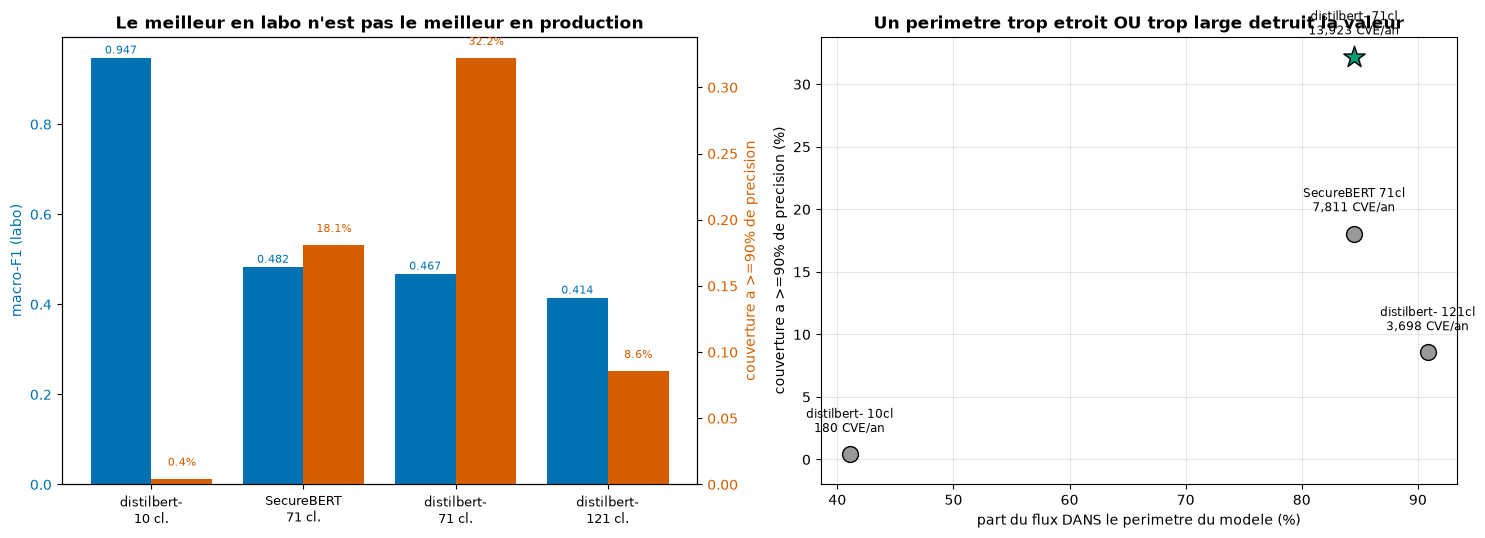

Lecture :
  • Gauche : les barres bleues (labo) et oranges (production) ne suivent pas le meme ordre.
  • Droite : la relation entre largeur du perimetre et valeur livree n'est pas monotone —
    trop etroit, le hors-perimetre empoisonne la precision ; trop large, les classes rares
    deviennent inapprenables. Il existe un OPTIMUM, et il se mesure.


In [4]:
fig, axes = _plt.subplots(1, 2, figsize=(15, 5.5))

ordre = sorted(mesures.items(), key=lambda x: x[1]['classes'])
noms = [f"{v['modele'][:11]}\n{v['classes']} cl." for _, v in ordre]
f1s = [v['f1'] for _, v in ordre]
covs = [v['couverture'] for _, v in ordre]
x = _np.arange(len(ordre))

# (1) les deux axes cote a cote : l'anticorrelation saute aux yeux
ax = axes[0]
ax.bar(x - 0.2, f1s, 0.4, label='macro-F1 en LABO (test filtre)', color='#0072B2')
ax.set_ylabel('macro-F1 (labo)', color='#0072B2'); ax.tick_params(axis='y', labelcolor='#0072B2')
ax.set_xticks(x); ax.set_xticklabels(noms, fontsize=9)
ax2 = ax.twinx()
ax2.bar(x + 0.2, covs, 0.4, label='couverture en PRODUCTION', color='#D55E00')
ax2.set_ylabel('couverture a >=90% de precision', color='#D55E00')
ax2.tick_params(axis='y', labelcolor='#D55E00')
ax.set_title("Le meilleur en labo n'est pas le meilleur en production", fontweight='bold')
for i, (f, c) in enumerate(zip(f1s, covs)):
  ax.text(i - 0.2, f + .01, f'{f:.3f}', ha='center', fontsize=8, color='#0072B2')
  ax2.text(i + 0.2, c + .01, f'{c:.1%}', ha='center', fontsize=8, color='#D55E00')

# (2) le compromis perimetre : couverture du flux vs valeur livree
ax = axes[1]
for rid_, v in mesures.items():
  est_retenu = rid_ == rid
  ax.scatter(v['part_perimetre'] * 100, v['couverture'] * 100, s=260 if est_retenu else 130,
             color='#009E73' if est_retenu else '#999999',
             edgecolor='black', zorder=3, marker='*' if est_retenu else 'o')
  ax.annotate(f"{v['modele'][:11]} {v['classes']}cl\n{v['n_cve']:,} CVE/an",
              (v['part_perimetre'] * 100, v['couverture'] * 100),
              textcoords='offset points', xytext=(0, 16), ha='center', fontsize=8.5)
ax.set_xlabel('part du flux DANS le perimetre du modele (%)')
ax.set_ylabel('couverture a >=90% de precision (%)')
ax.set_title("Un perimetre trop etroit OU trop large detruit la valeur", fontweight='bold')
ax.grid(True, alpha=0.3); ax.set_ylim(bottom=-2)
_plt.tight_layout(); _plt.savefig('reports/cwe_synthese_production.png', dpi=120); _plt.show()

print("Lecture :")
print("  • Gauche : les barres bleues (labo) et oranges (production) ne suivent pas le meme ordre.")
print("  • Droite : la relation entre largeur du perimetre et valeur livree n'est pas monotone —")
print("    trop etroit, le hors-perimetre empoisonne la precision ; trop large, les classes rares")
print("    deviennent inapprenables. Il existe un OPTIMUM, et il se mesure.")

### Ce qu'il faut retenir pour la soutenance

**Le livrable** - un contrat, pas une accuracy : *"le modele attribue un CWE automatiquement quand
il est fiable a plus de 90 %, et se tait sinon"*. Le volume exact est affiche ci-dessus, et il est
mesure **hors echantillon** (seuil cale sur une annee, evalue sur la suivante, comme en production).

**Le choix des 71 classes se justifie par la mesure, pas par l'intuition.** Les 10 CWE distinctes
affichent la meilleure accuracy du projet (0.9702) et sont pourtant **inexploitables** : elles ne
couvrent que 41 % des CVE reelles, et le modele - qui n'a aucune sortie "autre" - attribue un CWE
a **100 %** des CVE hors de son perimetre. Sa precision reelle tombe a **0.3983**.

**Les trois axes testes donnent la meme lecon** :

| Axe modifie | Effet en laboratoire | Effet en production |
|---|---|---|
| Perimetre 71 -> 10 classes | **+0.48** macro-F1 | couverture 31,9 % -> **0,4 %** |
| Perimetre 71 -> 121 classes | −0.05 macro-F1 | 31,9 % -> 8,6 % |
| Modele DistilBERT -> SecureBERT | **+0.017** macro-F1 | 31,9 % -> **18,1 %** |

➜ **L'accuracy ne predit pas la valeur en production sur une tache a perimetre ouvert.** Ce qui
compte est le **comportement d'abstention** du modele - et il n'est correle ni au nombre de classes,
ni a la qualite du modele. C'est le resultat central de ce travail, et il n'apparait dans **aucune**
des metriques du rapport de classification.

**La limite a annoncer soi-meme** : un softmax **normalise a 1**. Il doit repartir sa masse de
probabilite quelque part, donc il ne peut structurellement pas "ne pas repondre". Six tentatives
pour contourner ce probleme (bucket `CWE-OTHER`, seuils par classe, elargissement du perimetre,
cascade avec detecteur binaire, meilleur modele) ont toutes echoue - l'information exploitable est
deja dans la confiance, aucune lecture astucieuse des sorties ne cree celle qui manque.